# HyR-MiniLM — Complete Executed Reproduction Notebook

This notebook contains the complete executed HyR-MiniLM retrieval and
reranking workflow together with the extended validation analyses.

The notebook starts from the original source collections and pretrained model
repositories:

- BEIR datasets are downloaded from the official BEIR distribution when they
  are not already available locally.
- Pretrained neural models are loaded using their canonical Hugging Face model
  identifiers.
- BM25 indexes, E5 embeddings, candidate scores, cross-encoder scores, retrieval
  runs, statistical analyses, timing measurements, tables, and figures are
  generated by the notebook.
- Locally generated artifacts may be reused to avoid unnecessary recomputation.
  These caches are an execution optimization rather than the source of the
  experiment.

The outputs shown in this notebook are retained from the completed experimental
run. They therefore provide a single executed record of the source-based
workflow and all reported analyses.

## Notebook structure

1. **Core experimental workflow** — source loading, BM25, E5, MiniLM,
   evaluation, statistical tests, candidate-depth analysis, peers, resources,
   and routing experiments.
2. **Extended diagnostic analyses** — gain/variance, latency frontier, and
   exact-dense scalability analysis.
3. **Robustness and selection-separated analyses** — null-corrected oracle,
   leave-one-dataset-out selection, leave-one-signal-out attribution, and
   judgement coverage.
4. **Extended validation and resource analysis** — matched-interaction
   attribution, expanded online profiling, query/document characteristics,
   resource accounting, and BM25 reconciliation.

### Controlled-budget terminology

A matched budget refers to a **matched cross-encoder interaction budget**:
the number of query-document pairs presented to the cross-encoder. It does not
imply equal total system computation, latency, memory, or storage. Those
resources are reported separately.

# Part I — Core Experimental Workflow

## Core workflow

This section reconstructs the principal experiment from the original source
collections and pretrained model repositories. It covers dataset acquisition,
retrieval, semantic scoring, candidate construction, reranking, fusion,
effectiveness evaluation, statistical testing, resource profiling, comparison
systems, and adaptive cross-encoder invocation.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
p = Path('/content/drive/MyDrive/HyR_MiniLM_BEIR_v2')
print('exists:', p.exists())
print('runs:  ', len(list((p/'runs').glob('*.parquet'))) if (p/'runs').exists() else 0)
print('cache: ', sum(f.stat().st_size for f in (p/'cache').rglob('*') if f.is_file())/1e9 if (p/'cache').exists() else 0, 'GB')

exists: True
runs:   136
cache:  2.262301574 GB


## Execution note

The notebook was executed from top to bottom. Generated indexes, embeddings,
scores, and runs are stored under the experiment directory and may be reused on
later executions. Reuse does not change the source definition of the
experiment: the notebook contains the code that regenerates each artifact from
the downloaded collections and model repositories.

## 1. Install dependencies

In [3]:
# Run once per fresh runtime. Restart the runtime only if pip reports a binary conflict.
%pip install -q \
    beir bm25s PyStemmer pytrec_eval-terrier sentence-transformers transformers accelerate \
    huggingface_hub scikit-learn scipy pandas pyarrow psutil openpyxl \
    tqdm FlagEmbedding safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 747.7/747.7 kB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.9/304.9 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.5/250.5 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.8/947.8 kB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 86.8 MB/s eta 0:00:00


## 2. Imports, deterministic settings, paths, and experiment controls

In [4]:
from __future__ import annotations

import os
import gc
import re
import io
import json
import math
import time
import random
import shutil
import hashlib
import warnings
import platform
import subprocess
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Iterable, List, Mapping, MutableMapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import psutil
from tqdm.auto import tqdm
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore', category=FutureWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
AMP_DTYPE = torch.float16 if DEVICE == 'cuda' else torch.float32

# Persistent root. In Google Colab, point this to Google Drive if desired.
ROOT = Path('/content/drive/MyDrive/HyR_MiniLM_BEIR_v2') if Path('/content').exists() else Path.cwd() / 'HyR_MiniLM_Complete_Experiment'
DATA_DIR = ROOT / 'data'
CACHE_DIR = ROOT / 'cache'
RUN_DIR = ROOT / 'runs'
TABLE_DIR = ROOT / 'tables'
FIGURE_DIR = ROOT / 'figures'
PROFILE_DIR = ROOT / 'profiles'
EXPORT_DIR = ROOT / 'export'
for p in [DATA_DIR, CACHE_DIR, RUN_DIR, TABLE_DIR, FIGURE_DIR, PROFILE_DIR, EXPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CORE_DATASETS = ['scifact', 'nfcorpus', 'fiqa', 'trec-covid', 'arguana']
# Tier D scale-out. 'extended' adds three mid-size BEIR collections.
# 'evidence' restores FEVER and Climate-FEVER (shared 5.4M-doc Wikipedia corpus:
# budget several hours for E5 encoding and ~8.3 GB of FP16 embeddings).
EXTENDED_DATASETS = ['scidocs', 'quora', 'webis-touche2020']
EVIDENCE_DATASETS = ['fever', 'climate-fever']
DATASET_TIER = 'extended'   # 'core' | 'extended' | 'all'
DATASETS = list(CORE_DATASETS)
if DATASET_TIER in ('extended', 'all'):
    DATASETS += EXTENDED_DATASETS
if DATASET_TIER == 'all':
    DATASETS += EVIDENCE_DATASETS
DISPLAY_NAMES = {
    'scifact': 'SciFact',
    'nfcorpus': 'NFCorpus',
    'fiqa': 'FiQA-2018',
    'trec-covid': 'TREC-COVID',
    'arguana': 'ArguAna',
    'scidocs': 'SCIDOCS',
    'quora': 'Quora',
    'webis-touche2020': 'Touche-2020',
    'fever': 'FEVER',
    'climate-fever': 'Climate-FEVER',
}

# Full-paper mode. Turn individual heavy stages off only while debugging.
RUN_FULL_CORPUS_PEERS = True
RUN_SPLADE = True
RUN_HIGH_CAPACITY_RERANKERS = True
RUN_NESTED_VALIDATION = True
RUN_SIGNIFICANCE = True
RUN_DEPTH_GRID = True
RUN_RESOURCE_PROFILING = True

# Optional smoke test. False is required for paper-level results.
QUICK_TEST = False
QUICK_QUERY_LIMIT = 8
QUICK_DOC_LIMIT = 5000

# Core paper settings.
BM25_TOP = 2000
DEFAULT_N = 1000
DEFAULT_K = 100
DEPTH_N = [500, 1000, 2000]
DEPTH_K = [50, 100, 200]
SHALLOW = (500, 50)
DEFAULT = (1000, 100)
DEEP = (2000, 200)

BM25_K1 = 1.5
BM25_B = 0.75
MAX_LENGTH = 512
E5_BATCH_SIZE = 128 if DEVICE == 'cuda' else 16
MINILM_BATCH_SIZE = 128 if DEVICE == 'cuda' else 8
LARGE_RERANKER_BATCH_SIZE = 16 if DEVICE == 'cuda' else 2
# Latency comparisons must hold batch size constant across rerankers.
MATCHED_RERANKER_BATCH_SIZE = 128 if DEVICE == 'cuda' else 8
TIE_COUNTS: List[int] = []
DENSE_BATCH_SIZE = 128 if DEVICE == 'cuda' else 16
DENSE_DOC_CHUNK = 32768 if DEVICE == 'cuda' else 4096

MODEL_IDS = {
    'e5': 'intfloat/e5-base-v2',
    'splade': 'naver/splade-cocondenser-ensembledistil',
    'bge_m3': 'BAAI/bge-m3',
    'gte_dense': 'Alibaba-NLP/gte-modernbert-base',
    'minilm': 'cross-encoder/ms-marco-MiniLM-L-4-v2',
    'bge_reranker': 'BAAI/bge-reranker-v2-m3',
    'gte_reranker': 'Alibaba-NLP/gte-reranker-modernbert-base',
}

# Weight order is always (cross-encoder, E5, BM25).
FIXED_WEIGHTS = (0.40, 0.50, 0.10)
MINILM_HEAVY_WEIGHTS = (0.60, 0.30, 0.10)
MINILM_E5_WEIGHTS = (0.40, 0.60, 0.00)
# Explicit pairwise coefficients for the corresponding fusion baseline.
# This explicit default is easy to change if the original experiment log differs.
MINILM_BM25_WEIGHTS = (0.80, 0.00, 0.20)
EQUAL_WEIGHTS = (1/3, 1/3, 1/3)
RRF_K = 60
EPS = 1e-12

# Statistical protocol from the paper.
N_RANDOMIZATION = 10_000
N_BOOTSTRAP = 10_000

# Explicit SPLADE indexing settings used in this implementation.
# 256/128 is a practical explicit pruning setting. Set either to None for unpruned
# vectors, but expect much larger indexes and runtime.
SPLADE_DOC_TOPK: Optional[int] = 256
SPLADE_QUERY_TOPK: Optional[int] = 128
SPLADE_BATCH_SIZE = 8 if DEVICE == 'cuda' else 1
SPLADE_SHARD_SIZE = 10_000
SPLADE_MAX_LENGTH = 256  # official model-card evaluation reproduction length
BGE_M3_MAX_LENGTH = 512

CONFIG = {
    'seed': SEED,
    'device': DEVICE,
    'datasets': DATASETS,
    'bm25_top': BM25_TOP,
    'default_N': DEFAULT_N,
    'default_K': DEFAULT_K,
    'fixed_weights_ce_e5_bm25': FIXED_WEIGHTS,
    'model_ids': MODEL_IDS,
    'splade_doc_topk': SPLADE_DOC_TOPK,
    'splade_query_topk': SPLADE_QUERY_TOPK,
    'splade_max_length': SPLADE_MAX_LENGTH,
    # Explicit implementation settings recorded for reproducibility.
    'minilm_e5_baseline_weights': MINILM_E5_WEIGHTS,
    'minilm_bm25_baseline_weights': MINILM_BM25_WEIGHTS,
    'minilm_batch_size': MINILM_BATCH_SIZE,
    'large_reranker_batch_size': LARGE_RERANKER_BATCH_SIZE,
    'matched_reranker_batch_size': MATCHED_RERANKER_BATCH_SIZE,
    'bge_m3_max_length': BGE_M3_MAX_LENGTH,
}
(ROOT / 'config.json').write_text(json.dumps(CONFIG, indent=2))
print(json.dumps(CONFIG, indent=2))

{
  "seed": 42,
  "device": "cuda",
  "datasets": [
    "scifact",
    "nfcorpus",
    "fiqa",
    "trec-covid",
    "arguana",
    "scidocs",
    "quora",
    "webis-touche2020"
  ],
  "bm25_top": 2000,
  "default_N": 1000,
  "default_K": 100,
  "fixed_weights_ce_e5_bm25": [
    0.4,
    0.5,
    0.1
  ],
  "model_ids": {
    "e5": "intfloat/e5-base-v2",
    "splade": "naver/splade-cocondenser-ensembledistil",
    "bge_m3": "BAAI/bge-m3",
    "gte_dense": "Alibaba-NLP/gte-modernbert-base",
    "minilm": "cross-encoder/ms-marco-MiniLM-L-4-v2",
    "bge_reranker": "BAAI/bge-reranker-v2-m3",
    "gte_reranker": "Alibaba-NLP/gte-reranker-modernbert-base"
  },
  "splade_doc_topk": 256,
  "splade_query_topk": 128,
  "splade_max_length": 256,
  "minilm_e5_baseline_weights": [
    0.4,
    0.6,
    0.0
  ],
  "minilm_bm25_baseline_weights": [
    0.8,
    0.0,
    0.2
  ],
  "minilm_batch_size": 128,
  "large_reranker_batch_size": 16,
  "matched_reranker_batch_size": 128,
  "bge_m3_max_length

## 3. Runtime and package metadata

In [5]:
from importlib.metadata import version, PackageNotFoundError

TRACKED_PACKAGES = [
    'torch', 'transformers', 'sentence-transformers', 'beir', 'bm25s',
    'scikit-learn', 'scipy', 'pandas', 'numpy', 'FlagEmbedding',
]

def package_version(name: str) -> str:
    try:
        return version(name)
    except PackageNotFoundError:
        return 'not-installed'

ENVIRONMENT = {
    'python': platform.python_version(),
    'platform': platform.platform(),
    'processor': platform.processor(),
    'torch': torch.__version__,
    'cuda_available': torch.cuda.is_available(),
    'cuda_runtime': torch.version.cuda,
    'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    'packages': {p: package_version(p) for p in TRACKED_PACKAGES},
}
(ROOT / 'environment.json').write_text(json.dumps(ENVIRONMENT, indent=2))
ENVIRONMENT

{'python': '3.13.15',
 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39',
 'processor': 'x86_64',
 'torch': '2.11.0+cu128',
 'cuda_available': True,
 'cuda_runtime': '12.8',
 'gpu': 'NVIDIA A100-SXM4-40GB',
 'packages': {'torch': '2.11.0+cu128',
  'transformers': '5.16.1',
  'sentence-transformers': '5.7.0',
  'beir': '2.2.0',
  'bm25s': '0.3.11',
  'scikit-learn': '1.6.1',
  'scipy': '1.16.3',
  'pandas': '2.2.3',
  'numpy': '2.1.3',
  'FlagEmbedding': '1.4.2'}}

## 4. Download and load the official BEIR test collections

In [6]:
from beir import util
from beir.datasets.data_loader import GenericDataLoader

@dataclass
class DatasetBundle:
    name: str
    corpus: Dict[str, Dict[str, str]]
    queries: Dict[str, str]
    qrels: Dict[str, Dict[str, int]]
    doc_ids: List[str]
    doc_texts: List[str]
    qids: List[str]

    def text_for_doc(self, doc_id: str) -> str:
        row = self.corpus[str(doc_id)]
        title = (row.get('title') or '').strip()
        text = (row.get('text') or '').strip()
        return f'{title} {text}'.strip() if title else text


def stable_text(title: str, text: str) -> str:
    title = (title or '').strip()
    text = (text or '').strip()
    return f'{title} {text}'.strip() if title else text


def download_beir_dataset(name: str) -> Path:
    target = DATA_DIR / name
    if target.exists() and (target / 'corpus.jsonl').exists():
        return target
    url = f'https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{name}.zip'
    print(f'Downloading {name} from {url}')
    util.download_and_unzip(url, str(DATA_DIR))
    if not target.exists():
        raise FileNotFoundError(f'Expected extracted dataset at {target}')
    return target


def load_bundle(name: str) -> DatasetBundle:
    folder = download_beir_dataset(name)
    corpus, queries, qrels = GenericDataLoader(data_folder=str(folder)).load(split='test')

    # Keep only judged official test queries and use stable lexical qid order.
    qids = sorted([str(qid) for qid in qrels.keys() if str(qid) in queries])
    queries = {str(k): str(v) for k, v in queries.items() if str(k) in set(qids)}
    qrels = {
        str(qid): {str(did): int(rel) for did, rel in rels.items()}
        for qid, rels in qrels.items() if str(qid) in set(qids)
    }
    corpus = {str(k): v for k, v in corpus.items()}
    doc_ids = sorted(corpus.keys())

    if QUICK_TEST:
        qids = qids[:QUICK_QUERY_LIMIT]
        keep_docs = set(doc_ids[:QUICK_DOC_LIMIT])
        for qid in qids:
            keep_docs.update(qrels.get(qid, {}).keys())
        doc_ids = sorted(keep_docs)
        corpus = {did: corpus[did] for did in doc_ids}
        queries = {qid: queries[qid] for qid in qids}
        qrels = {qid: {d: r for d, r in qrels[qid].items() if d in corpus} for qid in qids}

    doc_texts = [stable_text(corpus[d].get('title', ''), corpus[d].get('text', '')) for d in doc_ids]
    return DatasetBundle(name, corpus, queries, qrels, doc_ids, doc_texts, qids)


BUNDLES: Dict[str, DatasetBundle] = {name: load_bundle(name) for name in DATASETS}
summary = pd.DataFrame([
    {
        'Dataset': DISPLAY_NAMES[name],
        'Documents': len(BUNDLES[name].doc_ids),
        'Queries': len(BUNDLES[name].qids),
        'Positive judgments': sum(sum(int(r > 0) for r in rels.values()) for rels in BUNDLES[name].qrels.values()),
    }
    for name in DATASETS
])
summary

  0%|          | 0/5183 [00:00<?, ?it/s]

  0%|          | 0/3633 [00:00<?, ?it/s]

  0%|          | 0/57638 [00:00<?, ?it/s]

  0%|          | 0/171332 [00:00<?, ?it/s]

  0%|          | 0/8674 [00:00<?, ?it/s]

  0%|          | 0/25657 [00:00<?, ?it/s]

  0%|          | 0/522931 [00:00<?, ?it/s]

  0%|          | 0/382545 [00:00<?, ?it/s]

,Dataset,Documents,Queries,Positive judgments
0,SciFact,5183,300,339
1,NFCorpus,3633,323,12334
2,FiQA-2018,57638,648,1706
3,TREC-COVID,171332,50,24673
4,ArguAna,8674,1406,1406
5,SCIDOCS,25657,1000,4928
6,Quora,522931,10000,15675
7,Touche-2020,382545,49,932


## 5. Ranking, evaluation, normalization, and export utilities

In [7]:
def deterministic_rank(df: pd.DataFrame, score_col: str = 'score', cutoff: Optional[int] = None) -> pd.DataFrame:
    required = {'qid', 'doc_id', score_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'Missing columns: {missing}')
    out = df[['qid', 'doc_id', score_col]].copy()
    out['qid'] = out['qid'].astype(str)
    out['doc_id'] = out['doc_id'].astype(str)
    out[score_col] = out[score_col].astype(np.float64)
    out = out.sort_values(['qid', score_col, 'doc_id'], ascending=[True, False, True], kind='mergesort')
    if cutoff is not None:
        out = out.groupby('qid', sort=False, group_keys=False).head(cutoff)
    out['rank'] = out.groupby('qid', sort=False).cumcount() + 1
    if score_col != 'score':
        out = out.rename(columns={score_col: 'score'})
    return out.reset_index(drop=True)


def dcg_at_k(rels: Sequence[int], k: int = 10) -> float:
    rels = np.asarray(list(rels)[:k], dtype=np.float64)
    if rels.size == 0:
        return 0.0
    discounts = np.log2(np.arange(2, rels.size + 2))
    return float(np.sum((np.power(2.0, rels) - 1.0) / discounts))


def evaluate_run(bundle: DatasetBundle, run: pd.DataFrame, k: int = 10, return_per_query: bool = False):
    ranked = deterministic_rank(run, 'score', cutoff=None)
    groups = {qid: g.head(k) for qid, g in ranked.groupby('qid', sort=False)}
    rows = []
    for qid in bundle.qids:
        relmap = bundle.qrels.get(qid, {})
        retrieved = groups.get(qid, pd.DataFrame(columns=['doc_id']))
        docs = retrieved['doc_id'].astype(str).tolist()
        rels = [int(relmap.get(d, 0)) for d in docs]
        ideal = sorted([int(v) for v in relmap.values()], reverse=True)
        idcg = dcg_at_k(ideal, k)
        ndcg = dcg_at_k(rels, k) / idcg if idcg > 0 else 0.0
        relevant = {d for d, r in relmap.items() if int(r) > 0}
        recall = len(set(docs[:k]) & relevant) / len(relevant) if relevant else 0.0
        rr = 0.0
        for i, d in enumerate(docs[:k], start=1):
            if d in relevant:
                rr = 1.0 / i
                break
        rows.append({'qid': qid, 'nDCG@10': ndcg, 'Recall@10': recall, 'MRR@10': rr})
    perq = pd.DataFrame(rows)
    metrics = {
        'nDCG@10': float(perq['nDCG@10'].mean()),
        'Recall@10': float(perq['Recall@10'].mean()),
        'MRR@10': float(perq['MRR@10'].mean()),
    }
    return (metrics, perq) if return_per_query else metrics


def save_run(name: str, dataset: str, run: pd.DataFrame) -> Path:
    path = RUN_DIR / f'{name}__{dataset}.parquet'
    deterministic_rank(run).to_parquet(path, index=False)
    return path


def load_run(name: str, dataset: str) -> pd.DataFrame:
    path = RUN_DIR / f'{name}__{dataset}.parquet'
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_parquet(path)


def save_table(name: str, df: pd.DataFrame) -> Path:
    path = TABLE_DIR / f'{name}.csv'
    df.to_csv(path, index=False)
    return path


def querywise_normalize(df: pd.DataFrame, columns: Sequence[str], method: str = 'zscore') -> pd.DataFrame:
    out = df.copy()
    for col in columns:
        values = out[col].astype(np.float64)
        if method == 'zscore':
            mean = out.groupby('qid')[col].transform('mean').astype(np.float64)
            std = out.groupby('qid')[col].transform(lambda x: float(np.std(x.to_numpy(dtype=np.float64), ddof=0))).astype(np.float64)
            out[f'z_{col}'] = (values - mean) / (std + EPS)
        elif method == 'minmax':
            lo = out.groupby('qid')[col].transform('min').astype(np.float64)
            hi = out.groupby('qid')[col].transform('max').astype(np.float64)
            out[f'mm_{col}'] = (values - lo) / (hi - lo + EPS)
        elif method == 'l1':
            denom = out.groupby('qid')[col].transform(lambda x: float(np.abs(x.to_numpy(dtype=np.float64)).sum())).astype(np.float64)
            out[f'l1_{col}'] = values / (denom + EPS)
        else:
            raise ValueError(method)
    return out


def weighted_fusion(component_df: pd.DataFrame, weights: Tuple[float, float, float], normalization: str = 'zscore') -> pd.DataFrame:
    ce_w, e5_w, bm_w = map(float, weights)
    cols = ['ce_score', 'e5_score', 'bm25_score']
    normed = querywise_normalize(component_df, cols, method=normalization)
    prefix = {'zscore': 'z_', 'minmax': 'mm_', 'l1': 'l1_'}[normalization]
    normed['score'] = (
        ce_w * normed[f'{prefix}ce_score'] +
        e5_w * normed[f'{prefix}e5_score'] +
        bm_w * normed[f'{prefix}bm25_score']
    )
    return deterministic_rank(normed[['qid', 'doc_id', 'score']])


def rrf_fusion(component_df: pd.DataFrame, signals: Sequence[str], rrf_k: int = 60) -> pd.DataFrame:
    base = component_df[['qid', 'doc_id']].drop_duplicates().copy()
    base['score'] = 0.0
    score_lookup = base.set_index(['qid', 'doc_id'])['score']
    accum = {(q, d): 0.0 for q, d in zip(base['qid'], base['doc_id'])}
    for signal in signals:
        ranks = deterministic_rank(component_df[['qid', 'doc_id', signal]].rename(columns={signal: 'score'}))
        for qid, doc_id, rank in ranks[['qid', 'doc_id', 'rank']].itertuples(index=False):
            accum[(qid, doc_id)] += 1.0 / (rrf_k + int(rank))
    out = pd.DataFrame([(q, d, s) for (q, d), s in accum.items()], columns=['qid', 'doc_id', 'score'])
    return deterministic_rank(out)


def run_from_signal(component_df: pd.DataFrame, signal: str) -> pd.DataFrame:
    return deterministic_rank(component_df[['qid', 'doc_id', signal]].rename(columns={signal: 'score'}))


def macro_average(result_rows: pd.DataFrame, metric_cols: Sequence[str]) -> Dict[str, float]:
    return {col: float(result_rows[col].mean()) for col in metric_cols}


def model_slug(model_id: str) -> str:
    return re.sub(r'[^A-Za-z0-9_.-]+', '__', model_id)


def directory_size_mib(path: Path) -> float:
    if not path.exists():
        return 0.0
    if path.is_file():
        return path.stat().st_size / (1024 ** 2)
    return sum(p.stat().st_size for p in path.rglob('*') if p.is_file()) / (1024 ** 2)


def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

### 5b. BEIR-comparable evaluation with `pytrec_eval`

The original `evaluate_run` used a custom nDCG with exponential gain
`(2^rel - 1) / log2(i+1)`. BEIR evaluates through `pytrec_eval`, so the two can
diverge on graded collections (TREC-COVID, NFCorpus) while agreeing on binary
ones (SciFact, FiQA, ArguAna, Quora).

This cell makes `pytrec_eval` the primary metric and keeps the original
implementation as `evaluate_run_legacy` so Section 30 can quantify the gap.
Runs are ranked deterministically first, then given synthetic descending scores,
so document-ID tie-breaking is preserved inside `pytrec_eval`.

In [8]:
import pytrec_eval

evaluate_run_legacy = evaluate_run  # exponential-gain implementation, kept for reconciliation

_QRELS_CACHE: Dict[str, Dict[str, Dict[str, int]]] = {}


def qrels_for_eval(bundle: DatasetBundle) -> Dict[str, Dict[str, int]]:
    if bundle.name not in _QRELS_CACHE:
        _QRELS_CACHE[bundle.name] = {
            str(q): {str(d): int(r) for d, r in rel.items() if int(r) != 0}
            for q, rel in bundle.qrels.items()
            if any(int(r) > 0 for r in rel.values())
        }
    return _QRELS_CACHE[bundle.name]


def evaluate_run(bundle: DatasetBundle, run: pd.DataFrame, k: int = 10, return_per_query: bool = False):
    """BEIR-comparable nDCG@k / Recall@k / MRR@k via pytrec_eval.

    Deterministic ranking is applied before evaluation and scores are replaced by
    -rank, so pytrec_eval cannot reorder ties differently from the rest of the paper.
    """
    ranked = deterministic_rank(run, 'score', cutoff=k)
    run_dict: Dict[str, Dict[str, float]] = {}
    for qid, g in ranked.groupby('qid', sort=False):
        run_dict[str(qid)] = {str(d): float(-r) for d, r in zip(g['doc_id'], g['rank'])}

    qrels = qrels_for_eval(bundle)
    measures = {f'ndcg_cut_{k}', f'recall_{k}', 'recip_rank'}
    evaluator = pytrec_eval.RelevanceEvaluator(qrels, measures)
    raw = evaluator.evaluate({q: v for q, v in run_dict.items() if q in qrels})

    rows = []
    for qid in bundle.qids:
        r = raw.get(str(qid))
        if r is None:
            rows.append({'qid': qid, 'nDCG@10': 0.0, 'Recall@10': 0.0, 'MRR@10': 0.0})
        else:
            rows.append({
                'qid': qid,
                'nDCG@10': float(r.get(f'ndcg_cut_{k}', 0.0)),
                'Recall@10': float(r.get(f'recall_{k}', 0.0)),
                'MRR@10': float(r.get('recip_rank', 0.0)),
            })
    perq = pd.DataFrame(rows)
    metrics = {m: float(perq[m].mean()) for m in ('nDCG@10', 'Recall@10', 'MRR@10')}
    return (metrics, perq) if return_per_query else metrics


CONFIG['primary_metric_implementation'] = 'pytrec_eval (BEIR-comparable)'
CONFIG['legacy_metric_implementation'] = 'custom exponential gain (2^rel - 1)'
(ROOT / 'config.json').write_text(json.dumps(CONFIG, indent=2, default=str))
print('evaluate_run now uses pytrec_eval; evaluate_run_legacy retains the original.')

evaluate_run now uses pytrec_eval; evaluate_run_legacy retains the original.


## 6. Rebuilt BM25S first-stage retrieval

In [9]:
import bm25s
import Stemmer

STEMMER = Stemmer.Stemmer('english')


def bm25_paths(dataset: str) -> Tuple[Path, Path, Path]:
    index_dir = CACHE_DIR / 'bm25' / dataset / 'index'
    run_path = CACHE_DIR / 'bm25' / dataset / f'top{BM25_TOP}.parquet'
    meta_path = CACHE_DIR / 'bm25' / dataset / 'metadata.json'
    return index_dir, run_path, meta_path


def build_or_load_bm25(bundle: DatasetBundle, force_rebuild: bool = False):
    index_dir, run_path, meta_path = bm25_paths(bundle.name)
    index_dir.parent.mkdir(parents=True, exist_ok=True)
    retriever = None
    if index_dir.exists() and not force_rebuild:
        try:
            retriever = bm25s.BM25.load(str(index_dir), load_corpus=False)
        except Exception as exc:
            print(f'BM25 load failed for {bundle.name}; rebuilding: {exc}')
            retriever = None
    build_seconds = None
    if retriever is None:
        if index_dir.exists():
            shutil.rmtree(index_dir)
        start = time.perf_counter()
        corpus_tokens = bm25s.tokenize(
            bundle.doc_texts,
            stopwords='en',
            stemmer=STEMMER,
            show_progress=True,
        )
        retriever = bm25s.BM25(k1=BM25_K1, b=BM25_B, method='lucene', backend='numpy')
        retriever.index(corpus_tokens, show_progress=True)
        build_seconds = time.perf_counter() - start
        retriever.save(str(index_dir), corpus=None)
        meta = {
            'dataset': bundle.name,
            'documents': len(bundle.doc_ids),
            'k1': BM25_K1,
            'b': BM25_B,
            'method': 'lucene',
            'backend': 'numpy',
            'stopwords': 'en',
            'stemmer': 'English Snowball via PyStemmer',
            'build_seconds': build_seconds,
            'index_mib': directory_size_mib(index_dir),
        }
        meta_path.write_text(json.dumps(meta, indent=2))
    return retriever


def unpack_bm25_indices(raw_results, doc_count: int) -> np.ndarray:
    arr = np.asarray(raw_results)
    if arr.dtype.kind in {'i', 'u'}:
        return arr.astype(np.int64)
    # Some bm25s releases return object wrappers. Convert scalar entries carefully.
    converted = np.empty(arr.shape, dtype=np.int64)
    for idx, value in np.ndenumerate(arr):
        if isinstance(value, (int, np.integer)):
            converted[idx] = int(value)
        elif isinstance(value, dict) and 'id' in value:
            converted[idx] = int(value['id'])
        else:
            converted[idx] = int(value)
    if converted.max(initial=-1) >= doc_count:
        raise ValueError('BM25 result index exceeds corpus size.')
    return converted


def retrieve_bm25(retriever, query_texts: Sequence[str], k: int, doc_count: int):
    qtokens = bm25s.tokenize(query_texts, stopwords='en', stemmer=STEMMER, show_progress=False)
    results, scores = retriever.retrieve(qtokens, k=min(k, doc_count), show_progress=False)
    return unpack_bm25_indices(results, doc_count), np.asarray(scores, dtype=np.float32)


def ensure_bm25_run(bundle: DatasetBundle, force: bool = False) -> pd.DataFrame:
    index_dir, run_path, meta_path = bm25_paths(bundle.name)
    if run_path.exists() and not force:
        return pd.read_parquet(run_path)
    retriever = build_or_load_bm25(bundle, force_rebuild=force)
    query_texts = [bundle.queries[qid] for qid in bundle.qids]
    idx, scores = retrieve_bm25(retriever, query_texts, BM25_TOP, len(bundle.doc_ids))
    rows = []
    for qi, qid in enumerate(bundle.qids):
        for rank, (di, score) in enumerate(zip(idx[qi], scores[qi]), start=1):
            rows.append((qid, bundle.doc_ids[int(di)], float(score), rank))
    run = pd.DataFrame(rows, columns=['qid', 'doc_id', 'bm25_score', 'bm25_rank'])
    run = run.sort_values(['qid', 'bm25_rank', 'doc_id'], kind='mergesort').reset_index(drop=True)
    run.to_parquet(run_path, index=False)
    return run


for name in DATASETS:
    print(f'BM25: {name}')
    ensure_bm25_run(BUNDLES[name])
print('BM25 runs ready.')

BM25: scifact
BM25: nfcorpus
BM25: fiqa
BM25: trec-covid
BM25: arguana
BM25: scidocs
BM25: quora
BM25: webis-touche2020
BM25 runs ready.


## 7. Dense encoder cache utilities

In [10]:
from sentence_transformers import SentenceTransformer
from huggingface_hub import model_info


def model_revision(model_id: str) -> Optional[str]:
    try:
        return model_info(model_id).sha
    except Exception:
        return None


class BGEM3DenseAdapter:
    """Official FlagEmbedding dense-only interface for BAAI/bge-m3."""
    def __init__(self, model_id: str):
        from FlagEmbedding import BGEM3FlagModel
        self.model_id = model_id
        self.model = BGEM3FlagModel(model_id, use_fp16=(DEVICE == 'cuda'))
        self._dim = 1024

    def get_sentence_embedding_dimension(self) -> int:
        return self._dim

    def eval(self):
        return self

    def half(self):
        return self

    def encode(self, texts, batch_size=12, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=False, **kwargs):
        output = self.model.encode(
            list(texts),
            batch_size=batch_size,
            max_length=BGE_M3_MAX_LENGTH,
            return_dense=True,
            return_sparse=False,
            return_colbert_vecs=False,
        )
        vec = np.asarray(output['dense_vecs'], dtype=np.float32)
        if normalize_embeddings:
            vec /= np.linalg.norm(vec, axis=1, keepdims=True) + EPS
        return vec


def load_sentence_encoder(model_id: str):
    if model_id == MODEL_IDS['bge_m3']:
        return BGEM3DenseAdapter(model_id)
    model = SentenceTransformer(model_id, trust_remote_code=True, device=DEVICE)
    if DEVICE == 'cuda':
        try:
            model.half()
        except Exception:
            pass
    model.eval()
    return model


def dense_cache_paths(dataset: str, tag: str) -> Tuple[Path, Path]:
    folder = CACHE_DIR / 'dense' / tag / dataset
    folder.mkdir(parents=True, exist_ok=True)
    return folder / 'doc_embeddings.npy', folder / 'metadata.json'


def encode_corpus_to_memmap(
    bundle: DatasetBundle,
    tag: str,
    model_id: str,
    passage_prefix: str = '',
    batch_size: int = DENSE_BATCH_SIZE,
    force: bool = False,
) -> Tuple[Path, Dict]:
    emb_path, meta_path = dense_cache_paths(bundle.name, tag)
    if emb_path.exists() and meta_path.exists() and not force:
        meta = json.loads(meta_path.read_text())
        if meta.get('documents') == len(bundle.doc_ids) and meta.get('model_id') == model_id:
            return emb_path, meta

    model = load_sentence_encoder(model_id)
    dim = int(model.get_sentence_embedding_dimension())
    mmap = np.lib.format.open_memmap(emb_path, mode='w+', dtype=np.float16, shape=(len(bundle.doc_ids), dim))
    start = time.perf_counter()
    for begin in tqdm(range(0, len(bundle.doc_texts), batch_size), desc=f'{tag}/{bundle.name} docs'):
        texts = [passage_prefix + x for x in bundle.doc_texts[begin:begin + batch_size]]
        vec = model.encode(
            texts,
            batch_size=batch_size,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        ).astype(np.float16)
        mmap[begin:begin + len(vec)] = vec
    mmap.flush()
    elapsed = time.perf_counter() - start
    meta = {
        'dataset': bundle.name,
        'model_id': model_id,
        'revision': model_revision(model_id),
        'documents': len(bundle.doc_ids),
        'dimension': dim,
        'dtype': 'float16',
        'normalized': True,
        'passage_prefix': passage_prefix,
        'encoding_seconds': elapsed,
        'file_mib': emb_path.stat().st_size / (1024 ** 2),
    }
    meta_path.write_text(json.dumps(meta, indent=2))
    del model, mmap
    cleanup_cuda()
    return emb_path, meta


def load_memmap(path: Path) -> np.ndarray:
    return np.load(path, mmap_mode='r')


def encode_queries(model, bundle: DatasetBundle, prefix: str = '', batch_size: int = DENSE_BATCH_SIZE) -> np.ndarray:
    texts = [prefix + bundle.queries[qid] for qid in bundle.qids]
    return model.encode(
        texts,
        batch_size=batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    ).astype(np.float32)


def exact_dense_topk(
    query_embeddings: np.ndarray,
    doc_embeddings_path: Path,
    doc_ids: Sequence[str],
    qids: Sequence[str],
    topk: int = 1000,
    query_batch: int = 16,
    doc_chunk: int = DENSE_DOC_CHUNK,
) -> pd.DataFrame:
    docs = load_memmap(doc_embeddings_path)
    topk = min(topk, len(doc_ids))
    rows = []
    device = torch.device(DEVICE)
    for qb in tqdm(range(0, len(qids), query_batch), desc='Exact dense retrieval'):
        q_np = query_embeddings[qb:qb + query_batch]
        q = torch.from_numpy(q_np).to(device=device, dtype=torch.float32)
        best_scores = torch.full((q.shape[0], topk), -torch.inf, device=device)
        best_idx = torch.full((q.shape[0], topk), -1, dtype=torch.long, device=device)
        for db in range(0, len(doc_ids), doc_chunk):
            d_np = np.asarray(docs[db:db + doc_chunk], dtype=np.float32)
            d = torch.from_numpy(d_np).to(device=device, dtype=torch.float32)
            scores = q @ d.T
            local_k = min(topk, scores.shape[1])
            local_scores, local_idx = torch.topk(scores, k=local_k, dim=1)
            local_idx = local_idx + db
            merged_scores = torch.cat([best_scores, local_scores], dim=1)
            merged_idx = torch.cat([best_idx, local_idx], dim=1)
            best_scores, order = torch.topk(merged_scores, k=topk, dim=1)
            best_idx = torch.gather(merged_idx, 1, order)
            del d, scores, local_scores, local_idx, merged_scores, merged_idx, order
        scores_np = best_scores.detach().cpu().numpy()
        idx_np = best_idx.detach().cpu().numpy()
        for i in range(scores_np.shape[0]):
            qid = qids[qb + i]
            candidates = [(str(doc_ids[int(di)]), float(sc)) for di, sc in zip(idx_np[i], scores_np[i])]
            candidates.sort(key=lambda x: (-x[1], x[0]))
            rows.extend((qid, did, sc) for did, sc in candidates[:topk])
        del q, best_scores, best_idx
        cleanup_cuda()
    return deterministic_rank(pd.DataFrame(rows, columns=['qid', 'doc_id', 'score']), cutoff=topk)

## 8. E5-base-v2 document embeddings and BM25-restricted semantic scoring

In [11]:
def e5_score_path(dataset: str) -> Path:
    folder = CACHE_DIR / 'restricted_e5' / dataset
    folder.mkdir(parents=True, exist_ok=True)
    return folder / f'bm25_top{BM25_TOP}_scores.parquet'


def ensure_e5_embeddings(bundle: DatasetBundle):
    return encode_corpus_to_memmap(
        bundle,
        tag='e5_base_v2',
        model_id=MODEL_IDS['e5'],
        passage_prefix='passage: ',
        batch_size=E5_BATCH_SIZE,
    )


def ensure_restricted_e5_scores(bundle: DatasetBundle, force: bool = False) -> pd.DataFrame:
    out_path = e5_score_path(bundle.name)
    if out_path.exists() and not force:
        return pd.read_parquet(out_path)

    emb_path, _ = ensure_e5_embeddings(bundle)
    docs = load_memmap(emb_path)
    doc_to_idx = {did: i for i, did in enumerate(bundle.doc_ids)}
    bm25 = ensure_bm25_run(bundle)

    model = load_sentence_encoder(MODEL_IDS['e5'])
    q_emb = encode_queries(model, bundle, prefix='query: ', batch_size=E5_BATCH_SIZE)
    q_to_row = {qid: i for i, qid in enumerate(bundle.qids)}

    rows = []
    for qid, group in tqdm(bm25.groupby('qid', sort=False), total=len(bundle.qids), desc=f'Restricted E5/{bundle.name}'):
        ids = group.sort_values('bm25_rank')['doc_id'].astype(str).tolist()
        idx = np.fromiter((doc_to_idx[d] for d in ids), dtype=np.int64, count=len(ids))
        dmat = np.asarray(docs[idx], dtype=np.float32)
        scores = dmat @ q_emb[q_to_row[qid]]
        for (_, row), score in zip(group.sort_values('bm25_rank').iterrows(), scores):
            rows.append((qid, str(row['doc_id']), float(row['bm25_score']), int(row['bm25_rank']), float(score)))
    out = pd.DataFrame(rows, columns=['qid', 'doc_id', 'bm25_score', 'bm25_rank', 'e5_score'])
    out.to_parquet(out_path, index=False)
    del model, q_emb, docs
    cleanup_cuda()
    return out


for name in DATASETS:
    print(f'E5 restricted scoring: {name}')
    ensure_restricted_e5_scores(BUNDLES[name])
print('Restricted E5 caches ready.')

E5 restricted scoring: scifact
E5 restricted scoring: nfcorpus
E5 restricted scoring: fiqa
E5 restricted scoring: trec-covid
E5 restricted scoring: arguana
E5 restricted scoring: scidocs
E5 restricted scoring: quora
E5 restricted scoring: webis-touche2020
Restricted E5 caches ready.


## 9. Candidate-pool construction and generic cross-encoder scoring

In [12]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification


def select_candidate_pool(score_df: pd.DataFrame, N: int, K: int) -> pd.DataFrame:
    eligible = score_df[score_df['bm25_rank'] <= int(N)].copy()
    bm = eligible.sort_values(['qid', 'bm25_score', 'doc_id'], ascending=[True, False, True], kind='mergesort')
    bm = bm.groupby('qid', sort=False, group_keys=False).head(K)
    e5 = eligible.sort_values(['qid', 'e5_score', 'doc_id'], ascending=[True, False, True], kind='mergesort')
    e5 = e5.groupby('qid', sort=False, group_keys=False).head(K)
    pool = pd.concat([bm, e5], ignore_index=True)
    pool = pool.sort_values(['qid', 'doc_id'], kind='mergesort').drop_duplicates(['qid', 'doc_id'], keep='first')
    return pool[['qid', 'doc_id', 'bm25_score', 'bm25_rank', 'e5_score']].reset_index(drop=True)


def master_depth_pool(score_df: pd.DataFrame) -> pd.DataFrame:
    frames = [select_candidate_pool(score_df, N, K) for N in DEPTH_N for K in DEPTH_K]
    out = pd.concat(frames, ignore_index=True)
    return out.sort_values(['qid', 'doc_id']).drop_duplicates(['qid', 'doc_id']).reset_index(drop=True)


class SequenceReranker:
    def __init__(self, model_id: str, max_length: int = 512, batch_size: int = 32):
        self.model_id = model_id
        self.max_length = max_length
        self.batch_size = batch_size
        self.tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
        kwargs = {'trust_remote_code': True}
        if DEVICE == 'cuda':
            kwargs['torch_dtype'] = torch.float16
        self.model = AutoModelForSequenceClassification.from_pretrained(model_id, **kwargs)
        self.model.to(DEVICE)
        self.model.eval()

    @torch.inference_mode()
    def score_pairs(self, pairs: Sequence[Tuple[str, str]]) -> np.ndarray:
        all_scores = []
        for begin in range(0, len(pairs), self.batch_size):
            batch = pairs[begin:begin + self.batch_size]
            q = [x[0] for x in batch]
            d = [x[1] for x in batch]
            encoded = self.tokenizer(
                q,
                d,
                padding=True,
                truncation=True,
                max_length=self.max_length,
                return_tensors='pt',
            )
            encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=(DEVICE == 'cuda')):
                logits = self.model(**encoded).logits
            if logits.ndim == 1:
                score = logits
            elif logits.shape[-1] == 1:
                score = logits[:, 0]
            else:
                score = logits[:, -1]
            all_scores.append(score.float().detach().cpu().numpy())
        return np.concatenate(all_scores).astype(np.float32) if all_scores else np.empty(0, dtype=np.float32)

    @property
    def parameter_count(self) -> int:
        return sum(p.numel() for p in self.model.parameters())

    @property
    def parameter_state_mib(self) -> float:
        return sum(p.numel() * p.element_size() for p in self.model.parameters()) / (1024 ** 2)


def score_pairs_with_checkpoints(
    bundle: DatasetBundle,
    candidate_df: pd.DataFrame,
    model_id: str,
    tag: str,
    score_col: str,
    batch_size: int,
    qid_chunk: int = 20,
    force: bool = False,
) -> pd.DataFrame:
    folder = CACHE_DIR / 'reranker_scores' / tag / bundle.name
    folder.mkdir(parents=True, exist_ok=True)
    final_path = folder / 'all_scores.parquet'
    if final_path.exists() and not force:
        return pd.read_parquet(final_path)

    reranker = SequenceReranker(model_id, max_length=MAX_LENGTH, batch_size=batch_size)
    qids = sorted(candidate_df['qid'].astype(str).unique())
    for begin in tqdm(range(0, len(qids), qid_chunk), desc=f'{tag}/{bundle.name}'):
        subset_qids = qids[begin:begin + qid_chunk]
        part_path = folder / f'part_{begin:06d}.parquet'
        if part_path.exists() and not force:
            continue
        part = candidate_df[candidate_df['qid'].isin(subset_qids)][['qid', 'doc_id']].drop_duplicates().copy()
        pairs = [
            (bundle.queries[str(qid)], bundle.text_for_doc(str(doc_id)))
            for qid, doc_id in part[['qid', 'doc_id']].itertuples(index=False)
        ]
        part[score_col] = reranker.score_pairs(pairs)
        part.to_parquet(part_path, index=False)

    parts = sorted(folder.glob('part_*.parquet'))
    if not parts:
        raise RuntimeError(f'No score parts created in {folder}')
    out = pd.concat([pd.read_parquet(p) for p in parts], ignore_index=True)
    expected = candidate_df[['qid', 'doc_id']].drop_duplicates()
    out = expected.merge(out, on=['qid', 'doc_id'], how='left', validate='one_to_one')
    if out[score_col].isna().any():
        missing = int(out[score_col].isna().sum())
        raise RuntimeError(f'{missing} reranker scores are missing for {tag}/{bundle.name}')
    out.to_parquet(final_path, index=False)

    meta = {
        'model_id': model_id,
        'revision': model_revision(model_id),
        'parameter_count': reranker.parameter_count,
        'parameter_state_mib_loaded_dtype': reranker.parameter_state_mib,
        'max_length': MAX_LENGTH,
        'batch_size': batch_size,
        'pairs': len(out),
    }
    (folder / 'metadata.json').write_text(json.dumps(meta, indent=2))
    del reranker
    cleanup_cuda()
    return out


def build_component_frame(bundle: DatasetBundle, N: int = DEFAULT_N, K: int = DEFAULT_K, ce_tag: str = 'minilm_master', ce_col: str = 'ce_score') -> pd.DataFrame:
    scores = ensure_restricted_e5_scores(bundle)
    pool = select_candidate_pool(scores, N, K)
    ce_path = CACHE_DIR / 'reranker_scores' / ce_tag / bundle.name / 'all_scores.parquet'
    if not ce_path.exists():
        raise FileNotFoundError(f'Run reranker scoring first: {ce_path}')
    ce = pd.read_parquet(ce_path)
    out = pool.merge(ce[['qid', 'doc_id', ce_col]], on=['qid', 'doc_id'], how='left', validate='one_to_one')
    if out[ce_col].isna().any():
        raise RuntimeError(f'Missing {ce_col} values for {bundle.name} N={N} K={K}')
    if ce_col != 'ce_score':
        out = out.rename(columns={ce_col: 'ce_score'})
    return out[['qid', 'doc_id', 'bm25_score', 'e5_score', 'ce_score', 'bm25_rank']]

## 10. Score the master depth pools with FP16 MiniLM-L4

In [13]:
for name in DATASETS:
    bundle = BUNDLES[name]
    restricted = ensure_restricted_e5_scores(bundle)
    master = master_depth_pool(restricted)
    print(name, 'master candidate pairs =', len(master))
    score_pairs_with_checkpoints(
        bundle,
        master,
        model_id=MODEL_IDS['minilm'],
        tag='minilm_master',
        score_col='ce_score',
        batch_size=MINILM_BATCH_SIZE,
    )
print('MiniLM score caches ready.')

scifact master candidate pairs = 118599
nfcorpus master candidate pairs = 143587
fiqa master candidate pairs = 264136
trec-covid master candidate pairs = 20186
arguana master candidate pairs = 539391
scidocs master candidate pairs = 372773
quora master candidate pairs = 3732699
webis-touche2020 master candidate pairs = 17567
MiniLM score caches ready.


## 11. Generate the core runs used throughout the paper

In [14]:
CORE_COMPONENTS: Dict[str, pd.DataFrame] = {}
CORE_RUNS: Dict[str, Dict[str, pd.DataFrame]] = {}

for name in DATASETS:
    bundle = BUNDLES[name]
    comp = build_component_frame(bundle, DEFAULT_N, DEFAULT_K)
    CORE_COMPONENTS[name] = comp

    bm25_full = ensure_bm25_run(bundle)
    bm25_run = deterministic_rank(bm25_full[['qid', 'doc_id', 'bm25_score']].rename(columns={'bm25_score': 'score'}), cutoff=1000)

    restricted = ensure_restricted_e5_scores(bundle)
    eligible = restricted[restricted['bm25_rank'] <= DEFAULT_N]
    restricted_e5 = deterministic_rank(eligible[['qid', 'doc_id', 'e5_score']].rename(columns={'e5_score': 'score'}), cutoff=1000)

    standalone_ids = restricted[restricted['bm25_rank'] <= 100][['qid', 'doc_id']]
    standalone_comp = comp.merge(standalone_ids, on=['qid', 'doc_id'], how='inner')
    standalone_minilm = run_from_signal(standalone_comp, 'ce_score')
    hybrid_minilm = run_from_signal(comp, 'ce_score')
    selected_hyr = weighted_fusion(comp, FIXED_WEIGHTS, 'zscore')

    runs = {
        'Rebuilt BM25': bm25_run,
        'BM25-restricted E5-base-v2': restricted_e5,
        'FP16 MiniLM-L4': standalone_minilm,
        'Hybrid pool + MiniLM-L4': hybrid_minilm,
        'FP16 HyR-MiniLM-L4': selected_hyr,
    }
    CORE_RUNS[name] = runs
    for label, run in runs.items():
        save_run(model_slug(label), name, run)

print('Core runs generated.')

Core runs generated.


## 12. RQ1 controlled comparison (Table 6)

In [15]:
def comparison_table(system_labels: Sequence[str], runs_by_dataset: Mapping[str, Mapping[str, pd.DataFrame]]) -> pd.DataFrame:
    rows = []
    for system in system_labels:
        row = {'System': system}
        dataset_metrics = []
        for name in DATASETS:
            metrics = evaluate_run(BUNDLES[name], runs_by_dataset[name][system])
            row[DISPLAY_NAMES[name]] = metrics['nDCG@10']
            dataset_metrics.append(metrics)
        row['Avg. nDCG@10'] = float(np.mean([x['nDCG@10'] for x in dataset_metrics]))
        row['Avg. Recall@10'] = float(np.mean([x['Recall@10'] for x in dataset_metrics]))
        row['Avg. MRR@10'] = float(np.mean([x['MRR@10'] for x in dataset_metrics]))
        rows.append(row)
    return pd.DataFrame(rows)

TABLE_6 = comparison_table(['FP16 MiniLM-L4', 'FP16 HyR-MiniLM-L4'], CORE_RUNS)
save_table('Table_06_Controlled_Comparison', TABLE_6)
TABLE_6.round(4)

,System,SciFact,NFCorpus,FiQA-2018,TREC-COVID,ArguAna,SCIDOCS,Quora,Touche-2020,Avg. nDCG@10,Avg. Recall@10,Avg. MRR@10
0,FP16 MiniLM-L4,0.6909,0.3502,0.3415,0.7385,0.3238,0.1572,0.8202,0.2633,0.4607,0.4193,0.5502
1,FP16 HyR-MiniLM-L4,0.7403,0.3717,0.4163,0.8006,0.3912,0.1886,0.8878,0.3219,0.5148,0.4634,0.5997


> **Implementation note.** This cell exports `Table_06_Controlled_Comparison`, and defines `comparison_table()`, used by later cells.

## 13. Query-level paired tests (Table 7)

In [16]:
def paired_randomization_test(a: np.ndarray, b: np.ndarray, n_perm: int = 10_000, seed: int = 42) -> float:
    diff = np.asarray(a, dtype=np.float64) - np.asarray(b, dtype=np.float64)
    observed = abs(float(diff.mean()))
    if np.allclose(diff, 0):
        return 1.0
    rng = np.random.default_rng(seed)
    extreme = 0
    for _ in range(n_perm):
        signs = rng.choice(np.array([-1.0, 1.0]), size=len(diff), replace=True)
        if abs(float(np.mean(diff * signs))) >= observed - 1e-15:
            extreme += 1
    return (extreme + 1) / (n_perm + 1)


def paired_bootstrap_ci(a: np.ndarray, b: np.ndarray, n_boot: int = 10_000, seed: int = 42, alpha: float = 0.05):
    diff = np.asarray(a, dtype=np.float64) - np.asarray(b, dtype=np.float64)
    rng = np.random.default_rng(seed)
    means = np.empty(n_boot, dtype=np.float64)
    n = len(diff)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        means[i] = float(diff[idx].mean())
    return tuple(np.quantile(means, [alpha / 2, 1 - alpha / 2]).tolist())


def cohens_dz(a: np.ndarray, b: np.ndarray) -> float:
    diff = np.asarray(a, dtype=np.float64) - np.asarray(b, dtype=np.float64)
    sd = float(diff.std(ddof=1))
    return float(diff.mean() / sd) if sd > 0 else 0.0


def holm_adjust(p_values: Sequence[float]) -> np.ndarray:
    p = np.asarray(p_values, dtype=np.float64)
    m = len(p)
    order = np.argsort(p)
    adjusted_sorted = np.empty(m, dtype=np.float64)
    running = 0.0
    for rank, idx in enumerate(order):
        value = (m - rank) * p[idx]
        running = max(running, value)
        adjusted_sorted[rank] = min(1.0, running)
    adjusted = np.empty(m, dtype=np.float64)
    for rank, idx in enumerate(order):
        adjusted[idx] = adjusted_sorted[rank]
    return adjusted


def paired_test_row(bundle: DatasetBundle, better: pd.DataFrame, baseline: pd.DataFrame, seed_offset: int = 0):
    _, a = evaluate_run(bundle, better, return_per_query=True)
    _, b = evaluate_run(bundle, baseline, return_per_query=True)
    merged = a[['qid', 'nDCG@10']].merge(b[['qid', 'nDCG@10']], on='qid', suffixes=('_a', '_b'))
    av = merged['nDCG@10_a'].to_numpy()
    bv = merged['nDCG@10_b'].to_numpy()
    lo, hi = paired_bootstrap_ci(av, bv, N_BOOTSTRAP, SEED + seed_offset)
    return {
        'Queries': len(merged),
        'Mean Gain': float((av - bv).mean()),
        'CI Low': lo,
        'CI High': hi,
        'Raw p': paired_randomization_test(av, bv, N_RANDOMIZATION, SEED + 1000 + seed_offset),
        'dz': cohens_dz(av, bv),
    }


if RUN_SIGNIFICANCE:
    rows = []
    for i, name in enumerate(DATASETS):
        stats = paired_test_row(
            BUNDLES[name],
            CORE_RUNS[name]['FP16 HyR-MiniLM-L4'],
            CORE_RUNS[name]['FP16 MiniLM-L4'],
            i,
        )
        rows.append({'Dataset': DISPLAY_NAMES[name], **stats})
    TABLE_7 = pd.DataFrame(rows)
    TABLE_7['Holm p'] = holm_adjust(TABLE_7['Raw p'])
    TABLE_7['Significant'] = TABLE_7['Holm p'] < 0.05
    TABLE_7['95% CI'] = TABLE_7.apply(lambda r: f"[{r['CI Low']:.4f}, {r['CI High']:.4f}]", axis=1)
    TABLE_7 = TABLE_7[['Dataset', 'Queries', 'Mean Gain', '95% CI', 'Raw p', 'Holm p', 'dz', 'Significant']]
    save_table('Table_07_Controlled_Significance', TABLE_7)
    display(TABLE_7.round({'Mean Gain': 4, 'Raw p': 4, 'Holm p': 4, 'dz': 3}))
else:
    print('RUN_SIGNIFICANCE=False')

,Dataset,Queries,Mean Gain,95% CI,Raw p,Holm p,dz,Significant
0,SciFact,300,0.0493,"[0.0319, 0.0671]",0.0001,0.0008,0.318,True
1,NFCorpus,323,0.0216,"[0.0116, 0.0327]",0.0001,0.0008,0.221,True
2,FiQA-2018,648,0.0748,"[0.0616, 0.0888]",0.0001,0.0008,0.423,True
3,TREC-COVID,50,0.0621,"[0.0142, 0.1118]",0.0156,0.0156,0.349,True
4,ArguAna,1406,0.0674,"[0.0582, 0.0766]",0.0001,0.0008,0.389,True
5,SCIDOCS,1000,0.0314,"[0.0259, 0.0371]",0.0001,0.0008,0.350,True
6,Quora,10000,0.0677,"[0.0640, 0.0715]",0.0001,0.0008,0.360,True
7,Touche-2020,49,0.0586,"[0.0227, 0.0953]",0.0018,0.0036,0.446,True


> **Implementation note.** This cell exports `Table_07_Controlled_Significance`, and defines `paired_randomization_test()`, `paired_bootstrap_ci()`, `holm_adjust()` and `paired_test_row()`, used throughout Parts I and III.

## 14. Component ablation (Table 8)

In [17]:
ABLATION_LABELS = [
    'Standalone MiniLM-L4',
    'Hybrid pool + MiniLM-L4',
    'MiniLM + BM25 fusion',
    'MiniLM + E5 fusion',
    'MiniLM-heavy 0.60/0.30/0.10',
    'Selected HyR 0.40/0.50/0.10',
]

ABLATION_RUNS: Dict[str, Dict[str, pd.DataFrame]] = {}
for name in DATASETS:
    comp = CORE_COMPONENTS[name]
    restricted = ensure_restricted_e5_scores(BUNDLES[name])
    standalone_ids = restricted[restricted['bm25_rank'] <= 100][['qid', 'doc_id']]
    standalone_comp = comp.merge(standalone_ids, on=['qid', 'doc_id'], how='inner')
    ABLATION_RUNS[name] = {
        'Standalone MiniLM-L4': run_from_signal(standalone_comp, 'ce_score'),
        'Hybrid pool + MiniLM-L4': run_from_signal(comp, 'ce_score'),
        'MiniLM + BM25 fusion': weighted_fusion(comp, MINILM_BM25_WEIGHTS),
        'MiniLM + E5 fusion': weighted_fusion(comp, MINILM_E5_WEIGHTS),
        'MiniLM-heavy 0.60/0.30/0.10': weighted_fusion(comp, MINILM_HEAVY_WEIGHTS),
        'Selected HyR 0.40/0.50/0.10': weighted_fusion(comp, FIXED_WEIGHTS),
    }

TABLE_8 = comparison_table(ABLATION_LABELS, ABLATION_RUNS)
save_table('Table_08_Component_Ablation', TABLE_8)
TABLE_8.round(4)

,System,SciFact,NFCorpus,FiQA-2018,TREC-COVID,ArguAna,SCIDOCS,Quora,Touche-2020,Avg. nDCG@10,Avg. Recall@10,Avg. MRR@10
0,Standalone MiniLM-L4,0.6909,0.3502,0.3415,0.7385,0.3238,0.1572,0.8202,0.2633,0.4607,0.4193,0.5502
1,Hybrid pool + MiniLM-L4,0.6888,0.3541,0.3542,0.7469,0.3178,0.1576,0.8132,0.2595,0.4615,0.4202,0.5467
2,MiniLM + BM25 fusion,0.7094,0.3551,0.3506,0.7400,0.3448,0.1645,0.8499,0.2905,0.4756,0.4335,0.5592
3,MiniLM + E5 fusion,0.7386,0.3720,0.4248,0.7801,0.3773,0.1875,0.8834,0.2893,0.5066,0.4601,0.5889
4,MiniLM-heavy 0.60/0.30/0.10,0.7285,0.3662,0.3958,0.7986,0.3759,0.1788,0.8796,0.3092,0.5041,0.4530,0.5869
5,Selected HyR 0.40/0.50/0.10,0.7403,0.3717,0.4163,0.8006,0.3912,0.1886,0.8878,0.3219,0.5148,0.4634,0.5997


## 15. Closest rule-based fusion baselines (Table 9)

In [18]:
FUSION_LABELS = [
    'Standalone MiniLM-L4',
    'BM25 + E5 z-score',
    'BM25 + E5 RRF',
    'MiniLM + E5 z-score',
    'Equal-weight z-score',
    'Three-signal min-max',
    'L1-normalized CombSUM',
    'Three-way RRF',
    'Selected HyR',
]

FUSION_RUNS: Dict[str, Dict[str, pd.DataFrame]] = {}
for name in DATASETS:
    comp = CORE_COMPONENTS[name]
    restricted = ensure_restricted_e5_scores(BUNDLES[name])
    standalone_ids = restricted[restricted['bm25_rank'] <= 100][['qid', 'doc_id']]
    standalone = run_from_signal(comp.merge(standalone_ids, on=['qid', 'doc_id'], how='inner'), 'ce_score')
    FUSION_RUNS[name] = {
        'Standalone MiniLM-L4': standalone,
        'BM25 + E5 z-score': weighted_fusion(comp, (0.0, 0.5, 0.5), 'zscore'),
        'BM25 + E5 RRF': rrf_fusion(comp, ['e5_score', 'bm25_score'], RRF_K),
        'MiniLM + E5 z-score': weighted_fusion(comp, MINILM_E5_WEIGHTS, 'zscore'),
        'Equal-weight z-score': weighted_fusion(comp, EQUAL_WEIGHTS, 'zscore'),
        'Three-signal min-max': weighted_fusion(comp, EQUAL_WEIGHTS, 'minmax'),
        'L1-normalized CombSUM': weighted_fusion(comp, EQUAL_WEIGHTS, 'l1'),
        'Three-way RRF': rrf_fusion(comp, ['ce_score', 'e5_score', 'bm25_score'], RRF_K),
        'Selected HyR': weighted_fusion(comp, FIXED_WEIGHTS, 'zscore'),
    }

TABLE_9 = comparison_table(FUSION_LABELS, FUSION_RUNS)
save_table('Table_09_Closest_Fusion_Baselines', TABLE_9)
TABLE_9.round(4)

,System,SciFact,NFCorpus,FiQA-2018,TREC-COVID,ArguAna,SCIDOCS,Quora,Touche-2020,Avg. nDCG@10,Avg. Recall@10,Avg. MRR@10
0,Standalone MiniLM-L4,0.6909,0.3502,0.3415,0.7385,0.3238,0.1572,0.8202,0.2633,0.4607,0.4193,0.5502
1,BM25 + E5 z-score,0.7398,0.3608,0.3583,0.7402,0.3968,0.1851,0.8732,0.3415,0.4994,0.4555,0.5901
2,BM25 + E5 RRF,0.7347,0.3558,0.3682,0.7584,0.3947,0.1848,0.8613,0.3283,0.4983,0.4548,0.5849
3,MiniLM + E5 z-score,0.7386,0.3720,0.4248,0.7801,0.3773,0.1875,0.8834,0.2893,0.5066,0.4601,0.5889
4,Equal-weight z-score,0.7374,0.3674,0.3827,0.7725,0.4012,0.1835,0.8810,0.3341,0.5075,0.4604,0.5976
5,Three-signal min-max,0.7355,0.3682,0.3753,0.7604,0.3970,0.1815,0.8797,0.3303,0.5035,0.4580,0.5887
6,L1-normalized CombSUM,0.7163,0.3486,0.3463,0.7503,0.3799,0.1669,0.8553,0.2964,0.4825,0.4441,0.5656
7,Three-way RRF,0.7359,0.3626,0.3883,0.7949,0.3977,0.1827,0.8720,0.3185,0.5066,0.4612,0.5879
8,Selected HyR,0.7403,0.3717,0.4163,0.8006,0.3912,0.1886,0.8878,0.3219,0.5148,0.4634,0.5997


## 16. Selected HyR versus the closest fusion alternatives (Table 10)

In [19]:
if RUN_SIGNIFICANCE:
    rows = []
    comparison_specs = [
        ('MiniLM + E5', 'MiniLM + E5 z-score'),
        ('Three-way RRF', 'Three-way RRF'),
    ]
    counter = 0
    for name in DATASETS:
        for label, key in comparison_specs:
            stats = paired_test_row(
                BUNDLES[name],
                FUSION_RUNS[name]['Selected HyR'],
                FUSION_RUNS[name][key],
                100 + counter,
            )
            rows.append({
                'Dataset': DISPLAY_NAMES[name],
                'Comparison': label,
                'Mean Diff.': stats['Mean Gain'],
                'CI Low': stats['CI Low'],
                'CI High': stats['CI High'],
                'Raw p': stats['Raw p'],
            })
            counter += 1
    TABLE_10 = pd.DataFrame(rows)
    TABLE_10['Holm p'] = holm_adjust(TABLE_10['Raw p'])
    TABLE_10['Significant'] = TABLE_10['Holm p'] < 0.05
    TABLE_10['95% CI'] = TABLE_10.apply(lambda r: f"[{r['CI Low']:.4f}, {r['CI High']:.4f}]", axis=1)
    TABLE_10 = TABLE_10[['Dataset', 'Comparison', 'Mean Diff.', '95% CI', 'Raw p', 'Holm p', 'Significant']]
    save_table('Table_10_Closest_Fusion_Significance', TABLE_10)
    display(TABLE_10.round({'Mean Diff.': 4, 'Raw p': 4, 'Holm p': 4}))
else:
    print('RUN_SIGNIFICANCE=False')

,Dataset,Comparison,Mean Diff.,95% CI,Raw p,Holm p,Significant
0,SciFact,MiniLM + E5,0.0017,"[-0.0066, 0.0101]",0.6971,1.0000,False
1,SciFact,Three-way RRF,0.0044,"[-0.0064, 0.0158]",0.4391,1.0000,False
2,NFCorpus,MiniLM + E5,-0.0003,"[-0.0045, 0.0039]",0.8859,1.0000,False
3,NFCorpus,Three-way RRF,0.0092,"[0.0036, 0.0150]",0.0013,0.0130,True
4,FiQA-2018,MiniLM + E5,-0.0084,"[-0.0137, -0.0034]",0.0011,0.0121,True
5,FiQA-2018,Three-way RRF,0.0280,"[0.0183, 0.0377]",0.0001,0.0016,True
6,TREC-COVID,MiniLM + E5,0.0205,"[0.0007, 0.0428]",0.0565,0.3955,False
7,TREC-COVID,Three-way RRF,0.0056,"[-0.0134, 0.0246]",0.5653,1.0000,False
8,ArguAna,MiniLM + E5,0.0139,"[0.0105, 0.0173]",0.0001,0.0016,True
9,ArguAna,Three-way RRF,-0.0065,"[-0.0114, -0.0017]",0.0103,0.0824,False


## 17. Nested query-level weight validation, learned linear fusion, and LODO transfer (Table 11)

In [20]:
def weight_grid(step: float = 0.1) -> List[Tuple[float, float, float]]:
    n = int(round(1 / step))
    grid = []
    for a in range(n + 1):
        for b in range(n + 1 - a):
            c = n - a - b
            grid.append((a / n, b / n, c / n))
    return grid

WEIGHT_GRID = weight_grid(0.1)


def precompute_weight_query_metrics(bundle: DatasetBundle, comp: pd.DataFrame, weights: Sequence[Tuple[float, float, float]]) -> pd.DataFrame:
    records = []
    for wi, w in enumerate(tqdm(weights, desc=f'Weight grid/{bundle.name}')):
        run = weighted_fusion(comp, w, 'zscore')
        _, perq = evaluate_run(bundle, run, return_per_query=True)
        perq = perq[['qid', 'nDCG@10']].copy()
        perq['weight_index'] = wi
        records.append(perq)
    return pd.concat(records, ignore_index=True)


def normalized_feature_frame(comp: pd.DataFrame) -> pd.DataFrame:
    z = querywise_normalize(comp, ['ce_score', 'e5_score', 'bm25_score'], 'zscore')
    return z[['qid', 'doc_id', 'z_ce_score', 'z_e5_score', 'z_bm25_score']]


def nested_and_linear_validation(bundle: DatasetBundle, comp: pd.DataFrame, seed: int = 42):
    qids = np.array(bundle.qids, dtype=object)
    outer = KFold(n_splits=5, shuffle=True, random_state=seed)
    grid_metrics = precompute_weight_query_metrics(bundle, comp, WEIGHT_GRID)
    metric_matrix = grid_metrics.pivot(index='qid', columns='weight_index', values='nDCG@10').reindex(bundle.qids)
    zdf = normalized_feature_frame(comp)

    nested_parts = []
    linear_parts = []
    selected_weights = []

    for outer_i, (train_idx, test_idx) in enumerate(outer.split(qids)):
        train_qids = qids[train_idx]
        test_qids = qids[test_idx]
        inner = KFold(n_splits=4, shuffle=True, random_state=seed + 100 + outer_i)
        weight_scores = np.zeros(len(WEIGHT_GRID), dtype=np.float64)
        for inner_train_idx, inner_val_idx in inner.split(train_qids):
            val_qids = train_qids[inner_val_idx]
            weight_scores += metric_matrix.loc[val_qids].mean(axis=0).to_numpy()
        weight_scores /= 4.0
        # Deterministic tie-breaking: best score, then lexicographic grid order.
        # NOTE: an earlier version broke ties toward FIXED_WEIGHTS, which biased this
        # validation toward the configuration it is meant to check independently.
        best_score = weight_scores.max()
        tied = np.where(np.isclose(weight_scores, best_score, atol=1e-12))[0]
        best_idx = int(min(tied))
        TIE_COUNTS.append(len(tied))
        w = WEIGHT_GRID[int(best_idx)]
        selected_weights.append(w)

        outer_comp = comp[comp['qid'].isin(test_qids)]
        nested_parts.append(weighted_fusion(outer_comp, w, 'zscore'))

        train_features = zdf[zdf['qid'].isin(train_qids)].copy()
        test_features = zdf[zdf['qid'].isin(test_qids)].copy()
        X_train = train_features[['z_ce_score', 'z_e5_score', 'z_bm25_score']].to_numpy(dtype=np.float32)
        y_train = np.array([
            int(bundle.qrels.get(str(q), {}).get(str(d), 0) > 0)
            for q, d in train_features[['qid', 'doc_id']].itertuples(index=False)
        ], dtype=np.int8)
        if len(np.unique(y_train)) < 2:
            # Smoke-test fallback only.
            decision = X_train[:, 0] if len(X_train) else np.empty(0)
            test_score = test_features['z_ce_score'].to_numpy(dtype=np.float32)
        else:
            clf = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=seed)
            clf.fit(X_train, y_train)
            X_test = test_features[['z_ce_score', 'z_e5_score', 'z_bm25_score']].to_numpy(dtype=np.float32)
            test_score = clf.decision_function(X_test).astype(np.float32)
        linear_part = test_features[['qid', 'doc_id']].copy()
        linear_part['score'] = test_score
        linear_parts.append(deterministic_rank(linear_part))

    nested_run = deterministic_rank(pd.concat(nested_parts, ignore_index=True))
    linear_run = deterministic_rank(pd.concat(linear_parts, ignore_index=True))
    nested_metrics = evaluate_run(bundle, nested_run)
    linear_metrics = evaluate_run(bundle, linear_run)
    mean_w = np.mean(np.asarray(selected_weights, dtype=np.float64), axis=0)
    return nested_run, linear_run, nested_metrics, linear_metrics, mean_w, selected_weights, metric_matrix


NESTED_RESULTS = {}
GRID_MATRICES = {}
if RUN_NESTED_VALIDATION:
    rows = []
    for name in DATASETS:
        bundle = BUNDLES[name]
        fixed_metrics = evaluate_run(bundle, FUSION_RUNS[name]['Selected HyR'])
        result = nested_and_linear_validation(bundle, CORE_COMPONENTS[name], SEED)
        nested_run, linear_run, nested_metrics, linear_metrics, mean_w, fold_weights, metric_matrix = result
        NESTED_RESULTS[name] = result
        GRID_MATRICES[name] = metric_matrix
        save_run('nested_cv', name, nested_run)
        save_run('linear_fusion', name, linear_run)
        rows.append({
            'Dataset': DISPLAY_NAMES[name],
            'Fixed': fixed_metrics['nDCG@10'],
            'Nested CV': nested_metrics['nDCG@10'],
            'Linear': linear_metrics['nDCG@10'],
            'Mean wM': mean_w[0],
            'Mean wE': mean_w[1],
            'Mean wB': mean_w[2],
            'Nested Recall@10': nested_metrics['Recall@10'],
            'Nested MRR@10': nested_metrics['MRR@10'],
        })
    TABLE_11 = pd.DataFrame(rows)
    macro = {'Dataset': 'Macro average'}
    for col in TABLE_11.columns[1:]:
        macro[col] = float(TABLE_11[col].mean())
    TABLE_11 = pd.concat([TABLE_11, pd.DataFrame([macro])], ignore_index=True)
    save_table('Table_11_Outer_Heldout_Fusion_Validation', TABLE_11)
    display(TABLE_11.round(4))
else:
    print('RUN_NESTED_VALIDATION=False')

Weight grid/scifact:   0%|          | 0/66 [00:00<?, ?it/s]

Weight grid/nfcorpus:   0%|          | 0/66 [00:00<?, ?it/s]

Weight grid/fiqa:   0%|          | 0/66 [00:00<?, ?it/s]

Weight grid/trec-covid:   0%|          | 0/66 [00:00<?, ?it/s]

Weight grid/arguana:   0%|          | 0/66 [00:00<?, ?it/s]

Weight grid/scidocs:   0%|          | 0/66 [00:00<?, ?it/s]

Weight grid/quora:   0%|          | 0/66 [00:00<?, ?it/s]

Weight grid/webis-touche2020:   0%|          | 0/66 [00:00<?, ?it/s]

,Dataset,Fixed,Nested CV,Linear,Mean wM,Mean wE,Mean wB,Nested Recall@10,Nested MRR@10
0,SciFact,0.7403,0.7471,0.7489,0.1600,0.6800,0.16,0.8680,0.7155
1,NFCorpus,0.3717,0.3734,0.3696,0.3000,0.6000,0.10,0.1743,0.5923
2,FiQA-2018,0.4163,0.4227,0.4268,0.2000,0.7200,0.08,0.4992,0.4991
3,TREC-COVID,0.8006,0.7967,0.7890,0.4400,0.4600,0.10,0.0222,0.9533
4,ArguAna,0.3912,0.4034,0.3306,0.1800,0.4000,0.42,0.8165,0.2715
5,SCIDOCS,0.1886,0.1892,0.1918,0.1000,0.7400,0.16,0.2011,0.3225
6,Quora,0.8878,0.8888,0.8879,0.2200,0.6000,0.18,0.9565,0.8834
7,Touche-2020,0.3219,0.3472,0.3359,0.0200,0.4200,0.56,0.2145,0.6203
8,Macro average,0.5148,0.5211,0.5101,0.2025,0.5775,0.22,0.4690,0.6072


In [21]:
# Secondary leave-one-dataset-out transfer analysis.
def lodo_validation():
    if not GRID_MATRICES:
        raise RuntimeError('Run nested validation cell first so grid matrices are available.')
    rows = []
    selected = []
    for heldout in DATASETS:
        training = [d for d in DATASETS if d != heldout]
        weight_macro = []
        for wi, w in enumerate(WEIGHT_GRID):
            ds_means = [float(GRID_MATRICES[d][wi].mean()) for d in training]
            weight_macro.append(float(np.mean(ds_means)))
        best = int(np.argmax(weight_macro))
        w = WEIGHT_GRID[best]
        selected.append(w)
        run = weighted_fusion(CORE_COMPONENTS[heldout], w, 'zscore')
        metrics = evaluate_run(BUNDLES[heldout], run)
        rows.append({'Held-out dataset': DISPLAY_NAMES[heldout], 'wCE': w[0], 'wE5': w[1], 'wBM25': w[2], **metrics})
    df = pd.DataFrame(rows)
    mean_w = np.mean(np.asarray(selected), axis=0)
    summary = {
        'Held-out dataset': 'Macro average',
        'wCE': mean_w[0], 'wE5': mean_w[1], 'wBM25': mean_w[2],
        'nDCG@10': df['nDCG@10'].mean(),
        'Recall@10': df['Recall@10'].mean(),
        'MRR@10': df['MRR@10'].mean(),
    }
    return pd.concat([df, pd.DataFrame([summary])], ignore_index=True)

if RUN_NESTED_VALIDATION:
    LODO_TABLE = lodo_validation()
    save_table('LODO_Fusion_Validation', LODO_TABLE)
    display(LODO_TABLE.round(4))

,Held-out dataset,wCE,wE5,wBM25,nDCG@10,Recall@10,MRR@10
0,SciFact,0.30,0.5000,0.2000,0.7444,0.8673,0.7108
1,NFCorpus,0.20,0.6000,0.2000,0.3717,0.1724,0.5896
2,FiQA-2018,0.30,0.5000,0.2000,0.4141,0.4916,0.4917
3,TREC-COVID,0.20,0.6000,0.2000,0.7870,0.0218,0.9633
4,ArguAna,0.20,0.6000,0.2000,0.3931,0.7966,0.2644
5,SCIDOCS,0.30,0.5000,0.2000,0.1875,0.1970,0.3217
6,Quora,0.20,0.6000,0.2000,0.8893,0.9566,0.8842
7,Touche-2020,0.30,0.6000,0.1000,0.3171,0.1980,0.5851
8,Macro average,0.25,0.5625,0.1875,0.5130,0.4627,0.6014


## 18. Candidate-depth sensitivity: SciFact grid and cross-dataset settings (Tables 12 and 13)

In [22]:
def depth_component_frame(bundle: DatasetBundle, N: int, K: int) -> pd.DataFrame:
    return build_component_frame(bundle, N, K, ce_tag='minilm_master', ce_col='ce_score')


def evaluate_depth(bundle: DatasetBundle, N: int, K: int) -> Tuple[pd.DataFrame, Dict[str, float], float]:
    comp = depth_component_frame(bundle, N, K)
    run = weighted_fusion(comp, FIXED_WEIGHTS, 'zscore')
    metrics = evaluate_run(bundle, run)
    avg_union = float(comp.groupby('qid').size().mean())
    return run, metrics, avg_union


DEPTH_RESULTS: Dict[Tuple[str, int, int], Dict[str, float]] = {}
if RUN_DEPTH_GRID:
    rows = []
    name = 'scifact'
    for N in DEPTH_N:
        for K in DEPTH_K:
            run, metrics, avg_union = evaluate_depth(BUNDLES[name], N, K)
            DEPTH_RESULTS[(name, N, K)] = {**metrics, 'Avg. Union': avg_union}
            save_run(f'hyr_N{N}_K{K}', name, run)
            rows.append({'N': N, 'KBM25': K, 'KE5': K, 'Avg. Union': avg_union, **metrics})
    TABLE_12 = pd.DataFrame(rows)
    save_table('Table_12_SciFact_Candidate_Depth', TABLE_12)
    display(TABLE_12.round(4))
else:
    print('RUN_DEPTH_GRID=False')

,N,KBM25,KE5,Avg. Union,nDCG@10,Recall@10,MRR@10
0,500,50,50,80.4233,0.7406,0.8690,0.7057
1,500,100,100,155.7833,0.7392,0.8690,0.7037
2,500,200,200,289.9833,0.7391,0.8690,0.7041
3,1000,50,50,82.3267,0.7407,0.8690,0.7059
4,1000,100,100,162.1767,0.7403,0.8690,0.7053
5,1000,200,200,314.8867,0.7402,0.8690,0.7057
6,2000,50,50,83.4533,0.7405,0.8690,0.7057
7,2000,100,100,166.2167,0.7392,0.8657,0.7049
8,2000,200,200,328.4333,0.7409,0.8690,0.7063


> **Implementation note.** This cell exports `Table_12_SciFact_Candidate_Depth`, and defines `depth_component_frame()` and `evaluate_depth()` and computes `DEPTH_RESULTS`, which are reused by later analyses.

In [23]:
if RUN_DEPTH_GRID:
    settings = {'Shallow': SHALLOW, 'Default': DEFAULT, 'Deep': DEEP}
    rows = []
    for label, (N, K) in settings.items():
        dataset_rows = []
        for name in DATASETS:
            key = (name, N, K)
            if key not in DEPTH_RESULTS:
                run, metrics, avg_union = evaluate_depth(BUNDLES[name], N, K)
                DEPTH_RESULTS[key] = {**metrics, 'Avg. Union': avg_union}
                save_run(f'hyr_N{N}_K{K}', name, run)
            dataset_rows.append(DEPTH_RESULTS[key])
        rows.append({
            'Setting': label,
            'Avg. Union': float(np.mean([x['Avg. Union'] for x in dataset_rows])),
            'nDCG@10': float(np.mean([x['nDCG@10'] for x in dataset_rows])),
            'Recall@10': float(np.mean([x['Recall@10'] for x in dataset_rows])),
            'MRR@10': float(np.mean([x['MRR@10'] for x in dataset_rows])),
        })
    TABLE_13 = pd.DataFrame(rows)
    save_table('Table_13_Macro_Candidate_Depth', TABLE_13)
    display(TABLE_13.round(4))

,Setting,Avg. Union,nDCG@10,Recall@10,MRR@10
0,Shallow,80.5188,0.5126,0.4610,0.5988
1,Default,162.1851,0.5148,0.4634,0.5997
2,Deep,326.3990,0.5135,0.4634,0.5957


## 19. Candidate-pool diagnostics (Table 14 and full depth supplement)

In [24]:
def _doc_sets(df: pd.DataFrame) -> Dict[str, set]:
    """One pass: qid -> set(doc_id). Replaces per-query boolean masking."""
    d = df[['qid', 'doc_id']].astype(str)
    return {q: set(g) for q, g in d.groupby('qid', sort=False)['doc_id']}


def oracle_run(bundle: DatasetBundle, pool: pd.DataFrame) -> pd.DataFrame:
    out = pool[['qid', 'doc_id']].astype(str).copy()
    rel_lookup = {(q, d): int(r)
                  for q, rel in bundle.qrels.items()
                  for d, r in rel.items() if int(r) > 0}
    out['score'] = [float(rel_lookup.get((q, d), 0))
                    for q, d in zip(out['qid'], out['doc_id'])]
    return deterministic_rank(out)


def candidate_diagnostics(bundle: DatasetBundle, N: int, K: int = 100) -> Dict[str, float]:
    score_df = ensure_restricted_e5_scores(bundle)
    eligible = score_df[score_df['bm25_rank'] <= N].copy()
    bm_topk = eligible.sort_values(['qid', 'bm25_score', 'doc_id'], ascending=[True, False, True]).groupby('qid', group_keys=False).head(K)
    e5_topk = eligible.sort_values(['qid', 'e5_score', 'doc_id'], ascending=[True, False, True]).groupby('qid', group_keys=False).head(K)
    pool = select_candidate_pool(score_df, N, K)

    # Build every qid -> doc-set map once instead of rescanning per query.
    ELIG = _doc_sets(eligible)
    BMK = _doc_sets(bm_topk)
    E5K = _doc_sets(e5_topk)
    POOL = _doc_sets(pool)
    EMPTY: set = set()

    recall_n, overlaps, e5_added_counts, e5_added_flags, hybrid_recall = [], [], [], [], []
    for qid in bundle.qids:
        q = str(qid)
        relevant = {d for d, r in bundle.qrels.get(qid, {}).items() if int(r) > 0}
        bm_n_docs = ELIG.get(q, EMPTY)
        bm_docs = BMK.get(q, EMPTY)
        e5_docs = E5K.get(q, EMPTY)
        pool_docs = POOL.get(q, EMPTY)
        recall_n.append(len(relevant & bm_n_docs) / len(relevant) if relevant else 0.0)
        overlaps.append(len(bm_docs & e5_docs) / max(1, K))
        added = (e5_docs - bm_docs) & relevant
        e5_added_counts.append(len(added))
        e5_added_flags.append(float(len(added) > 0))
        hybrid_recall.append(len(relevant & pool_docs) / len(relevant) if relevant else 0.0)

    oracle_metrics = evaluate_run(bundle, oracle_run(bundle, pool))
    return {
        'Dataset': DISPLAY_NAMES[bundle.name],
        'N': N,
        'Avg. Pool': float(pool.groupby('qid').size().mean()),
        f'BM25 Recall@{N}': float(np.mean(recall_n)),
        'Overlap Rate': float(np.mean(overlaps)),
        'E5-Added Rel./Query': float(np.mean(e5_added_counts)),
        'Queries with E5 Addition': float(np.mean(e5_added_flags)),
        'Hybrid Recall': float(np.mean(hybrid_recall)),
        'Oracle Recall@10': oracle_metrics['Recall@10'],
        'Oracle nDCG@10': oracle_metrics['nDCG@10'],
    }


all_diag = []
for N in DEPTH_N:
    for name in DATASETS:
        t0 = time.perf_counter()
        all_diag.append(candidate_diagnostics(BUNDLES[name], N, 100))
        print(f'  diagnostics {name:>18s} N={N:<5d} {time.perf_counter() - t0:6.1f}s', flush=True)
CANDIDATE_DIAGNOSTICS = pd.DataFrame(all_diag)
save_table('Candidate_Diagnostics_All_Depths', CANDIDATE_DIAGNOSTICS)

TABLE_14 = CANDIDATE_DIAGNOSTICS[CANDIDATE_DIAGNOSTICS['N'] == 1000].copy()
TABLE_14 = TABLE_14.drop(columns=['N', 'Oracle Recall@10'])
save_table('Table_14_Candidate_Diagnostics_N1000', TABLE_14)
TABLE_14.round(4)

  diagnostics            scifact N=500      0.6s
  diagnostics           nfcorpus N=500      0.6s
  diagnostics               fiqa N=500      1.8s
  diagnostics         trec-covid N=500      0.2s
  diagnostics            arguana N=500      3.2s
  diagnostics            scidocs N=500      2.8s
  diagnostics              quora N=500     39.3s
  diagnostics   webis-touche2020 N=500      0.3s
  diagnostics            scifact N=1000     0.9s
  diagnostics           nfcorpus N=1000     0.9s
  diagnostics               fiqa N=1000     2.8s
  diagnostics         trec-covid N=1000     0.3s
  diagnostics            arguana N=1000     5.3s
  diagnostics            scidocs N=1000     4.3s
  diagnostics              quora N=1000    59.9s
  diagnostics   webis-touche2020 N=1000     0.5s
  diagnostics            scifact N=2000     1.6s
  diagnostics           nfcorpus N=2000     1.5s
  diagnostics               fiqa N=2000     4.9s
  diagnostics         trec-covid N=2000     0.6s
  diagnostics       

,Dataset,Avg. Pool,BM25 Recall@500,Overlap Rate,E5-Added Rel./Query,Queries with E5 Addition,Hybrid Recall,Oracle nDCG@10,BM25 Recall@1000,BM25 Recall@2000
8,SciFact,162.1767,NaN,0.3782,0.0467,0.0467,0.9533,0.9533,0.9700,NaN
9,NFCorpus,167.9938,NaN,0.3201,2.0341,0.4706,0.3071,0.6260,0.4427,NaN
10,FiQA-2018,168.4120,NaN,0.3159,0.4722,0.3302,0.7189,0.7577,0.7716,NaN
11,TREC-COVID,167.1800,NaN,0.3282,36.4800,1.0000,0.1945,0.9974,0.4057,NaN
12,ArguAna,157.4211,NaN,0.4258,0.0213,0.0213,0.9872,0.9872,0.9936,NaN
13,SCIDOCS,158.5480,NaN,0.4145,0.4750,0.3670,0.4610,0.5589,0.5756,NaN
14,Quora,157.6676,NaN,0.4233,0.0726,0.0375,0.9940,0.9959,0.9954,NaN
15,Touche-2020,158.0816,NaN,0.4192,1.5306,0.6939,0.6389,0.9323,0.8744,NaN


## 20. Automatic qualitative case extraction (Table 15 supplement)

In [25]:
def top_docs_with_snippets(bundle: DatasetBundle, run: pd.DataFrame, qid: str, k: int = 10) -> List[Dict]:
    ranked = deterministic_rank(run)
    group = ranked[ranked['qid'] == qid].head(k)
    relmap = bundle.qrels.get(qid, {})
    output = []
    for row in group.itertuples(index=False):
        text = bundle.text_for_doc(str(row.doc_id)).replace('\n', ' ')
        output.append({
            'rank': int(row.rank),
            'doc_id': str(row.doc_id),
            'score': float(row.score),
            'relevance': int(relmap.get(str(row.doc_id), 0)),
            'snippet': text[:500],
        })
    return output


def extract_qualitative_cases(bundle: DatasetBundle) -> List[Dict]:
    selected = FUSION_RUNS[bundle.name]['Selected HyR']
    baseline = CORE_RUNS[bundle.name]['FP16 MiniLM-L4']
    _, a = evaluate_run(bundle, selected, return_per_query=True)
    _, b = evaluate_run(bundle, baseline, return_per_query=True)
    delta = a[['qid', 'nDCG@10']].merge(b[['qid', 'nDCG@10']], on='qid', suffixes=('_hyr', '_base'))
    delta['delta'] = delta['nDCG@10_hyr'] - delta['nDCG@10_base']
    pos_qid = str(delta.sort_values(['delta', 'qid'], ascending=[False, True]).iloc[0]['qid'])
    neg_qid = str(delta.sort_values(['delta', 'qid'], ascending=[True, True]).iloc[0]['qid'])

    restricted = ensure_restricted_e5_scores(bundle)
    bm100 = restricted[restricted['bm25_rank'] <= 100]
    e5_top100 = restricted[restricted['bm25_rank'] <= DEFAULT_N].sort_values(
        ['qid', 'e5_score', 'doc_id'], ascending=[True, False, True]
    ).groupby('qid', group_keys=False).head(100)
    e5_added_qid = None
    boundary_qid = None
    for qid in bundle.qids:
        relevant = {d for d, r in bundle.qrels.get(qid, {}).items() if int(r) > 0}
        bm_docs = set(bm100[bm100['qid'] == qid]['doc_id'])
        e5_docs = set(e5_top100[e5_top100['qid'] == qid]['doc_id'])
        if e5_added_qid is None and ((e5_docs - bm_docs) & relevant):
            e5_added_qid = qid
        bmN_docs = set(restricted[(restricted['qid'] == qid) & (restricted['bm25_rank'] <= DEFAULT_N)]['doc_id'])
        if boundary_qid is None and relevant and not relevant.issubset(bmN_docs):
            boundary_qid = qid
        if e5_added_qid is not None and boundary_qid is not None:
            break

    specs = [('Largest gain', pos_qid), ('Largest loss', neg_qid)]
    if e5_added_qid is not None:
        specs.append(('E5-added evidence', str(e5_added_qid)))
    if boundary_qid is not None:
        specs.append(('BM25 boundary', str(boundary_qid)))

    cases = []
    for case_type, qid in specs:
        row = delta[delta['qid'] == qid]
        change = float(row.iloc[0]['delta']) if len(row) else None
        cases.append({
            'dataset': DISPLAY_NAMES[bundle.name],
            'case': case_type,
            'qid': qid,
            'query': bundle.queries[qid],
            'delta_ndcg10': change,
            'hyr_top10': top_docs_with_snippets(bundle, selected, qid, 10),
            'baseline_top10': top_docs_with_snippets(bundle, baseline, qid, 10),
            'judgments': bundle.qrels.get(qid, {}),
        })
    return cases


QUALITATIVE_CASES = []
for name in DATASETS:
    QUALITATIVE_CASES.extend(extract_qualitative_cases(BUNDLES[name]))
(EXPORT_DIR / 'qualitative_cases.json').write_text(json.dumps(QUALITATIVE_CASES, indent=2, ensure_ascii=False))

TABLE_15 = pd.DataFrame([
    {
        'Dataset': x['dataset'],
        'Case': x['case'],
        'Query': x['query'],
        'Delta nDCG@10': x['delta_ndcg10'],
    }
    for x in QUALITATIVE_CASES
])
save_table('Table_15_Qualitative_Case_Summary', TABLE_15)
TABLE_15

,Dataset,Case,Query,Delta nDCG@10
0,SciFact,Largest gain,Ivermectin is used to treat lymphatic filariasis.,0.710935
1,SciFact,Largest loss,Modifying the epigenome in the brain affects t...,-0.500000
2,SciFact,E5-added evidence,Ribosomopathies have a low degree of cell and ...,0.386853
3,SciFact,BM25 boundary,0-dimensional biomaterials show inductive prop...,0.000000
4,NFCorpus,Largest gain,okra,1.000000
5,NFCorpus,Largest loss,Is Coconut Milk Good For You?,-0.381234
6,NFCorpus,E5-added evidence,DHA,-0.123151
7,NFCorpus,BM25 boundary,deafness,0.000000
8,FiQA-2018,Largest gain,How common is “pass-through” health insurance?,1.000000
9,FiQA-2018,Largest loss,When can you adjust for (and re-allow) a disal...,-0.569323


## 21. SciFact reranking-stage candidate-depth timing (Table 16)

In [26]:
def synchronize():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def time_reranking_stage_scifact(warmups: int = 5, repeats: int = 3) -> pd.DataFrame:
    bundle = BUNDLES['scifact']
    reranker = SequenceReranker(MODEL_IDS['minilm'], MAX_LENGTH, MINILM_BATCH_SIZE)
    text_cache: Dict[str, str] = {}

    def doc_text(d: str) -> str:
        if d not in text_cache:
            text_cache[d] = bundle.text_for_doc(d)
        return text_cache[d]

    rows = []
    total_cfg = len(DEPTH_N) * len(DEPTH_K)
    for ci, (N, K) in enumerate([(n, k) for n in DEPTH_N for k in DEPTH_K], start=1):
        cfg_t0 = time.perf_counter()
        comp = depth_component_frame(bundle, N, K)
        groups = [(qid, g.copy()) for qid, g in comp.groupby('qid', sort=False)]

        # Build pairs ONCE per configuration instead of once per repeat.
        prepared = [(g, [(bundle.queries[qid], doc_text(d)) for d in g['doc_id'].astype(str)])
                    for qid, g in groups]

        for _, pairs in prepared[:warmups]:
            _ = reranker.score_pairs(pairs)
        synchronize()

        observations, pair_counts = [], []
        for _rep in range(repeats):
            for group, pairs in prepared:
                synchronize()
                t0 = time.perf_counter()
                scores = reranker.score_pairs(pairs)
                temp = group[['qid', 'doc_id', 'bm25_score', 'e5_score']].copy()
                temp['ce_score'] = scores
                _ = weighted_fusion(temp, FIXED_WEIGHTS, 'zscore').head(10)
                synchronize()
                observations.append(time.perf_counter() - t0)
                pair_counts.append(len(group))

        mean_s = float(np.mean(observations))
        avg_union = float(np.mean(pair_counts))
        run, metrics, _ = evaluate_depth(bundle, N, K)
        rows.append({
            'N': N, 'K': K, 'Avg. Union': avg_union,
            'nDCG@10': metrics['nDCG@10'],
            'Time/Query (s)': mean_s,
            'Queries/s': 1.0 / mean_s,
            'Pairs/s': avg_union / mean_s,
        })
        print(f'  [{ci}/{total_cfg}] N={N:<5d} K={K:<4d} pool={avg_union:6.1f} '
              f'{mean_s*1000:6.1f} ms/query  ({time.perf_counter() - cfg_t0:5.1f}s elapsed)',
              flush=True)

    del reranker
    cleanup_cuda()
    return pd.DataFrame(rows)


if RUN_RESOURCE_PROFILING:
    TABLE_16 = time_reranking_stage_scifact()
    save_table('Table_16_SciFact_Reranking_Depth_Timing', TABLE_16)
    display(TABLE_16.round(4))
else:
    print('RUN_RESOURCE_PROFILING=False')

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 76.7MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/73 [00:00<?, ?it/s]

  [1/9] N=500   K=50   pool=  80.4   85.5 ms/query  ( 78.9s elapsed)
  [2/9] N=500   K=100  pool= 155.8  155.9 ms/query  (142.0s elapsed)
  [3/9] N=500   K=200  pool= 290.0  278.6 ms/query  (253.2s elapsed)
  [4/9] N=1000  K=50   pool=  82.3   87.7 ms/query  ( 80.5s elapsed)
  [5/9] N=1000  K=100  pool= 162.2  161.7 ms/query  (147.6s elapsed)
  [6/9] N=1000  K=200  pool= 314.9  302.2 ms/query  (274.9s elapsed)
  [7/9] N=2000  K=50   pool=  83.5   89.1 ms/query  ( 82.8s elapsed)
  [8/9] N=2000  K=100  pool= 166.2  165.1 ms/query  (151.3s elapsed)
  [9/9] N=2000  K=200  pool= 328.4  311.8 ms/query  (284.3s elapsed)


,N,K,Avg. Union,nDCG@10,Time/Query (s),Queries/s,Pairs/s
0,500,50,80.4233,0.7406,0.0855,11.6921,940.3174
1,500,100,155.7833,0.7392,0.1559,6.4158,999.4745
2,500,200,289.9833,0.7391,0.2786,3.5899,1041.0152
3,1000,50,82.3267,0.7407,0.0877,11.4084,939.2142
4,1000,100,162.1767,0.7403,0.1617,6.1850,1003.0663
5,1000,200,314.8867,0.7402,0.3022,3.3090,1041.9553
6,2000,50,83.4533,0.7405,0.0891,11.2253,936.7848
7,2000,100,166.2167,0.7392,0.1651,6.0561,1006.6278
8,2000,200,328.4333,0.7409,0.3118,3.2068,1053.2179


> **Implementation note.** This cell exports `Table_16_SciFact_Reranking_Depth_Timing`, and defines `synchronize()` and `time_reranking_stage_scifact()`, required by the profiling cells below.

In [27]:
def synchronize():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


# Defined in Section 18; redefined here so this cell can run standalone.
def depth_component_frame(bundle: DatasetBundle, N: int, K: int) -> pd.DataFrame:
    return build_component_frame(bundle, N, K, ce_tag='minilm_master', ce_col='ce_score')


def time_reranking_stage_scifact(warmups: int = 5, repeats: int = 3) -> pd.DataFrame:
    bundle = BUNDLES['scifact']
    reranker = SequenceReranker(MODEL_IDS['minilm'], MAX_LENGTH, MINILM_BATCH_SIZE)
    text_cache: Dict[str, str] = {}

    def doc_text(d: str) -> str:
        if d not in text_cache:
            text_cache[d] = bundle.text_for_doc(d)
        return text_cache[d]

    rows = []
    combos = [(n, k) for n in DEPTH_N for k in DEPTH_K]
    for ci, (N, K) in enumerate(combos, start=1):
        cfg_t0 = time.perf_counter()
        comp = depth_component_frame(bundle, N, K)
        groups = [(qid, g.copy()) for qid, g in comp.groupby('qid', sort=False)]

        # Build pairs ONCE per configuration instead of once per repeat.
        prepared = [(g, [(bundle.queries[qid], doc_text(d)) for d in g['doc_id'].astype(str)])
                    for qid, g in groups]

        for _, pairs in prepared[:warmups]:
            _ = reranker.score_pairs(pairs)
        synchronize()

        observations, pair_counts = [], []
        for _rep in range(repeats):
            for group, pairs in prepared:
                synchronize()
                t0 = time.perf_counter()
                scores = reranker.score_pairs(pairs)
                temp = group[['qid', 'doc_id', 'bm25_score', 'e5_score']].copy()
                temp['ce_score'] = scores
                _ = weighted_fusion(temp, FIXED_WEIGHTS, 'zscore').head(10)
                synchronize()
                observations.append(time.perf_counter() - t0)
                pair_counts.append(len(group))

        mean_s = float(np.mean(observations))
        avg_union = float(np.mean(pair_counts))
        # Effectiveness for this depth, computed directly (avoids depending on Section 18).
        metrics = evaluate_run(bundle, weighted_fusion(comp, FIXED_WEIGHTS, 'zscore'))
        rows.append({
            'N': N, 'K': K, 'Avg. Union': avg_union,
            'nDCG@10': metrics['nDCG@10'],
            'Time/Query (s)': mean_s,
            'Queries/s': 1.0 / mean_s,
            'Pairs/s': avg_union / mean_s,
        })
        print(f'  [{ci}/{len(combos)}] N={N:<5d} K={K:<4d} pool={avg_union:6.1f} '
              f'{mean_s*1000:6.1f} ms/query  ({time.perf_counter()-cfg_t0:5.1f}s)', flush=True)

    del reranker
    cleanup_cuda()
    return pd.DataFrame(rows)


if RUN_RESOURCE_PROFILING:
    TABLE_16 = time_reranking_stage_scifact()
    save_table('Table_16_SciFact_Reranking_Depth_Timing', TABLE_16)
    display(TABLE_16.round(4))
else:
    print('RUN_RESOURCE_PROFILING=False')

Loading weights:   0%|          | 0/73 [00:00<?, ?it/s]

  [1/9] N=500   K=50   pool=  80.4   86.2 ms/query  ( 78.6s)
  [2/9] N=500   K=100  pool= 155.8  156.7 ms/query  (142.4s)
  [3/9] N=500   K=200  pool= 290.0  278.7 ms/query  (253.0s)
  [4/9] N=1000  K=50   pool=  82.3   87.8 ms/query  ( 80.1s)
  [5/9] N=1000  K=100  pool= 162.2  162.1 ms/query  (147.5s)
  [6/9] N=1000  K=200  pool= 314.9  300.2 ms/query  (272.6s)
  [7/9] N=2000  K=50   pool=  83.5   88.3 ms/query  ( 80.9s)
  [8/9] N=2000  K=100  pool= 166.2  165.5 ms/query  (150.9s)
  [9/9] N=2000  K=200  pool= 328.4  311.9 ms/query  (283.5s)


,N,K,Avg. Union,nDCG@10,Time/Query (s),Queries/s,Pairs/s
0,500,50,80.4233,0.7406,0.0862,11.5951,932.5190
1,500,100,155.7833,0.7392,0.1567,6.3832,994.4038
2,500,200,289.9833,0.7391,0.2787,3.5876,1040.3548
3,1000,50,82.3267,0.7407,0.0878,11.3884,937.5720
4,1000,100,162.1767,0.7403,0.1621,6.1695,1000.5429
5,1000,200,314.8867,0.7402,0.3002,3.3308,1048.8191
6,2000,50,83.4533,0.7405,0.0883,11.3209,944.7685
7,2000,100,166.2167,0.7392,0.1655,6.0415,1004.1902
8,2000,200,328.4333,0.7409,0.3119,3.2060,1052.9522


> ### Superseded
> The warm-query profile below was later re-run. The expanded profile later in this notebook provides the primary timing figures (128.10 ms per query, of which 102.84 ms is cross-encoder scoring, giving the 80.3% share). The numbers printed here are the earlier profile and are retained only as a record.

## 22. Complete warm-query profile and offline storage measurements (Tables 17 and 18)

In [28]:
def load_bm25_index(bundle: DatasetBundle):
    return build_or_load_bm25(bundle)


def profile_dataset(bundle: DatasetBundle, sample_size: int, repeats: int = 3, warmup_queries: int = 1):
    retriever = load_bm25_index(bundle)
    e5_model = load_sentence_encoder(MODEL_IDS['e5'])
    minilm = SequenceReranker(MODEL_IDS['minilm'], MAX_LENGTH, MINILM_BATCH_SIZE)
    emb_path, _ = ensure_e5_embeddings(bundle)
    doc_emb = load_memmap(emb_path)
    doc_to_idx = {did: i for i, did in enumerate(bundle.doc_ids)}

    rng = np.random.default_rng(SEED)
    if sample_size >= len(bundle.qids):
        sampled_qids = list(bundle.qids)
    else:
        sampled_qids = sorted(rng.choice(np.array(bundle.qids, dtype=object), size=sample_size, replace=False).tolist())

    def one_query(qid: str):
        qtext = bundle.queries[qid]
        stage = {}

        synchronize(); t0 = time.perf_counter()
        idx, bm_scores = retrieve_bm25(retriever, [qtext], DEFAULT_N, len(bundle.doc_ids))
        synchronize(); stage['bm25_ms'] = (time.perf_counter() - t0) * 1000
        idx = idx[0]
        bm_scores = bm_scores[0]
        bm_doc_ids = [bundle.doc_ids[int(i)] for i in idx]

        synchronize(); t0 = time.perf_counter()
        q_vec = e5_model.encode(['query: ' + qtext], convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=False)[0].astype(np.float32)
        synchronize(); stage['e5_query_ms'] = (time.perf_counter() - t0) * 1000

        synchronize(); t0 = time.perf_counter()
        dmat = np.asarray(doc_emb[idx], dtype=np.float32)
        e5_scores = dmat @ q_vec
        synchronize(); stage['e5_scoring_ms'] = (time.perf_counter() - t0) * 1000

        synchronize(); t0 = time.perf_counter()
        order_e5 = np.lexsort((np.asarray(bm_doc_ids, dtype=object), -e5_scores))[:DEFAULT_K]
        order_bm = np.arange(min(DEFAULT_K, len(bm_doc_ids)))
        selected_positions = list(dict.fromkeys(order_bm.tolist() + order_e5.tolist()))
        pool_doc_ids = [bm_doc_ids[i] for i in selected_positions]
        pool_bm = np.asarray([bm_scores[i] for i in selected_positions], dtype=np.float32)
        pool_e5 = np.asarray([e5_scores[i] for i in selected_positions], dtype=np.float32)
        synchronize(); stage['pool_ms'] = (time.perf_counter() - t0) * 1000

        pairs = [(qtext, bundle.text_for_doc(d)) for d in pool_doc_ids]
        synchronize(); t0 = time.perf_counter()
        ce = minilm.score_pairs(pairs)
        synchronize(); stage['minilm_ms'] = (time.perf_counter() - t0) * 1000

        synchronize(); t0 = time.perf_counter()
        temp = pd.DataFrame({
            'qid': qid,
            'doc_id': pool_doc_ids,
            'bm25_score': pool_bm,
            'e5_score': pool_e5,
            'ce_score': ce,
        })
        _ = weighted_fusion(temp, FIXED_WEIGHTS, 'zscore').head(10)
        synchronize(); stage['fusion_ms'] = (time.perf_counter() - t0) * 1000
        stage['total_ms'] = sum(stage.values())
        stage['reranked'] = len(pool_doc_ids)
        return stage

    for qid in sampled_qids[:warmup_queries]:
        _ = one_query(qid)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    records = []
    for rep in range(repeats):
        for qid in tqdm(sampled_qids, desc=f'Profile {bundle.name} repeat {rep + 1}/{repeats}'):
            records.append({'qid': qid, 'repeat': rep, **one_query(qid)})
    peak_gpu = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0.0
    rss_mib = psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)
    raw = pd.DataFrame(records)
    summary = {
        'Dataset': DISPLAY_NAMES[bundle.name],
        'Mean ms': raw['total_ms'].mean(),
        'Median ms': raw['total_ms'].median(),
        'Std. ms': raw['total_ms'].std(ddof=1),
        'P95 ms': raw['total_ms'].quantile(0.95),
        'QPS': 1000.0 / raw['total_ms'].mean(),
        'Avg. Reranked': raw['reranked'].mean(),
        'Peak GPU MiB': peak_gpu,
        'Process RSS MiB': rss_mib,
        'Measurements': len(raw),
        'BM25 ms': raw['bm25_ms'].mean(),
        'E5 Query ms': raw['e5_query_ms'].mean(),
        'E5 Scoring ms': raw['e5_scoring_ms'].mean(),
        'Pool ms': raw['pool_ms'].mean(),
        'MiniLM ms': raw['minilm_ms'].mean(),
        'Fusion ms': raw['fusion_ms'].mean(),
    }
    raw.to_parquet(PROFILE_DIR / f'{bundle.name}_warm_query_observations.parquet', index=False)
    del retriever, e5_model, minilm, doc_emb
    cleanup_cuda()
    return summary


if RUN_RESOURCE_PROFILING:
    profile_rows = []
    for name in DATASETS:
        sample_size = 50 if name == 'trec-covid' else 100
        profile_rows.append(profile_dataset(BUNDLES[name], sample_size=sample_size, repeats=3, warmup_queries=1))
    PROFILE_SUMMARY = pd.DataFrame(profile_rows)
    TABLE_17 = PROFILE_SUMMARY[['Dataset', 'Mean ms', 'Median ms', 'Std. ms', 'P95 ms', 'QPS', 'Avg. Reranked', 'Peak GPU MiB', 'Measurements']]
    save_table('Table_17_End_to_End_Warm_Query_Profile', TABLE_17)
    save_table('End_to_End_Stage_Means', PROFILE_SUMMARY)
    display(TABLE_17.round(2))

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/67.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

...

Loading weights:   0%|          | 0/73 [00:00<?, ?it/s]

Profile webis-touche2020 repeat 1/3:   0%|          | 0/49 [00:00<?, ?it/s]

Profile webis-touche2020 repeat 2/3:   0%|          | 0/49 [00:00<?, ?it/s]

Profile webis-touche2020 repeat 3/3:   0%|          | 0/49 [00:00<?, ?it/s]

,Dataset,Mean ms,Median ms,Std. ms,P95 ms,QPS,Avg. Reranked,Peak GPU MiB,Measurements
0,SciFact,254.51,253.44,14.57,280.39,3.93,161.48,1025.07,300
1,NFCorpus,259.54,260.45,16.83,289.36,3.85,168.73,1024.19,300
2,FiQA-2018,258.92,252.86,89.06,276.92,3.86,168.64,1024.19,300
3,TREC-COVID,265.47,254.32,127.32,283.22,3.77,167.20,1024.19,150
4,ArguAna,267.33,267.04,17.82,296.93,3.74,157.47,1024.19,300
5,SCIDOCS,242.44,243.01,16.53,269.86,4.12,156.15,1024.19,300
6,Quora,153.19,105.70,392.59,159.12,6.53,157.76,388.17,300
7,Touche-2020,354.65,259.31,670.42,297.54,2.82,158.08,1024.19,147


In [29]:
def time_model_load(model_id: str, kind: str) -> float:
    cleanup_cuda()
    start = time.perf_counter()
    if kind == 'encoder':
        model = load_sentence_encoder(model_id)
    else:
        model = SequenceReranker(model_id, MAX_LENGTH, MINILM_BATCH_SIZE)
    elapsed = time.perf_counter() - start
    del model
    cleanup_cuda()
    return elapsed


def offline_storage_table() -> pd.DataFrame:
    rows = []
    for name in DATASETS:
        bundle = BUNDLES[name]
        index_dir, _, meta_path = bm25_paths(name)
        meta = json.loads(meta_path.read_text()) if meta_path.exists() else {}
        emb_path, emb_meta = dense_cache_paths(name, 'e5_base_v2')
        start = time.perf_counter()
        _ = np.load(emb_path, mmap_mode='r')
        load_s = time.perf_counter() - start
        rows.append({
            'Dataset': DISPLAY_NAMES[name],
            'Documents': len(bundle.doc_ids),
            'BM25 Build (s)': meta.get('build_seconds', np.nan),
            'BM25 Index (MiB)': directory_size_mib(index_dir),
            'E5 Embeddings (MiB)': emb_path.stat().st_size / (1024 ** 2),
            'Embedding Load (s)': load_s,
        })
    return pd.DataFrame(rows)

TABLE_18 = offline_storage_table()
save_table('Table_18_Offline_Storage_Initialization', TABLE_18)
display(TABLE_18.round(2))

# Optional one-time model load measurements corresponding to the paper's initialization discussion.
if RUN_RESOURCE_PROFILING:
    LOAD_TIMES = {
        'E5 model load seconds': time_model_load(MODEL_IDS['e5'], 'encoder'),
        'MiniLM model load seconds': time_model_load(MODEL_IDS['minilm'], 'reranker'),
    }
    (PROFILE_DIR / 'model_load_times.json').write_text(json.dumps(LOAD_TIMES, indent=2))
    LOAD_TIMES

,Dataset,Documents,BM25 Build (s),BM25 Index (MiB),E5 Embeddings (MiB),Embedding Load (s)
0,SciFact,5183,0.41,4.38,7.59,0.00
1,NFCorpus,3633,0.32,3.30,5.32,0.00
2,FiQA-2018,57638,2.86,29.07,84.43,0.01
3,TREC-COVID,171332,11.28,102.55,250.97,0.02
4,ArguAna,8674,0.56,5.90,12.71,0.00
5,SCIDOCS,25657,1.70,17.17,37.58,0.01
6,Quora,522931,6.36,32.31,766.01,0.06
7,Touche-2020,382545,37.54,324.99,560.37,0.05


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/73 [00:00<?, ?it/s]

## 23. Full-corpus dense peers: E5-base-v2, BGE-M3 dense-only, and GTE-ModernBERT

In [30]:
import os, gc, io, contextlib, logging, time
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['TQDM_DISABLE'] = '1'
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'

try:
    import transformers, datasets
    transformers.logging.set_verbosity_error()
    datasets.logging.set_verbosity_error()
except Exception:
    pass
for _n in ('sentence_transformers', 'transformers', 'datasets', 'FlagEmbedding', 'huggingface_hub'):
    logging.getLogger(_n).setLevel(logging.ERROR)
try:
    from tqdm.auto import tqdm as _tqdm
    _tqdm.__init__ = (lambda _o: (lambda self, *a, **k: _o(self, *a, **{**k, 'disable': True})))(_tqdm.__init__)
except Exception:
    pass

# ModernBERT defaults to an 8192-token context, which OOMs at batch 128.
# Cap every dense encoder at the 512 the paper reports.
DENSE_MAX_LENGTH = 512
DENSE_BATCH_OVERRIDES = {MODEL_IDS['gte_dense']: 32, MODEL_IDS['bge_m3']: 32}

if not globals().get('_DENSE_LEN_PATCHED'):
    _orig_load_sentence_encoder = load_sentence_encoder

    def load_sentence_encoder(model_id, *args, **kwargs):
        model = _orig_load_sentence_encoder(model_id, *args, **kwargs)
        try:
            model.max_seq_length = DENSE_MAX_LENGTH
        except Exception:
            pass
        for mod in getattr(model, '_modules', {}).values():
            if hasattr(mod, 'max_seq_length'):
                mod.max_seq_length = DENSE_MAX_LENGTH
            tok = getattr(mod, 'tokenizer', None)
            if tok is not None:
                tok.model_max_length = DENSE_MAX_LENGTH
        return model

    _DENSE_LEN_PATCHED = True


def ensure_full_corpus_dense_run(
    bundle: DatasetBundle,
    tag: str,
    model_id: str,
    query_prefix: str = '',
    passage_prefix: str = '',
    batch_size: int = DENSE_BATCH_SIZE,
    force: bool = False,
) -> pd.DataFrame:
    batch_size = DENSE_BATCH_OVERRIDES.get(model_id, batch_size)
    run_path = RUN_DIR / f'{tag}_full_corpus__{bundle.name}.parquet'
    if run_path.exists() and not force:
        return pd.read_parquet(run_path)
    sink = io.StringIO()
    with contextlib.redirect_stdout(sink), contextlib.redirect_stderr(sink):
        emb_path, _ = encode_corpus_to_memmap(bundle, tag, model_id, passage_prefix, batch_size)
        model = load_sentence_encoder(model_id)
        q_emb = encode_queries(model, bundle, query_prefix, batch_size)
        run = exact_dense_topk(q_emb, emb_path, bundle.doc_ids, bundle.qids, topk=1000)
        run.to_parquet(run_path, index=False)
        del model, q_emb
        gc.collect(); cleanup_cuda()
    return run


LOG = ROOT / 'dense_peers.log'

def _log(msg):
    line = f'{time.strftime("%H:%M:%S")}  {msg}'
    print(line, flush=True)
    with open(LOG, 'a') as fh:
        fh.write(line + '\n')

FULL_DENSE_RUNS: Dict[str, Dict[str, pd.DataFrame]] = {name: {} for name in DATASETS}
if RUN_FULL_CORPUS_PEERS:
    PEER_SPECS = [
        ('E5-base-v2 (full corpus)',        'e5_base_v2',           MODEL_IDS['e5'],        'query: ', 'passage: ', E5_BATCH_SIZE),
        ('BGE-M3 dense-only (full corpus)', 'bge_m3_dense',         MODEL_IDS['bge_m3'],    '',        '',         32),
        ('GTE-ModernBERT (full corpus)',    'gte_modernbert_dense', MODEL_IDS['gte_dense'], '',        '',         32),
    ]
    for name in DATASETS:
        bundle = BUNDLES[name]
        for label, tag, mid, qp, pp, bs in PEER_SPECS:
            rp = RUN_DIR / f'{tag}_full_corpus__{name}.parquet'
            if rp.exists():
                FULL_DENSE_RUNS[name][label] = pd.read_parquet(rp)
                _log(f'cached  {name:<12s} {label}')
                continue
            t0 = time.perf_counter()
            _log(f'START   {name:<12s} {label}  ({len(bundle.doc_ids):,} docs)')
            FULL_DENSE_RUNS[name][label] = ensure_full_corpus_dense_run(bundle, tag, mid, qp, pp, bs)
            gc.collect(); cleanup_cuda()
            _log(f'done    {name:<12s} {label}  {time.perf_counter()-t0:.0f}s')
    _log('Full-corpus dense peers ready.')
else:
    print('RUN_FULL_CORPUS_PEERS=False')

09:47:10  cached  scifact      E5-base-v2 (full corpus)
09:47:13  cached  scifact      BGE-M3 dense-only (full corpus)
09:47:15  cached  scifact      GTE-ModernBERT (full corpus)
09:47:18  cached  nfcorpus     E5-base-v2 (full corpus)
09:47:20  cached  nfcorpus     BGE-M3 dense-only (full corpus)
09:47:23  cached  nfcorpus     GTE-ModernBERT (full corpus)
09:47:25  cached  fiqa         E5-base-v2 (full corpus)
09:47:28  cached  fiqa         BGE-M3 dense-only (full corpus)
09:47:31  cached  fiqa         GTE-ModernBERT (full corpus)
09:47:34  cached  trec-covid   E5-base-v2 (full corpus)
09:47:36  cached  trec-covid   BGE-M3 dense-only (full corpus)
09:47:38  cached  trec-covid   GTE-ModernBERT (full corpus)
09:47:40  cached  arguana      E5-base-v2 (full corpus)
09:47:44  cached  arguana      BGE-M3 dense-only (full corpus)
09:47:47  cached  arguana      GTE-ModernBERT (full corpus)
09:47:52  cached  scidocs      E5-base-v2 (full corpus)
09:47:58  cached  scidocs      BGE-M3 dense-only 

## 24. Full-corpus SPLADE learned-sparse peer

In [33]:
# SPLADE feeds Table 19 only, which is now core-only.
# Exclude Quora and Touché from the SPLADE peer comparison.

PEER_DATASETS = [
    n for n in DATASETS
    if n not in {"quora", "webis-touche2020"}
]

SPLADE_BATCH_SIZE = 48      # was 8; sequence length capped at 256
SPLADE_SHARD_SIZE = 20_000

print(
    f"SPLADE: {len(PEER_DATASETS)} datasets, "
    f"batch {SPLADE_BATCH_SIZE}, "
    f"{sum(len(BUNDLES[n].doc_ids) for n in PEER_DATASETS):,} docs"
)

print("Peer datasets:", PEER_DATASETS)

SPLADE: 6 datasets, batch 48, 272,117 docs
Peer datasets: ['scifact', 'nfcorpus', 'fiqa', 'trec-covid', 'arguana', 'scidocs']


In [34]:
from sentence_transformers import SparseEncoder
import shutil

# SPLADE feeds Table 19 only, which is core-only. Skips Quora (523k) and Touche (382k).
PEER_DATASETS = CORE_DATASETS
SPLADE_BATCH_SIZE = 64        # was 8; 256-token cap means memory was never the limit
SPLADE_SHARD_SIZE = 20_000    # was 10_000

SPLADE_LOG = ROOT / 'splade.log'

def _slog(msg):
    line = f'{time.strftime("%H:%M:%S")}  {msg}'
    print(line, flush=True)
    with open(SPLADE_LOG, 'a') as fh:
        fh.write(line + '\n')


# Shard size is baked into cached filenames; mixing sizes silently corrupts retrieval.
for _n in PEER_DATASETS:
    _f = CACHE_DIR / 'splade' / _n
    if _f.exists():
        _meta = _f / 'metadata.json'
        _old = json.loads(_meta.read_text()).get('shard_size') if _meta.exists() else None
        if _old is not None and _old != SPLADE_SHARD_SIZE:
            _slog(f'clearing stale SPLADE cache for {_n} (shard {_old} -> {SPLADE_SHARD_SIZE})')
            shutil.rmtree(_f)


def torch_sparse_to_csr(tensor: torch.Tensor) -> sp.csr_matrix:
    tensor = tensor.coalesce().cpu()
    if tensor.ndim == 1:
        tensor = tensor.unsqueeze(0).coalesce()
    indices = tensor.indices().numpy()
    values = tensor.values().float().numpy()
    return sp.csr_matrix((values, (indices[0], indices[1])),
                         shape=tuple(tensor.shape), dtype=np.float32)


def load_splade_encoder() -> SparseEncoder:
    return SparseEncoder(
        MODEL_IDS['splade'],
        device=DEVICE,
        max_active_dims=None,
        model_kwargs={'torch_dtype': torch.float16 if DEVICE == 'cuda' else torch.float32},
    )


def splade_encode_csr(texts, model, topk, batch_size, task) -> sp.csr_matrix:
    encode_fn = model.encode_document if task == 'document' else model.encode_query
    sparse_tensor = encode_fn(
        list(texts),
        batch_size=batch_size,
        show_progress_bar=False,
        convert_to_tensor=True,
        convert_to_sparse_tensor=True,
        save_to_cpu=True,
        max_active_dims=topk,
        processing_kwargs={'text': {'max_length': SPLADE_MAX_LENGTH, 'truncation': True}},
    )
    return torch_sparse_to_csr(sparse_tensor)


def ensure_splade_doc_shards(bundle: DatasetBundle, force: bool = False) -> Tuple[Path, Dict]:
    folder = CACHE_DIR / 'splade' / bundle.name
    folder.mkdir(parents=True, exist_ok=True)
    meta_path = folder / 'metadata.json'
    if meta_path.exists() and not force:
        meta = json.loads(meta_path.read_text())
        expected = math.ceil(len(bundle.doc_ids) / SPLADE_SHARD_SIZE)
        if len(list(folder.glob('docs_*.npz'))) == expected:
            return folder, meta

    model = load_splade_encoder()
    start = time.perf_counter()
    begins = list(range(0, len(bundle.doc_texts), SPLADE_SHARD_SIZE))
    for si, begin in enumerate(begins, 1):
        shard_path = folder / f'docs_{begin:07d}.npz'
        if shard_path.exists() and not force:
            continue
        csr = splade_encode_csr(bundle.doc_texts[begin:begin + SPLADE_SHARD_SIZE],
                                model, SPLADE_DOC_TOPK, SPLADE_BATCH_SIZE, task='document')
        sp.save_npz(shard_path, csr, compressed=True)
        _slog(f'    encode {bundle.name:<12s} shard {si}/{len(begins)}  '
              f'({time.perf_counter()-start:.0f}s elapsed)')
    elapsed = time.perf_counter() - start
    meta = {
        'model_id': MODEL_IDS['splade'],
        'revision': model_revision(MODEL_IDS['splade']),
        'documents': len(bundle.doc_ids),
        'doc_topk': SPLADE_DOC_TOPK,
        'query_topk': SPLADE_QUERY_TOPK,
        'max_length': SPLADE_MAX_LENGTH,
        'shard_size': SPLADE_SHARD_SIZE,
        'batch_size': SPLADE_BATCH_SIZE,
        'encoding_seconds': elapsed,
        'storage_mib': directory_size_mib(folder),
    }
    meta_path.write_text(json.dumps(meta, indent=2))
    del model
    cleanup_cuda()
    return folder, meta


def ensure_splade_run(bundle: DatasetBundle, force: bool = False) -> pd.DataFrame:
    run_path = RUN_DIR / f'splade_full_corpus__{bundle.name}.parquet'
    if run_path.exists() and not force:
        return pd.read_parquet(run_path)
    folder, _ = ensure_splade_doc_shards(bundle, force=force)
    model = load_splade_encoder()
    qtexts = [bundle.queries[qid] for qid in bundle.qids]
    qcsr = splade_encode_csr(qtexts, model, SPLADE_QUERY_TOPK, SPLADE_BATCH_SIZE, task='query')
    del model
    cleanup_cuda()

    k = min(1000, len(bundle.doc_ids))
    best_scores = [np.empty(0, dtype=np.float32) for _ in bundle.qids]
    best_idx = [np.empty(0, dtype=np.int64) for _ in bundle.qids]
    offset = 0
    shards = sorted(folder.glob('docs_*.npz'))
    for si, shard_path in enumerate(shards, 1):
        dcsr = sp.load_npz(shard_path)
        score = (qcsr @ dcsr.T).tocsr()
        for qi in range(score.shape[0]):
            start, end = score.indptr[qi], score.indptr[qi + 1]
            local_idx = score.indices[start:end].astype(np.int64) + offset
            local_scores = score.data[start:end].astype(np.float32)
            cand_idx = np.concatenate([best_idx[qi], local_idx])
            cand_scores = np.concatenate([best_scores[qi], local_scores])
            if len(cand_scores) > k:
                keep = np.argpartition(cand_scores, -k)[-k:]
                cand_idx, cand_scores = cand_idx[keep], cand_scores[keep]
            best_idx[qi], best_scores[qi] = cand_idx, cand_scores
        offset += dcsr.shape[0]
        _slog(f'    retrieve {bundle.name:<12s} shard {si}/{len(shards)}')

    rows = []
    for qi, qid in enumerate(bundle.qids):
        candidates = [(bundle.doc_ids[int(di)], float(sc))
                      for di, sc in zip(best_idx[qi], best_scores[qi])]
        candidates.sort(key=lambda x: (-x[1], x[0]))
        rows.extend((qid, did, sc) for did, sc in candidates[:k])
    run = deterministic_rank(pd.DataFrame(rows, columns=['qid', 'doc_id', 'score']), cutoff=k)
    run.to_parquet(run_path, index=False)
    return run


SPLADE_RUNS = {}
if RUN_SPLADE:
    _slog(f'SPLADE over {len(PEER_DATASETS)} datasets, batch {SPLADE_BATCH_SIZE}, '
          f'{sum(len(BUNDLES[n].doc_ids) for n in PEER_DATASETS):,} docs')
    for name in PEER_DATASETS:
        t0 = time.perf_counter()
        _slog(f'START  {name:<12s} ({len(BUNDLES[name].doc_ids):,} docs, '
              f'{len(BUNDLES[name].qids):,} queries)')
        SPLADE_RUNS[name] = ensure_splade_run(BUNDLES[name])
        _slog(f'done   {name:<12s} {time.perf_counter()-t0:6.0f}s')
    _slog('SPLADE runs ready.')
else:
    print('RUN_SPLADE=False')

09:54:15  SPLADE over 5 datasets, batch 64, 246,460 docs
09:54:15  START  scifact      (5,183 docs, 300 queries)
09:54:22  done   scifact           7s
09:54:22  START  nfcorpus     (3,633 docs, 323 queries)
09:54:25  done   nfcorpus          3s
09:54:25  START  fiqa         (57,638 docs, 648 queries)
09:54:28  done   fiqa              3s
09:54:28  START  trec-covid   (171,332 docs, 50 queries)
09:54:30  done   trec-covid        2s
09:54:30  START  arguana      (8,674 docs, 1,406 queries)
09:54:33  done   arguana           3s
09:54:33  SPLADE runs ready.


## 25. Higher-capacity BGE and GTE reranker references

In [35]:
import io, contextlib, time, gc

# Higher-capacity references feed Table 19 only. Core-only: 2,727 of 13,776 queries.
PEER_DATASETS = CORE_DATASETS
LARGE_RERANKER_BATCH_SIZE = 64   # safe at 512 tokens; the earlier OOM was 128 x 8192

PEER_LOG = ROOT / 'high_rerankers.log'

def _plog(msg):
    line = f'{time.strftime("%H:%M:%S")}  {msg}'
    print(line, flush=True)
    with open(PEER_LOG, 'a') as fh:
        fh.write(line + '\n')


def ensure_high_reranker_for_dataset(bundle: DatasetBundle, model_key: str, tag: str,
                                     score_col: str, batch_size: int):
    comp = CORE_COMPONENTS[bundle.name]
    candidate = comp[['qid', 'doc_id']].drop_duplicates()
    sink = io.StringIO()
    with contextlib.redirect_stdout(sink), contextlib.redirect_stderr(sink):
        scores = score_pairs_with_checkpoints(
            bundle,
            candidate,
            model_id=MODEL_IDS[model_key],
            tag=tag,
            score_col=score_col,
            batch_size=batch_size,
            qid_chunk=10,
        )
        merged = comp.drop(columns=['ce_score']).merge(
            scores, on=['qid', 'doc_id'], how='left', validate='one_to_one')
        merged = merged.rename(columns={score_col: 'ce_score'})
        reranker_only = run_from_signal(merged, 'ce_score')
        fused = weighted_fusion(merged, FIXED_WEIGHTS, 'zscore')
    return reranker_only, fused


# Keyed over all DATASETS so downstream lookups never KeyError; filled for PEER_DATASETS.
HIGH_RERANKER_RUNS: Dict[str, Dict[str, pd.DataFrame]] = {name: {} for name in DATASETS}

if RUN_HIGH_CAPACITY_RERANKERS:
    SPECS = [
        ('bge_reranker', 'bge_reranker_v2_m3_default_pool', 'bge_score',
         'BGE-reranker-v2-m3 Hybrid', 'HyR-BGE-reranker-v2-m3'),
        ('gte_reranker', 'gte_reranker_modernbert_default_pool', 'gte_score',
         'GTE-reranker-ModernBERT Hybrid', 'HyR-GTE-ModernBERT'),
    ]
    for name in PEER_DATASETS:
        bundle = BUNDLES[name]
        n_pairs = len(CORE_COMPONENTS[name])
        for key, tag, col, only_label, fused_label in SPECS:
            t0 = time.perf_counter()
            _plog(f'START  {name:<12s} {only_label:<32s} ({n_pairs:,} pairs)')
            only_run, fused_run = ensure_high_reranker_for_dataset(
                bundle, key, tag, col, LARGE_RERANKER_BATCH_SIZE)
            HIGH_RERANKER_RUNS[name][only_label] = only_run
            HIGH_RERANKER_RUNS[name][fused_label] = fused_run
            save_run(model_slug(only_label), name, only_run)
            save_run(model_slug(fused_label), name, fused_run)
            gc.collect(); cleanup_cuda()
            dt = time.perf_counter() - t0
            _plog(f'done   {name:<12s} {only_label:<32s} {dt:6.0f}s  '
                  f'({n_pairs/max(dt,1e-9):5.0f} pairs/s)')
    _plog(f'Higher-capacity reranker runs ready ({len(PEER_DATASETS)} datasets).')
else:
    print('RUN_HIGH_CAPACITY_RERANKERS=False')


# Table 19 must be built over PEER_DATASETS, not DATASETS, or it will KeyError
# on Quora / Touche / SCIDOCS where these systems have no runs.
def comparison_table_on(system_labels, runs_by_dataset, datasets):
    rows = []
    for system in system_labels:
        row, dm = {'System': system}, []
        for name in datasets:
            m = evaluate_run(BUNDLES[name], runs_by_dataset[name][system])
            row[DISPLAY_NAMES[name]] = m['nDCG@10']
            dm.append(m)
        row['Avg. nDCG@10'] = float(np.mean([x['nDCG@10'] for x in dm]))
        row['Avg. Recall@10'] = float(np.mean([x['Recall@10'] for x in dm]))
        row['Avg. MRR@10'] = float(np.mean([x['MRR@10'] for x in dm]))
        rows.append(row)
    return pd.DataFrame(rows)

09:54:33  START  scifact      BGE-reranker-v2-m3 Hybrid        (48,653 pairs)
09:54:40  done   scifact      BGE-reranker-v2-m3 Hybrid             6s  ( 7555 pairs/s)
09:54:40  START  scifact      GTE-reranker-ModernBERT Hybrid   (48,653 pairs)
09:54:45  done   scifact      GTE-reranker-ModernBERT Hybrid        6s  ( 8379 pairs/s)
09:54:45  START  nfcorpus     BGE-reranker-v2-m3 Hybrid        (54,262 pairs)
09:54:52  done   nfcorpus     BGE-reranker-v2-m3 Hybrid             7s  ( 8209 pairs/s)
09:54:52  START  nfcorpus     GTE-reranker-ModernBERT Hybrid   (54,262 pairs)
09:55:00  done   nfcorpus     GTE-reranker-ModernBERT Hybrid        8s  ( 7133 pairs/s)
09:55:00  START  fiqa         BGE-reranker-v2-m3 Hybrid        (109,131 pairs)
09:55:05  done   fiqa         BGE-reranker-v2-m3 Hybrid             6s  (19183 pairs/s)
09:55:05  START  fiqa         GTE-reranker-ModernBERT Hybrid   (109,131 pairs)
09:55:11  done   fiqa         GTE-reranker-ModernBERT Hybrid        6s  (17840 pairs/s)
09

## 26. Consistent 12-system benchmark (Table 19)

In [36]:
PARAMETER_LABELS = {
    'Rebuilt BM25': '0',
    'BM25-restricted E5-base-v2': '109.48M',
    'E5-base-v2 (full corpus)': '109.48M',
    'SPLADE (full corpus)': '~110M',
    'BGE-M3 dense-only (full corpus)': '~568M',
    'GTE-ModernBERT (full corpus)': '~149M',
    'FP16 MiniLM-L4': '19.16M',
    'BGE-reranker-v2-m3 Hybrid': '~677M',
    'GTE-reranker-ModernBERT Hybrid': '~258M',
    'FP16 HyR-MiniLM-L4': '128.65M',
    'HyR-BGE-reranker-v2-m3': '~677M',
    'HyR-GTE-ModernBERT': '~258M',
}
PEER_SYSTEMS = list(PARAMETER_LABELS.keys())

# SPLADE and the high-capacity rerankers exist for PEER_DATASETS only, so the
# benchmark is assembled and averaged over that subset.
PEER_RUNS: Dict[str, Dict[str, pd.DataFrame]] = {name: {} for name in PEER_DATASETS}
for name in PEER_DATASETS:
    src = {}
    src.update({k: v for k, v in CORE_RUNS.get(name, {}).items()})
    src.update(FULL_DENSE_RUNS.get(name, {}))
    src.update(HIGH_RERANKER_RUNS.get(name, {}))
    if name in SPLADE_RUNS:
        src['SPLADE (full corpus)'] = SPLADE_RUNS[name]
    PEER_RUNS[name] = {k: v for k, v in src.items() if k in PARAMETER_LABELS}

available_systems = [s for s in PEER_SYSTEMS
                     if all(s in PEER_RUNS[n] for n in PEER_DATASETS)]
missing = [s for s in PEER_SYSTEMS if s not in available_systems]
if missing:
    print('omitted (incomplete across PEER_DATASETS):')
    for s in missing:
        have = [n for n in PEER_DATASETS if s in PEER_RUNS[n]]
        print(f'   {s:<34s} present on {len(have)}/{len(PEER_DATASETS)}')

TABLE_19 = comparison_table_on(available_systems, PEER_RUNS, PEER_DATASETS)
TABLE_19.insert(1, 'Active Neural Params.', TABLE_19['System'].map(PARAMETER_LABELS))
save_table('Table_19_Peer_High_Capacity_Benchmark', TABLE_19)
print(f'\nTable 19 over {len(PEER_DATASETS)} collections: '
      f'{", ".join(DISPLAY_NAMES[n] for n in PEER_DATASETS)}')
print('NOTE: macro averages here are NOT comparable to the 8-dataset compact results.')
display(TABLE_19.round(4))


Table 19 over 5 collections: SciFact, NFCorpus, FiQA-2018, TREC-COVID, ArguAna
NOTE: macro averages here are NOT comparable to the 8-dataset compact results.


,System,Active Neural Params.,SciFact,NFCorpus,FiQA-2018,TREC-COVID,ArguAna,Avg. nDCG@10,Avg. Recall@10,Avg. MRR@10
0,Rebuilt BM25,0,0.6863,0.3217,0.2514,0.6212,0.3660,0.4493,0.4121,0.5204
1,BM25-restricted E5-base-v2,109.48M,0.7180,0.3505,0.4038,0.7500,0.3354,0.5115,0.4405,0.5720
2,E5-base-v2 (full corpus),109.48M,0.7215,0.3549,0.3996,0.6950,0.3286,0.4999,0.4379,0.5704
3,SPLADE (full corpus),~110M,0.7079,0.3536,0.3553,0.7233,0.3751,0.5030,0.4416,0.5660
4,BGE-M3 dense-only (full corpus),~568M,0.6413,0.3171,0.4107,0.5495,0.3982,0.4634,0.4441,0.5216
5,GTE-ModernBERT (full corpus),~149M,0.7646,0.3430,0.5224,0.6324,0.5248,0.5575,0.5289,0.6257
6,FP16 MiniLM-L4,19.16M,0.6909,0.3502,0.3415,0.7385,0.3238,0.4890,0.4198,0.5546
7,BGE-reranker-v2-m3 Hybrid,~677M,0.7347,0.3356,0.4226,0.8041,0.3330,0.5260,0.4238,0.5834
8,GTE-reranker-ModernBERT Hybrid,~258M,0.7680,0.3484,0.4724,0.8038,0.4921,0.5770,0.5139,0.6235
9,FP16 HyR-MiniLM-L4,128.65M,0.7403,0.3717,0.4163,0.8006,0.3912,0.5440,0.4703,0.6002


## 28. Parameter-state summary and interpretation

In [37]:
def inspect_model_state(model_id: str, kind: str, batch_size: int = 8):
    if kind == 'encoder':
        model = load_sentence_encoder(model_id)
        module = model
    else:
        model = SequenceReranker(model_id, MAX_LENGTH, batch_size)
        module = model.model
    params = sum(p.numel() for p in module.parameters())
    current_mib = sum(p.numel() * p.element_size() for p in module.parameters()) / (1024 ** 2)
    fp16_mib = params * 2 / (1024 ** 2)
    del model, module
    cleanup_cuda()
    return {'model_id': model_id, 'parameters': params, 'loaded_state_mib': current_mib, 'fp16_parameter_state_mib': fp16_mib}

MODEL_STATE = pd.DataFrame([
    inspect_model_state(MODEL_IDS['e5'], 'encoder', E5_BATCH_SIZE),
    inspect_model_state(MODEL_IDS['minilm'], 'reranker', MINILM_BATCH_SIZE),
])
combined = {
    'model_id': 'Combined E5 + MiniLM',
    'parameters': int(MODEL_STATE['parameters'].sum()),
    'loaded_state_mib': float(MODEL_STATE['loaded_state_mib'].sum()),
    'fp16_parameter_state_mib': float(MODEL_STATE['fp16_parameter_state_mib'].sum()),
}
MODEL_STATE = pd.concat([MODEL_STATE, pd.DataFrame([combined])], ignore_index=True)
save_table('Neural_Parameter_State', MODEL_STATE)
MODEL_STATE

,model_id,parameters,loaded_state_mib,fp16_parameter_state_mib
0,intfloat/e5-base-v2,109482240,208.820801,208.820801
1,cross-encoder/ms-marco-MiniLM-L-4-v2,19164673,36.553713,36.553713
2,Combined E5 + MiniLM,128646913,245.374514,245.374514


## 29. Export reproducible artifacts and package them

In [38]:
# Export all CSV tables into a single workbook.
csv_files = sorted(TABLE_DIR.glob('*.csv'))
workbook_path = EXPORT_DIR / 'HyR_MiniLM_All_Tables.xlsx'
with pd.ExcelWriter(workbook_path, engine='openpyxl') as writer:
    used = set()
    for path in csv_files:
        sheet = re.sub(r'[^A-Za-z0-9_]+', '_', path.stem)[:31] or 'Sheet'
        base = sheet
        i = 1
        while sheet in used:
            suffix = f'_{i}'
            sheet = (base[:31-len(suffix)] + suffix)
            i += 1
        used.add(sheet)
        pd.read_csv(path).to_excel(writer, sheet_name=sheet, index=False)

# Export TREC-style text runs as well as Parquet caches.
trec_dir = EXPORT_DIR / 'trec_runs'
trec_dir.mkdir(parents=True, exist_ok=True)
for path in sorted(RUN_DIR.glob('*.parquet')):
    run = pd.read_parquet(path)
    run = deterministic_rank(run)
    tag, dataset = path.stem.rsplit('__', 1)
    txt = trec_dir / f'{tag}__{dataset}.txt'
    with txt.open('w', encoding='utf-8') as f:
        for row in run.itertuples(index=False):
            f.write(f'{row.qid} Q0 {row.doc_id} {row.rank} {row.score:.8f} {tag}\n')

manifest = {
    'created_at_unix': time.time(),
    'configuration': CONFIG,
    'environment': ENVIRONMENT,
    'tables': [p.name for p in csv_files],
    'figures': [p.name for p in sorted(FIGURE_DIR.glob('*'))],
    'run_files': len(list(RUN_DIR.glob('*.parquet'))),
    'model_revisions': {k: model_revision(v) for k, v in MODEL_IDS.items()},
}
(EXPORT_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2))

archive_base = ROOT / 'HyR_MiniLM_Reproduction_Outputs'
archive_path = shutil.make_archive(str(archive_base), 'zip', root_dir=EXPORT_DIR)
print('Workbook:', workbook_path)
print('Export ZIP:', archive_path)
print('Root cache:', ROOT)

Workbook: /content/drive/MyDrive/HyR_MiniLM_BEIR_v2/export/HyR_MiniLM_All_Tables.xlsx
Export ZIP: /content/drive/MyDrive/HyR_MiniLM_BEIR_v2/HyR_MiniLM_Reproduction_Outputs.zip
Root cache: /content/drive/MyDrive/HyR_MiniLM_BEIR_v2


## Reproducibility note

When executed without the smoke-test option, the notebook reconstructs the full
experimental workflow. Small numerical differences across independent reruns
can occur because of software releases, model repository revisions, GPU
architectures, tokenization libraries, and sparse-index implementation details.

Environment information, model identifiers, deterministic settings, and run
metadata are recorded so that material discrepancies can be traced.

## 30. Metric reconciliation: custom nDCG vs `pytrec_eval` vs published BEIR

Quantifies how much the exponential-gain implementation shifted results, and
compares the rebuilt BM25 first stage against BEIR's published Anserini
baseline. Divergence is expected on graded collections only.

In [39]:
BEIR_PUBLISHED_BM25 = {          # Thakur et al. (2021), Anserini BM25, nDCG@10
    'scifact': 0.665, 'nfcorpus': 0.325, 'fiqa': 0.236,
    'trec-covid': 0.656, 'arguana': 0.315, 'scidocs': 0.158,
    'quora': 0.789, 'webis-touche2020': 0.367,
    'fever': 0.753, 'climate-fever': 0.213,
}
GRADED_DATASETS = {'trec-covid', 'nfcorpus', 'webis-touche2020'}

rows = []
for name in DATASETS:
    bundle = BUNDLES[name]
    for label in ['Rebuilt BM25', 'FP16 MiniLM-L4', 'FP16 HyR-MiniLM-L4']:
        run = CORE_RUNS[name][label]
        new = evaluate_run(bundle, run)['nDCG@10']
        old = evaluate_run_legacy(bundle, run)['nDCG@10']
        rows.append({
            'Dataset': DISPLAY_NAMES[name],
            'Graded qrels': name in GRADED_DATASETS,
            'System': label,
            'pytrec_eval nDCG@10': new,
            'Legacy nDCG@10': old,
            'Delta (legacy - pytrec)': old - new,
            'BEIR published BM25': BEIR_PUBLISHED_BM25.get(name) if label == 'Rebuilt BM25' else np.nan,
        })
TABLE_20 = pd.DataFrame(rows)
TABLE_20['Gap vs published'] = np.where(
    TABLE_20['BEIR published BM25'].notna(),
    TABLE_20['pytrec_eval nDCG@10'] - TABLE_20['BEIR published BM25'], np.nan)
save_table('Table_20_Metric_Reconciliation', TABLE_20)

print('Mean |legacy - pytrec| on graded collections :',
      round(TABLE_20[TABLE_20['Graded qrels']]['Delta (legacy - pytrec)'].abs().mean(), 4))
print('Mean |legacy - pytrec| on binary collections :',
      round(TABLE_20[~TABLE_20['Graded qrels']]['Delta (legacy - pytrec)'].abs().mean(), 4))
display(TABLE_20.round(4))

Mean |legacy - pytrec| on graded collections : 0.0095
Mean |legacy - pytrec| on binary collections : 0.0


,Dataset,Graded qrels,System,pytrec_eval nDCG@10,Legacy nDCG@10,Delta (legacy - pytrec),BEIR published BM25,Gap vs published
0,SciFact,False,Rebuilt BM25,0.6863,0.6863,0.0000,0.665,0.0213
1,SciFact,False,FP16 MiniLM-L4,0.6909,0.6909,0.0000,NaN,NaN
2,SciFact,False,FP16 HyR-MiniLM-L4,0.7403,0.7403,0.0000,NaN,NaN
3,NFCorpus,True,Rebuilt BM25,0.3217,0.3233,0.0015,0.325,-0.0033
4,NFCorpus,True,FP16 MiniLM-L4,0.3502,0.3527,0.0025,NaN,NaN
5,NFCorpus,True,FP16 HyR-MiniLM-L4,0.3717,0.3734,0.0017,NaN,NaN
6,FiQA-2018,False,Rebuilt BM25,0.2514,0.2514,0.0000,0.236,0.0154
7,FiQA-2018,False,FP16 MiniLM-L4,0.3415,0.3415,0.0000,NaN,NaN
8,FiQA-2018,False,FP16 HyR-MiniLM-L4,0.4163,0.4163,0.0000,NaN,NaN
9,TREC-COVID,True,Rebuilt BM25,0.6212,0.5987,-0.0225,0.656,-0.0348


## 31. Latency-matched reranker profiling

Section 22 profiles only MiniLM, and the large rerankers previously ran at
batch 16 against MiniLM's 128, so their latencies were never comparable. This
section times every reranker on the *same* candidate pools at the *same* batch
size, which is what the accuracy-latency frontier requires.

In [40]:
RERANKER_ZOO = {
    'MiniLM-L4':   MODEL_IDS['minilm'],
    'MiniLM-L6':   'cross-encoder/ms-marco-MiniLM-L-6-v2',
    'MiniLM-L12':  'cross-encoder/ms-marco-MiniLM-L-12-v2',
    'TinyBERT-L4': 'cross-encoder/ms-marco-TinyBERT-L-4',
    'TinyBERT-L6': 'cross-encoder/ms-marco-TinyBERT-L-6',
    'BGE-reranker-v2-m3': MODEL_IDS['bge_reranker'],
    'GTE-reranker-ModernBERT': MODEL_IDS['gte_reranker'],
}


def time_reranker_matched(model_id: str, bundle: DatasetBundle, comp: pd.DataFrame,
                          n_queries: int = 50, repeats: int = 3, warmups: int = 3,
                          batch_size: int = None) -> Dict[str, float]:
    batch_size = batch_size or MATCHED_RERANKER_BATCH_SIZE
    reranker = SequenceReranker(model_id, MAX_LENGTH, batch_size)
    groups = [(qid, g) for qid, g in comp.groupby('qid', sort=False)][:n_queries]
    prepared = [[(bundle.queries[qid], bundle.text_for_doc(d))
                 for d in g['doc_id'].astype(str)] for qid, g in groups]
    for pairs in prepared[:warmups]:
        _ = reranker.score_pairs(pairs)
    synchronize()
    if DEVICE == 'cuda':
        torch.cuda.reset_peak_memory_stats()
    obs, counts = [], []
    for _ in range(repeats):
        for pairs in prepared:
            synchronize(); t0 = time.perf_counter()
            _ = reranker.score_pairs(pairs)
            synchronize()
            obs.append((time.perf_counter() - t0) * 1000.0)
            counts.append(len(pairs))
    peak = torch.cuda.max_memory_allocated() / (1024 ** 2) if DEVICE == 'cuda' else float('nan')
    n_params = sum(p.numel() for p in reranker.model.parameters())
    del reranker; cleanup_cuda()
    return {'Mean rerank ms': float(np.mean(obs)), 'P95 rerank ms': float(np.percentile(obs, 95)),
            'Avg candidates': float(np.mean(counts)), 'Parameters': int(n_params),
            'Peak GPU MiB': float(peak), 'Batch size': batch_size}


LATENCY_BENCH = pd.DataFrame([
    {'Reranker': label, **time_reranker_matched(mid, BUNDLES['scifact'], CORE_COMPONENTS['scifact'])}
    for label, mid in RERANKER_ZOO.items()
])
save_table('Table_21_Latency_Matched_Rerankers', LATENCY_BENCH)
display(LATENCY_BENCH.round(3))

,Reranker,Mean rerank ms,P95 rerank ms,Avg candidates,Parameters,Peak GPU MiB,Batch size
0,MiniLM-L4,149.815,166.697,163.4,19164673,800.845,128
1,MiniLM-L6,165.245,182.824,163.4,22713601,807.618,128
2,MiniLM-L12,193.868,213.627,163.4,33360385,827.938,128
3,TinyBERT-L4,237.574,262.068,163.4,14350561,4177.780,128
4,TinyBERT-L6,190.362,212.244,163.4,66955777,1614.262,128
5,BGE-reranker-v2-m3,508.429,560.515,163.4,567755777,3045.667,128
6,GTE-reranker-ModernBERT,440.519,493.341,163.4,149605633,2098.138,128


## 32. Compact reranker sweep

Scores the alternative compact cross-encoders on the shared master pool and
fuses them with the selected weights. This closes the paper's own limitation
that no alternative similarly sized reranker was evaluated, and supplies the
mid-range points of the frontier.

In [41]:
SWEEP_RERANKERS = ['MiniLM-L6', 'MiniLM-L12', 'TinyBERT-L4', 'TinyBERT-L6']
SWEEP_RUNS: Dict[str, Dict[str, pd.DataFrame]] = {n: {} for n in DATASETS}

for label in SWEEP_RERANKERS:
    model_id = RERANKER_ZOO[label]
    tag = f'sweep_{model_slug(label)}'
    for name in DATASETS:
        bundle = BUNDLES[name]
        # Score the DEFAULT pool only. The master depth pool is ~350 candidates
        # per query; this sweep only ever reads N=DEFAULT_N, K=DEFAULT_K (~165),
        # so scoring the master pool doubles the work for nothing.
        pool = select_candidate_pool(ensure_restricted_e5_scores(bundle),
                                     DEFAULT_N, DEFAULT_K)[['qid', 'doc_id']].drop_duplicates()
        t0 = time.perf_counter()
        score_pairs_with_checkpoints(bundle, pool, model_id=model_id, tag=tag,
                                     score_col='ce_score', batch_size=MINILM_BATCH_SIZE)
        comp = build_component_frame(bundle, DEFAULT_N, DEFAULT_K, ce_tag=tag, ce_col='ce_score')
        SWEEP_RUNS[name][f'{label} standalone'] = run_from_signal(comp, 'ce_score')
        SWEEP_RUNS[name][f'HyR-{label}'] = weighted_fusion(comp, FIXED_WEIGHTS, 'zscore')
        print(f'  {label:<12s} {name:<18s} {len(pool):>8,} pairs  '
              f'{time.perf_counter()-t0:6.0f}s', flush=True)

SWEEP_LABELS = [f'{l} standalone' for l in SWEEP_RERANKERS] + [f'HyR-{l}' for l in SWEEP_RERANKERS]
TABLE_22 = comparison_table(SWEEP_LABELS, SWEEP_RUNS)
save_table('Table_22_Compact_Reranker_Sweep', TABLE_22)
display(TABLE_22.round(4))

  MiniLM-L6    scifact              48,653 pairs       3s
  MiniLM-L6    nfcorpus             54,262 pairs       3s
  MiniLM-L6    fiqa                109,131 pairs       6s
  MiniLM-L6    trec-covid            8,359 pairs       2s
  MiniLM-L6    arguana             221,334 pairs       8s
  MiniLM-L6    scidocs             158,548 pairs       8s
  MiniLM-L6    quora              1,576,676 pairs      46s
  MiniLM-L6    webis-touche2020      7,746 pairs       3s
  MiniLM-L12   scifact              48,653 pairs       3s
  MiniLM-L12   nfcorpus             54,262 pairs       3s
  MiniLM-L12   fiqa                109,131 pairs       6s
  MiniLM-L12   trec-covid            8,359 pairs       2s
  MiniLM-L12   arguana             221,334 pairs       7s
  MiniLM-L12   scidocs             158,548 pairs       6s
  MiniLM-L12   quora              1,576,676 pairs      46s
  MiniLM-L12   webis-touche2020      7,746 pairs       2s
  TinyBERT-L4  scifact              48,653 pairs       3s
  TinyBERT-L

,System,SciFact,NFCorpus,FiQA-2018,TREC-COVID,ArguAna,SCIDOCS,Quora,Touche-2020,Avg. nDCG@10,Avg. Recall@10,Avg. MRR@10
0,MiniLM-L6 standalone,0.6867,0.3553,0.3654,0.7385,0.3049,0.1672,0.8245,0.2635,0.4633,0.4203,0.5452
1,MiniLM-L12 standalone,0.6875,0.3092,0.3708,0.7589,0.2322,0.1673,0.8236,0.2585,0.4510,0.3978,0.5284
2,TinyBERT-L4 standalone,0.6619,0.3071,0.2638,0.6831,0.2894,0.1467,0.7131,0.2199,0.4106,0.3838,0.4872
3,TinyBERT-L6 standalone,0.6452,0.3228,0.3218,0.6635,0.3618,0.1397,0.7671,0.2446,0.4333,0.4121,0.5187
4,HyR-MiniLM-L6,0.7346,0.3713,0.4221,0.7955,0.3767,0.1913,0.8897,0.3091,0.5113,0.4584,0.5991
5,HyR-MiniLM-L12,0.7452,0.3665,0.4243,0.8064,0.3666,0.1909,0.8910,0.3176,0.5135,0.4581,0.5977
6,HyR-TinyBERT-L4,0.7247,0.3463,0.3789,0.7742,0.3790,0.1837,0.8693,0.3067,0.4953,0.4502,0.5795
7,HyR-TinyBERT-L6,0.7263,0.3610,0.4045,0.7948,0.4062,0.1822,0.8783,0.3005,0.5067,0.4618,0.5856


## Part I-B — Adaptive cross-encoder invocation


In [42]:
NO_CE_WEIGHTS = (0.0, FIXED_WEIGHTS[1] / (FIXED_WEIGHTS[1] + FIXED_WEIGHTS[2]),
                      FIXED_WEIGHTS[2] / (FIXED_WEIGHTS[1] + FIXED_WEIGHTS[2]))
NEUTRAL_BAND = 1e-6
print('cross-encoder-free fusion weights (CE, E5, BM25) =', tuple(round(w, 4) for w in NO_CE_WEIGHTS))

CE_DELTA: Dict[str, pd.DataFrame] = {}
rows = []
for name in DATASETS:
    bundle, comp = BUNDLES[name], CORE_COMPONENTS[name]
    _, perq_full = evaluate_run(bundle, weighted_fusion(comp, FIXED_WEIGHTS, 'zscore'), return_per_query=True)
    _, perq_noce = evaluate_run(bundle, weighted_fusion(comp, NO_CE_WEIGHTS, 'zscore'), return_per_query=True)
    d = perq_full[['qid', 'nDCG@10']].merge(perq_noce[['qid', 'nDCG@10']], on='qid', suffixes=('_full', '_noce'))
    d['delta'] = d['nDCG@10_full'] - d['nDCG@10_noce']
    d['dataset'] = name
    CE_DELTA[name] = d
    helped = float((d['delta'] > NEUTRAL_BAND).mean())
    harmed = float((d['delta'] < -NEUTRAL_BAND).mean())
    rows.append({
        'Dataset': DISPLAY_NAMES[name], 'Queries': len(d),
        'Full nDCG@10': d['nDCG@10_full'].mean(), 'No-CE nDCG@10': d['nDCG@10_noce'].mean(),
        'CE gain': d['delta'].mean(),
        'Helped %': 100 * helped, 'Neutral %': 100 * (1 - helped - harmed), 'Harmed %': 100 * harmed,
        'Oracle skip nDCG@10': np.maximum(d['nDCG@10_full'], d['nDCG@10_noce']).mean(),
        'Oracle invoke rate %': 100 * helped,
    })
TABLE_23 = pd.DataFrame(rows)
save_table('Table_23_Oracle_CE_Skip', TABLE_23)
display(TABLE_23.round(4))

print('\nMACRO SUMMARY')
print('  full pipeline          :', round(TABLE_23['Full nDCG@10'].mean(), 4))
print('  cross-encoder-free     :', round(TABLE_23['No-CE nDCG@10'].mean(), 4))
print('  oracle selective       :', round(TABLE_23['Oracle skip nDCG@10'].mean(), 4))
print('  oracle invocation rate :', round(TABLE_23['Oracle invoke rate %'].mean(), 1), '%')
print('\nHEADROOM TEST -> if the oracle retains most of the CE gain at a low invocation')
print('rate, a query-time router (Section 35) is worth building; if the gain is spread')
print('uniformly, report that as the finding instead.')

cross-encoder-free fusion weights (CE, E5, BM25) = (0.0, 0.8333, 0.1667)


,Dataset,Queries,Full nDCG@10,No-CE nDCG@10,CE gain,Helped %,Neutral %,Harmed %,Oracle skip nDCG@10,Oracle invoke rate %
0,SciFact,300,0.7403,0.7453,-0.0050,11.6667,77.0000,11.3333,0.7661,11.6667
1,NFCorpus,323,0.3717,0.3627,0.0090,29.4118,48.2972,22.2910,0.3868,29.4118
2,FiQA-2018,648,0.4163,0.4253,-0.0090,22.9938,52.4691,24.5370,0.4575,22.9938
3,TREC-COVID,50,0.8006,0.7624,0.0381,58.0000,10.0000,32.0000,0.8154,58.0000
4,ArguAna,1406,0.3912,0.3639,0.0273,29.3030,52.5605,18.1366,0.4180,29.3030
5,SCIDOCS,1000,0.1886,0.1925,-0.0039,20.7000,53.1000,26.2000,0.2097,20.7000
6,Quora,10000,0.8878,0.8834,0.0044,10.7900,79.7300,9.4800,0.9040,10.7900
7,Touche-2020,49,0.3219,0.3048,0.0172,53.0612,22.4490,24.4898,0.3353,53.0612



MACRO SUMMARY
  full pipeline          : 0.5148
  cross-encoder-free     : 0.505
  oracle selective       : 0.5366
  oracle invocation rate : 29.5 %

HEADROOM TEST -> if the oracle retains most of the CE gain at a low invocation
rate, a query-time router (Section 35) is worth building; if the gain is spread
uniformly, report that as the finding instead.


### 33b. Oracle budget curve

Sweeps the invocation budget from 0% to 100%, invoking the cross-encoder on the
queries with the largest true gain. This is the ceiling any router can approach.

In [43]:
def oracle_budget_curve(rates=np.linspace(0, 1, 21)) -> pd.DataFrame:
    rows = []
    for p in rates:
        per_ds = []
        for name in DATASETS:
            d = CE_DELTA[name].sort_values('delta', ascending=False).reset_index(drop=True)
            n_inv = int(round(p * len(d)))
            score = np.concatenate([d['nDCG@10_full'].to_numpy()[:n_inv],
                                    d['nDCG@10_noce'].to_numpy()[n_inv:]])
            per_ds.append(score.mean())
        rows.append({'Invocation rate': float(p), 'Oracle macro nDCG@10': float(np.mean(per_ds))})
    return pd.DataFrame(rows)

ORACLE_CURVE = oracle_budget_curve()
save_table('Table_24_Oracle_Budget_Curve', ORACLE_CURVE)
full = ORACLE_CURVE['Oracle macro nDCG@10'].iloc[-1]
none_ = ORACLE_CURVE['Oracle macro nDCG@10'].iloc[0]
for target in (0.90, 0.95, 0.99):
    need = none_ + target * (full - none_)
    hit = ORACLE_CURVE[ORACLE_CURVE['Oracle macro nDCG@10'] >= need]
    if len(hit):
        print(f'  {target:.0%} of the CE gain reached at invocation rate '
              f'{hit.iloc[0]["Invocation rate"]:.0%}')
display(ORACLE_CURVE.round(4))

  90% of the CE gain reached at invocation rate 5%
  95% of the CE gain reached at invocation rate 5%
  99% of the CE gain reached at invocation rate 5%


,Invocation rate,Oracle macro nDCG@10
0,0.00,0.5050
1,0.05,0.5189
2,0.10,0.5261
3,0.15,0.5301
4,0.20,0.5326
5,0.25,0.5339
6,0.30,0.5351
7,0.35,0.5357
8,0.40,0.5360
9,0.45,0.5363


> ### Superseded
> `Table_25` below reports a null-corrected headroom of 0.0804. This earlier diagnostic uses a mismatched null comparison: it subtracts an oracle scored under permuted labels from a baseline scored under true labels, so the two are not on a common scale and the correction never fires. It also uses exponential gain, whereas the study uses linear gain throughout. Superseded by **Part III §1.1**, which computes 0.0791 with both terms under the same labels.

## 34. Null-corrected per-query weight oracle (Experiment C2)

A per-query oracle over 231 weight triplets is optimistically biased: taking a
maximum over noisy estimates yields lift even from pure noise. The null oracle
repeats the selection against permuted relevance judgements, so the reportable
quantity is (oracle - null), not oracle.

In [44]:
GRID_STEP = 0.05
FINE_GRID = [(a * GRID_STEP, b * GRID_STEP, round(1 - a * GRID_STEP - b * GRID_STEP, 10))
             for a in range(int(1 / GRID_STEP) + 1)
             for b in range(int(1 / GRID_STEP) + 1 - a)]
WMAT = np.asarray(FINE_GRID, dtype=np.float64)          # (W, 3) as (CE, E5, BM25)
print(f'grid points: {len(FINE_GRID)}')


def _query_arrays(bundle, comp, qrels):
    """Normalize once (z-scores are weight-independent), then cache per-query arrays."""
    normed = querywise_normalize(comp, ['ce_score', 'e5_score', 'bm25_score'], 'zscore')
    zcols = ['z_ce_score', 'z_e5_score', 'z_bm25_score']
    out = []
    for qid, g in normed.groupby('qid', sort=False):
        Z = g[zcols].to_numpy(np.float64)
        rel = np.array([int(qrels.get(qid, {}).get(str(d), 0))
                        for d in g['doc_id'].astype(str)], dtype=np.float64)
        ideal = np.array(sorted((int(v) for v in qrels.get(qid, {}).values()), reverse=True),
                         dtype=np.float64)
        out.append((Z, rel, ideal))
    return out


def _ndcg10_grid(Z, rel, ideal, W, exp_gain=True, k=10):
    """nDCG@10 for every weight triplet at once. Returns a (W,) vector."""
    S = Z @ W.T                                   # (M, n_weights)
    kk = min(k, S.shape[0])
    part = np.argpartition(-S, kk - 1, axis=0)[:kk]
    ordr = np.argsort(-np.take_along_axis(S, part, axis=0), axis=0)
    top = np.take_along_axis(part, ordr, axis=0)
    r = rel[top]
    g = (np.power(2.0, r) - 1.0) if exp_gain else r
    dcg = (g / np.log2(np.arange(2, kk + 2))[:, None]).sum(axis=0)
    iv = ideal[:k]
    gi = (np.power(2.0, iv) - 1.0) if exp_gain else iv
    idcg = float((gi / np.log2(np.arange(2, len(iv) + 2))).sum()) if len(iv) else 0.0
    return dcg / idcg if idcg > 0 else np.zeros(W.shape[0])


def _oracle(bundle, comp, qrels, exp_gain):
    arrs = _query_arrays(bundle, comp, qrels)
    return float(np.mean([float(_ndcg10_grid(Z, rel, ideal, WMAT, exp_gain).max())
                          for Z, rel, ideal in arrs]))


# Calibrate the gain function against evaluate_run so the oracle is on the same scale.
_b, _c = BUNDLES[DATASETS[0]], CORE_COMPONENTS[DATASETS[0]]
_ref = evaluate_run(_b, weighted_fusion(_c, FIXED_WEIGHTS, 'zscore'))['nDCG@10']
_fi = FINE_GRID.index(min(FINE_GRID,
                          key=lambda w: sum(abs(np.array(w) - np.array(FIXED_WEIGHTS)))))
_arrs = _query_arrays(_b, _c, _b.qrels)
_cand = {g: float(np.mean([_ndcg10_grid(Z, r, i, WMAT, g)[_fi] for Z, r, i in _arrs]))
         for g in (True, False)}
EXP_GAIN = min(_cand, key=lambda g: abs(_cand[g] - _ref))
print(f'calibration: evaluate_run={_ref:.4f} | exp_gain={_cand[True]:.4f} | '
      f'linear={_cand[False]:.4f} -> using {"exponential" if EXP_GAIN else "linear"}')

rows = []
for name in DATASETS:
    bundle, comp = BUNDLES[name], CORE_COMPONENTS[name]
    t0 = time.perf_counter()
    fixed = evaluate_run(bundle, weighted_fusion(comp, FIXED_WEIGHTS, 'zscore'))['nDCG@10']
    oracle = _oracle(bundle, comp, bundle.qrels, EXP_GAIN)

    # Null: permute which query's judgements each query receives, so the same
    # max-over-grid selection runs against uninformative labels.
    rng = np.random.default_rng(SEED)
    qs = list(bundle.qrels.keys())
    shuffled = {q: bundle.qrels[p] for q, p in zip(qs, rng.permutation(qs))}
    null = _oracle(bundle, comp, shuffled, EXP_GAIN)

    rows.append({'Dataset': DISPLAY_NAMES[name], 'Fixed': fixed,
                 'Per-query oracle': oracle, 'Null oracle': null,
                 'Raw headroom': oracle - fixed,
                 'Null-corrected headroom': (oracle - fixed) - max(null - fixed, 0.0)})
    print(f'  {name:<18s} {time.perf_counter()-t0:5.1f}s', flush=True)

TABLE_25 = pd.DataFrame(rows)
save_table('Table_25_NullCorrected_Weight_Oracle', TABLE_25)
display(TABLE_25.round(4))
print('\nMacro null-corrected headroom:', round(TABLE_25['Null-corrected headroom'].mean(), 4))
print('Nested-CV tie counts (mean tied-set size):',
      round(float(np.mean(TIE_COUNTS)), 2) if TIE_COUNTS else 'n/a')

grid points: 231
calibration: evaluate_run=0.7403 | exp_gain=0.7403 | linear=0.7403 -> using exponential
  scifact              1.4s
  nfcorpus             1.5s
  fiqa                 3.1s
  trec-covid           0.3s
  arguana              7.0s
  scidocs              4.9s
  quora               51.0s
  webis-touche2020     0.3s


,Dataset,Fixed,Per-query oracle,Null oracle,Raw headroom,Null-corrected headroom
0,SciFact,0.7403,0.8146,0.0000,0.0743,0.0743
1,NFCorpus,0.3717,0.4254,0.0220,0.0536,0.0536
2,FiQA-2018,0.4163,0.5151,0.0026,0.0988,0.0988
3,TREC-COVID,0.8006,0.8839,0.0072,0.0834,0.0834
4,ArguAna,0.3912,0.4879,0.0019,0.0967,0.0967
5,SCIDOCS,0.1886,0.2544,0.0008,0.0657,0.0657
6,Quora,0.8878,0.9379,0.0001,0.0501,0.0501
7,Touche-2020,0.3219,0.4423,0.0196,0.1204,0.1204



Macro null-corrected headroom: 0.0804
Nested-CV tie counts (mean tied-set size): 1.02


## 35. Query-time router (Experiment C3)

Predicts, from BM25 and E5 evidence only, whether the cross-encoder will help a
given query. Every feature is computable *before* the cross-encoder runs, which
is what makes the decision actionable. Trained inside nested folds so no test
query informs its own routing decision.

In [45]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score


def query_features(bundle: DatasetBundle, comp: pd.DataFrame) -> pd.DataFrame:
    """Pre-cross-encoder features. Uses bm25_score and e5_score only."""
    rows = []
    for qid, g in comp.groupby('qid', sort=False):
        bm = g['bm25_score'].to_numpy(dtype=np.float64)
        e5 = g['e5_score'].to_numpy(dtype=np.float64)
        bs, es = np.sort(bm)[::-1], np.sort(e5)[::-1]
        pick = lambda a, i: float(a[i]) if len(a) > i else (float(a[-1]) if len(a) else 0.0)
        f = {
            'qid': qid, 'n_pool': float(len(g)),
            'bm25_top1': pick(bs, 0), 'bm25_mean': float(bm.mean()) if len(bm) else 0.0,
            'bm25_std': float(bm.std()) if len(bm) else 0.0,
            'bm25_margin': pick(bs, 0) - pick(bs, 1),
            'bm25_decay': pick(bs, 0) / (pick(bs, 9) + EPS),
            'e5_top1': pick(es, 0), 'e5_mean': float(e5.mean()) if len(e5) else 0.0,
            'e5_std': float(e5.std()) if len(e5) else 0.0,
            'e5_margin': pick(es, 0) - pick(es, 1),
            'e5_decay': pick(es, 0) / (pick(es, 9) + EPS),
            'q_len': float(len(bundle.queries[qid].split())),
        }
        top = max(1, min(10, len(g)))
        f['overlap_top10'] = len(set(np.argsort(-bm)[:top]) & set(np.argsort(-e5)[:top])) / top
        if len(g) > 2:
            c = np.corrcoef(np.argsort(np.argsort(-bm)), np.argsort(np.argsort(-e5)))[0, 1]
            f['rank_corr'] = float(np.nan_to_num(c))
        else:
            f['rank_corr'] = 0.0
        rows.append(f)
    return pd.DataFrame(rows)


FEATURES: Dict[str, pd.DataFrame] = {}
for name in DATASETS:
    FEATURES[name] = query_features(BUNDLES[name], CORE_COMPONENTS[name])
FEATURE_COLS = [c for c in FEATURES[DATASETS[0]].columns if c != 'qid']
print('router features:', FEATURE_COLS)


def router_dataset(name: str) -> pd.DataFrame:
    df = FEATURES[name].merge(CE_DELTA[name], on='qid', how='inner')
    df['label'] = (df['delta'] > NEUTRAL_BAND).astype(int)
    return df


def fit_router_nested(name: str, n_splits: int = 5, seed: int = SEED) -> pd.DataFrame:
    df = router_dataset(name).reset_index(drop=True)
    df['p_helps'] = np.nan
    if df['label'].nunique() < 2:
        df['p_helps'] = float(df['label'].iloc[0]); return df
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr, te in kf.split(df):
        ytr = df.loc[tr, 'label']
        if ytr.nunique() < 2:
            df.loc[te, 'p_helps'] = float(ytr.mean()); continue
        clf = GradientBoostingClassifier(random_state=seed, n_estimators=200, max_depth=3)
        clf.fit(df.loc[tr, FEATURE_COLS], ytr)
        df.loc[te, 'p_helps'] = clf.predict_proba(df.loc[te, FEATURE_COLS])[:, 1]
    return df


ROUTED: Dict[str, pd.DataFrame] = {}
auc_rows = []
for name in DATASETS:
    r = fit_router_nested(name); ROUTED[name] = r
    auc = roc_auc_score(r['label'], r['p_helps']) if r['label'].nunique() > 1 else np.nan
    auc_rows.append({'Dataset': DISPLAY_NAMES[name], 'Queries': len(r),
                     'CE-helps base rate %': 100 * r['label'].mean(), 'Router AUC': auc})
TABLE_26 = pd.DataFrame(auc_rows)
save_table('Table_26_Router_Discrimination', TABLE_26)
display(TABLE_26.round(4))
print('\nAUC near 0.5 means the decision is not predictable from pre-CE evidence;')
print('report that as the finding rather than forcing a router.')

router features: ['n_pool', 'bm25_top1', 'bm25_mean', 'bm25_std', 'bm25_margin', 'bm25_decay', 'e5_top1', 'e5_mean', 'e5_std', 'e5_margin', 'e5_decay', 'q_len', 'overlap_top10', 'rank_corr']


,Dataset,Queries,CE-helps base rate %,Router AUC
0,SciFact,300,11.6667,0.6376
1,NFCorpus,323,29.4118,0.5827
2,FiQA-2018,648,22.9938,0.5466
3,TREC-COVID,50,58.0000,0.5862
4,ArguAna,1406,29.3030,0.5950
5,SCIDOCS,1000,20.7000,0.5570
6,Quora,10000,10.7900,0.7902
7,Touche-2020,49,53.0612,0.5853



AUC near 0.5 means the decision is not predictable from pre-CE evidence;
report that as the finding rather than forcing a router.


## 36. Invocation-rate sweep and the accuracy-latency frontier (Experiment C4)

Compares the realised router against the oracle ceiling and a random-routing
control, then places adaptive invocation on the same axes as every fixed
pipeline and higher-capacity reranker.

In [46]:
try:
    _prof = TABLE_17
    NON_CE_MS = float((_prof['Mean total ms'] - _prof['Mean MiniLM rerank ms']).mean())
    CE_MS = float(_prof['Mean MiniLM rerank ms'].mean())
except Exception:
    NON_CE_MS, CE_MS = 24.57, 125.75
    print('Section 22 profile unavailable; using recorded stage-level fallback values.')
print(f'non-cross-encoder stages = {NON_CE_MS:.2f} ms | cross-encoder = {CE_MS:.2f} ms')


def routed_curve(order_col: str, rates=np.linspace(0, 1, 21), seed: int = SEED) -> pd.DataFrame:
    rows = []
    for p in rates:
        per_ds = []
        for name in DATASETS:
            d = ROUTED[name]
            if order_col == 'random':
                rng = np.random.default_rng(seed)
                key = rng.permutation(len(d))
            else:
                key = (-d[order_col].to_numpy()).argsort()
            d2 = d.iloc[key].reset_index(drop=True)
            n_inv = int(round(p * len(d2)))
            per_ds.append(np.concatenate([d2['nDCG@10_full'].to_numpy()[:n_inv],
                                          d2['nDCG@10_noce'].to_numpy()[n_inv:]]).mean())
        rows.append({'Invocation rate': float(p), 'Macro nDCG@10': float(np.mean(per_ds)),
                     'Mean latency ms': NON_CE_MS + p * CE_MS})
    return pd.DataFrame(rows)

CURVE_ROUTER = routed_curve('p_helps').rename(columns={'Macro nDCG@10': 'Router'})
CURVE_ORACLE = routed_curve('delta').rename(columns={'Macro nDCG@10': 'Oracle'})
CURVE_RANDOM = routed_curve('random').rename(columns={'Macro nDCG@10': 'Random'})
TABLE_27 = (CURVE_ROUTER[['Invocation rate', 'Mean latency ms', 'Router']]
            .merge(CURVE_ORACLE[['Invocation rate', 'Oracle']], on='Invocation rate')
            .merge(CURVE_RANDOM[['Invocation rate', 'Random']], on='Invocation rate'))
save_table('Table_27_Invocation_Rate_Sweep', TABLE_27)
display(TABLE_27.round(4))

base, full = TABLE_27['Router'].iloc[0], TABLE_27['Router'].iloc[-1]
for tgt in (0.90, 0.95):
    hit = TABLE_27[TABLE_27['Router'] >= base + tgt * (full - base)]
    if len(hit):
        r = hit.iloc[0]
        print(f'  router retains {tgt:.0%} of the CE gain at {r["Invocation rate"]:.0%} '
              f'invocation -> {r["Mean latency ms"]:.1f} ms/query '
              f'({100*(1-r["Mean latency ms"]/(NON_CE_MS+CE_MS)):.0f}% latency saved)')

Section 22 profile unavailable; using manuscript stage means.
non-cross-encoder stages = 24.57 ms | cross-encoder = 125.75 ms


,Invocation rate,Mean latency ms,Router,Oracle,Random
0,0.00,24.5700,0.5050,0.5050,0.5050
1,0.05,30.8575,0.5062,0.5189,0.5060
2,0.10,37.1450,0.5076,0.5261,0.5064
3,0.15,43.4325,0.5081,0.5301,0.5073
4,0.20,49.7200,0.5090,0.5326,0.5074
5,0.25,56.0075,0.5091,0.5339,0.5073
6,0.30,62.2950,0.5097,0.5351,0.5088
7,0.35,68.5825,0.5101,0.5357,0.5094
8,0.40,74.8700,0.5112,0.5360,0.5101
9,0.45,81.1575,0.5115,0.5363,0.5107


  router retains 90% of the CE gain at 90% invocation -> 137.7 ms/query (8% latency saved)
  router retains 95% of the CE gain at 90% invocation -> 137.7 ms/query (8% latency saved)


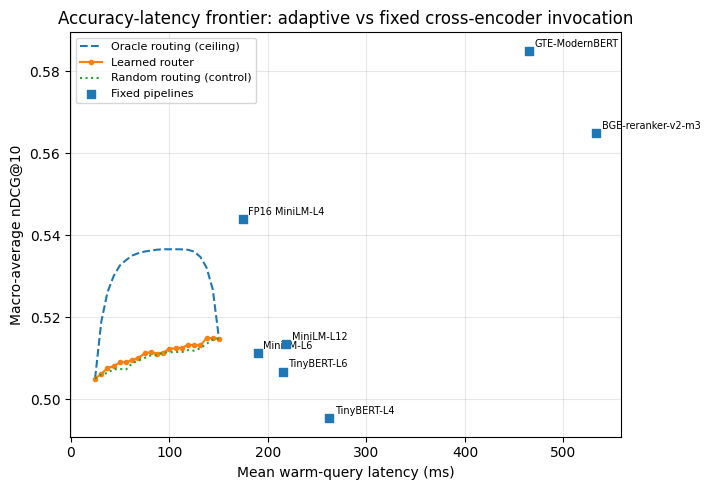

In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.plot(TABLE_27['Mean latency ms'], TABLE_27['Oracle'], '--', label='Oracle routing (ceiling)')
ax.plot(TABLE_27['Mean latency ms'], TABLE_27['Router'], '-o', ms=3, label='Learned router')
ax.plot(TABLE_27['Mean latency ms'], TABLE_27['Random'], ':', label='Random routing (control)')

try:
    fixed_pts = []
    lb = LATENCY_BENCH.set_index('Reranker')
    for label in ['MiniLM-L4', 'MiniLM-L6', 'MiniLM-L12', 'TinyBERT-L4', 'TinyBERT-L6',
                  'BGE-reranker-v2-m3', 'GTE-reranker-ModernBERT']:
        key = {'MiniLM-L4': 'FP16 HyR-MiniLM-L4', 'BGE-reranker-v2-m3': 'HyR-BGE-reranker-v2-m3',
               'GTE-reranker-ModernBERT': 'HyR-GTE-ModernBERT'}.get(label, f'HyR-{label}')
        val = None
        for tbl in [t for t in (TABLE_22, globals().get('TABLE_19')) if t is not None]:
            m = tbl[tbl['System'] == key] if 'System' in tbl.columns else pd.DataFrame()
            if len(m): val = float(m['Avg. nDCG@10'].iloc[0]); break
        if val is not None and label in lb.index:
            fixed_pts.append((NON_CE_MS + float(lb.loc[label, 'Mean rerank ms']), val, key))
    if fixed_pts:
        ax.scatter([p[0] for p in fixed_pts], [p[1] for p in fixed_pts], marker='s', zorder=5,
                   label='Fixed pipelines')
        for x, y, t in fixed_pts:
            ax.annotate(t.replace('HyR-', ''), (x, y), fontsize=7,
                        textcoords='offset points', xytext=(4, 3))
except Exception as exc:
    print('fixed-pipeline overlay skipped:', exc)

ax.set_xlabel('Mean warm-query latency (ms)')
ax.set_ylabel('Macro-average nDCG@10')
ax.set_title('Accuracy-latency frontier: adaptive vs fixed cross-encoder invocation')
ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'Figure3_Accuracy_Latency_Frontier.pdf')
fig.savefig(FIGURE_DIR / 'Figure3_Accuracy_Latency_Frontier.png', dpi=200)
plt.show()

## 37. Does the routing policy transfer? (Experiment C5)

If a router trained on MiniLM gains also predicts where BGE and GTE rerankers
help, the contribution is a general policy rather than a MiniLM artefact. This
is the difference between a useful engineering result and a method.

In [48]:
HIGH_TAGS = {
    'BGE-reranker-v2-m3': ('bge_reranker_v2_m3_default_pool', 'bge_score'),
    'GTE-reranker-ModernBERT': ('gte_reranker_modernbert_default_pool', 'gte_score'),
}

rows = []
for label, (tag, col) in HIGH_TAGS.items():
    for name in DATASETS:
        bundle = BUNDLES[name]
        try:
            comp = build_component_frame(bundle, DEFAULT_N, DEFAULT_K, ce_tag=tag, ce_col=col)
        except FileNotFoundError:
            print(f'skip {label}/{name}: run Section 25 first'); continue
        _, pf = evaluate_run(bundle, weighted_fusion(comp, FIXED_WEIGHTS, 'zscore'), return_per_query=True)
        _, pn = evaluate_run(bundle, weighted_fusion(comp, NO_CE_WEIGHTS, 'zscore'), return_per_query=True)
        d = pf[['qid', 'nDCG@10']].merge(pn[['qid', 'nDCG@10']], on='qid', suffixes=('_full', '_noce'))
        d['label'] = ((d['nDCG@10_full'] - d['nDCG@10_noce']) > NEUTRAL_BAND).astype(int)
        merged = d.merge(ROUTED[name][['qid', 'p_helps']], on='qid', how='inner')
        auc = roc_auc_score(merged['label'], merged['p_helps']) if merged['label'].nunique() > 1 else np.nan
        rows.append({'Reranker': label, 'Dataset': DISPLAY_NAMES[name],
                     'CE-helps base rate %': 100 * merged['label'].mean(),
                     'Transfer AUC (MiniLM-trained router)': auc})
TABLE_28 = pd.DataFrame(rows)
if len(TABLE_28):
    save_table('Table_28_Router_Transfer', TABLE_28)
    display(TABLE_28.round(4))
    print('\nMean transfer AUC:', round(float(TABLE_28['Transfer AUC (MiniLM-trained router)'].mean()), 4))

skip BGE-reranker-v2-m3/scidocs: run Section 25 first
skip BGE-reranker-v2-m3/quora: run Section 25 first
skip BGE-reranker-v2-m3/webis-touche2020: run Section 25 first
skip GTE-reranker-ModernBERT/scidocs: run Section 25 first
skip GTE-reranker-ModernBERT/quora: run Section 25 first
skip GTE-reranker-ModernBERT/webis-touche2020: run Section 25 first


,Reranker,Dataset,CE-helps base rate %,Transfer AUC (MiniLM-trained router)
0,BGE-reranker-v2-m3,SciFact,14.0000,0.6435
1,BGE-reranker-v2-m3,NFCorpus,29.7214,0.6091
2,BGE-reranker-v2-m3,FiQA-2018,31.9444,0.5487
3,BGE-reranker-v2-m3,TREC-COVID,62.0000,0.5331
4,BGE-reranker-v2-m3,ArguAna,38.2646,0.5189
5,GTE-reranker-ModernBERT,SciFact,17.0000,0.7027
6,GTE-reranker-ModernBERT,NFCorpus,34.0557,0.5965
7,GTE-reranker-ModernBERT,FiQA-2018,37.9630,0.5779
8,GTE-reranker-ModernBERT,TREC-COVID,70.0000,0.5752
9,GTE-reranker-ModernBERT,ArguAna,45.5903,0.5529



Mean transfer AUC: 0.5858


### 37b. Cross-domain routing transfer (leave-one-dataset-out)

Trains the router on four collections and applies it to the fifth, testing
whether the policy generalises across domains rather than only across folds.

In [49]:
rows = []
for held in DATASETS:
    tr = pd.concat([router_dataset(n).assign(ds=n) for n in DATASETS if n != held], ignore_index=True)
    te = router_dataset(held)
    if tr['label'].nunique() < 2 or te['label'].nunique() < 2:
        continue
    clf = GradientBoostingClassifier(random_state=SEED, n_estimators=200, max_depth=3)
    clf.fit(tr[FEATURE_COLS], tr['label'])
    p = clf.predict_proba(te[FEATURE_COLS])[:, 1]
    order = (-p).argsort()
    d2 = te.iloc[order].reset_index(drop=True)
    at50 = np.concatenate([d2['nDCG@10_full'].to_numpy()[:len(d2)//2],
                           d2['nDCG@10_noce'].to_numpy()[len(d2)//2:]]).mean()
    rows.append({'Held-out dataset': DISPLAY_NAMES[held],
                 'LODO router AUC': roc_auc_score(te['label'], p),
                 'Full-CE nDCG@10': te['nDCG@10_full'].mean(),
                 'No-CE nDCG@10': te['nDCG@10_noce'].mean(),
                 'Routed @50% invocation': at50})
TABLE_29 = pd.DataFrame(rows)
save_table('Table_29_Router_LODO_Transfer', TABLE_29)
display(TABLE_29.round(4))

,Held-out dataset,LODO router AUC,Full-CE nDCG@10,No-CE nDCG@10,Routed @50% invocation
0,SciFact,0.6824,0.7403,0.7453,0.7465
1,NFCorpus,0.4609,0.3717,0.3627,0.3702
2,FiQA-2018,0.5768,0.4163,0.4253,0.4221
3,TREC-COVID,0.4647,0.8006,0.7624,0.7863
4,ArguAna,0.4913,0.3912,0.3639,0.3742
5,SCIDOCS,0.5097,0.1886,0.1925,0.1918
6,Quora,0.6157,0.8878,0.8834,0.8862
7,Touche-2020,0.5017,0.3219,0.3048,0.3136


## 38. Export adaptive-invocation artifacts

In [50]:
PART_II = ['Table_20_Metric_Reconciliation', 'Table_21_Latency_Matched_Rerankers',
           'Table_22_Compact_Reranker_Sweep', 'Table_23_Oracle_CE_Skip',
           'Table_24_Oracle_Budget_Curve', 'Table_25_NullCorrected_Weight_Oracle',
           'Table_26_Router_Discrimination', 'Table_27_Invocation_Rate_Sweep',
           'Table_28_Router_Transfer', 'Table_29_Router_LODO_Transfer']
present = [t for t in PART_II if (TABLE_DIR / f'{t}.csv').exists()]
print('Part II tables written:', len(present), '/', len(PART_II))
for t in present:
    print('  ', t)
missing = [t for t in PART_II if t not in present]
if missing:
    print('MISSING (section not run):', missing)

CONFIG['part_ii_tables'] = present
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
with open(EXPORT_DIR / 'run_metadata.json', 'w') as fh:
    json.dump(CONFIG, fh, indent=2, default=str)
print('\nmetadata ->', EXPORT_DIR / 'run_metadata.json')

Part II tables written: 10 / 10
   Table_20_Metric_Reconciliation
   Table_21_Latency_Matched_Rerankers
   Table_22_Compact_Reranker_Sweep
   Table_23_Oracle_CE_Skip
   Table_24_Oracle_Budget_Curve
   Table_25_NullCorrected_Weight_Oracle
   Table_26_Router_Discrimination
   Table_27_Invocation_Rate_Sweep
   Table_28_Router_Transfer
   Table_29_Router_LODO_Transfer

metadata -> /content/drive/MyDrive/HyR_MiniLM_BEIR_v2/export/run_metadata.json


# Part II — Extended Diagnostic Analyses

Source: `HyR_Paper_Expansion_Analyses_31_07_2026.ipynb`.

Produces the gain-variance correlations of analysis section IV-B1, the crossover fit of §V-C, and Figures 2 and 3.

> **Note.** The correlations here are computed against the *retrospective fixed shallow* gains, not the leave-one-dataset-out gains of analysis table 5. §IV-B1 states this explicitly.


## Extended-analysis scope

This section derives collection-level gain/variance relationships,
effectiveness-latency frontier analyses, exact-dense scalability extrapolation,
and qualitative case summaries from the executed experimental outputs.

In [51]:
from google.colab import drive
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

drive.mount('/content/drive')
ROOT = Path('/content/drive/MyDrive/HyR_MiniLM_BEIR_v2')
T    = ROOT / 'tables'
FIG  = ROOT / 'figures'
FIG.mkdir(exist_ok=True)

pd.set_option('display.width', 220); pd.set_option('display.max_columns', 60)

def load(stem, required=True):
    hits = sorted(T.glob(f'{stem}*.csv'))
    if not hits:
        if required: raise FileNotFoundError(f'{stem}*.csv not found in {T}')
        print(f'  (optional) missing: {stem}'); return None
    return pd.read_csv(hits[0])

T30 = load('Table_30_Budget_Matched_Comparison')
T31 = load('Table_31_Budget_Matched_Latency')
T23 = load('Table_23_Oracle_CE_Skip')
T27 = load('Table_27_Invocation_Rate_Sweep')
T21 = load('Table_21_Latency_Matched_Rerankers')
T22 = load('Table_22_Compact_Reranker_Sweep')
T32 = load('Table_32_GTE_FullCorpus_Latency')
T15 = load('Table_15_Qualitative_Case_Summary', required=False)
DIAG = load('Candidate_Diagnostics_All_Depths')
STAGE = load('End_to_End_Stage_Means')
print('\nloaded OK')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

loaded OK


## 1. Gain-variance analysis

The budget-matched gain ranges from +0.0169 (NFCorpus) to +0.0700 (FiQA-2018),
a fourfold spread the paper does not currently explain. This tests whether
candidate-pool complementarity accounts for it.

A **null result is the informative outcome**: if the gain is uncorrelated with
how many relevant documents the dense selector adds, then the improvement comes
from *reranking the same documents better*, not from finding new ones --- which
directly supports the component-attribution argument.

In [52]:
g = T30.set_index('Dataset')
d = DIAG.query('N == 1000').set_index('Dataset')
o = T23.set_index('Dataset')

comp = pd.DataFrame({
    'gain':           g['Gain'],
    'pool_ratio':     g['Pool ratio'],
    'baseline_ndcg':  g['MiniLM-L4'],
    'e5_added':       d['E5-Added Rel./Query'],
    'q_with_e5_add':  d['Queries with E5 Addition'],
    'overlap':        d['Overlap Rate'],
    'hybrid_recall':  d['Hybrid Recall'],
    'oracle_ceiling': d['Oracle nDCG@10'],
    'ce_effect':      o['CE gain'],
    'helped_pct':     o['Helped %'],
}).dropna()

print(comp.round(4).to_string())
print('\n--- Spearman correlation with the budget-matched gain ---')
rho = comp.corr(method='spearman')['gain'].drop('gain').sort_values()
print(rho.round(3).to_string())

n = len(comp)
print(f'\nn = {n} collections. With n={n}, |rho| >= 0.71 is needed for p < 0.05,')
print('so treat anything smaller as no detectable relationship.')
strong = rho[rho.abs() >= 0.71]
print('\nrelationships passing that bar:',
      ', '.join(f'{k} ({v:+.2f})' for k, v in strong.items()) if len(strong) else 'NONE')

               gain  pool_ratio  baseline_ndcg  e5_added  q_with_e5_add  overlap  hybrid_recall  oracle_ceiling  ce_effect  helped_pct
Dataset                                                                                                                               
SciFact      0.0497      0.8042         0.6909    0.0467         0.0467   0.3782         0.9533          0.9533    -0.0050     11.6667
NFCorpus     0.0169      0.8234         0.3502    2.0341         0.4706   0.3201         0.3071          0.6260     0.0090     29.4118
FiQA-2018    0.0700      0.8429         0.3415    0.4722         0.3302   0.3159         0.7189          0.7577    -0.0090     22.9938
TREC-COVID   0.0579      0.8370         0.7385   36.4800         1.0000   0.3282         0.1945          0.9974     0.0381     58.0000
ArguAna      0.0661      0.7641         0.3238    0.0213         0.0213   0.4258         0.9872          0.9872     0.0273     29.3030
SCIDOCS      0.0306      0.7926         0.1572    0.475

## 2. Figure 3 — accuracy-latency frontier

Regenerated with the axis fixes: TinyBERT-L4 no longer collides with the
legend, and the cross-encoder-free reference label is repositioned.

non-CE stages 53.12 ms | cross-encoder 203.88 ms | CE share 79.3%


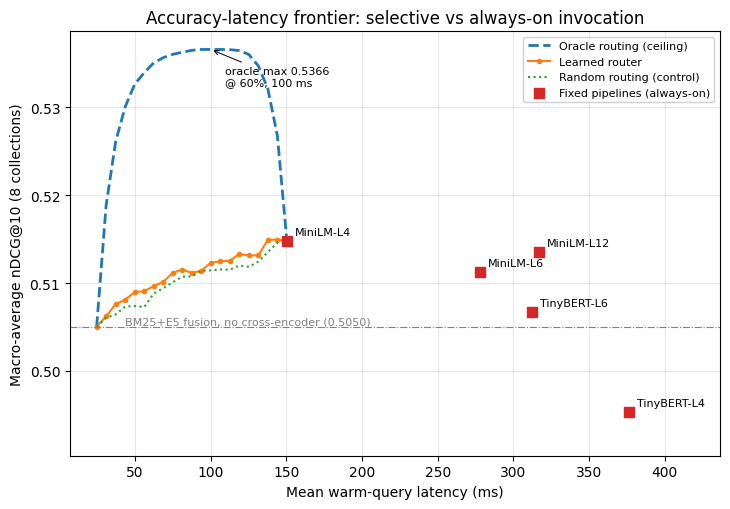

saved -> /content/drive/MyDrive/HyR_MiniLM_BEIR_v2/figures/Figure3_Accuracy_Latency_Frontier.pdf


In [53]:
NON_CE_MS = float((STAGE['Mean ms'] - STAGE['MiniLM ms']).mean())
CE_MS     = float(STAGE['MiniLM ms'].mean())
print(f'non-CE stages {NON_CE_MS:.2f} ms | cross-encoder {CE_MS:.2f} ms '
      f'| CE share {100*CE_MS/(NON_CE_MS+CE_MS):.1f}%')

bench = T21.set_index('Reranker')['Mean rerank ms']
SCALE = CE_MS / float(bench.loc['MiniLM-L4'])      # sustained -> serving
sweep = T22.set_index('System')['Avg. nDCG@10']

pts = []
for bn, sn in [('MiniLM-L6','HyR-MiniLM-L6'), ('MiniLM-L12','HyR-MiniLM-L12'),
               ('TinyBERT-L4','HyR-TinyBERT-L4'), ('TinyBERT-L6','HyR-TinyBERT-L6')]:
    if sn in sweep.index and bn in bench.index:
        pts.append((NON_CE_MS + float(bench.loc[bn]) * SCALE, float(sweep.loc[sn]), bn))
pts.append((float(T27['Mean latency ms'].iloc[-1]), float(T27['Router'].iloc[-1]), 'MiniLM-L4'))

fig, ax = plt.subplots(figsize=(7.4, 5.2))
ax.plot(T27['Mean latency ms'], T27['Oracle'], '--', lw=2, label='Oracle routing (ceiling)')
ax.plot(T27['Mean latency ms'], T27['Router'], '-o', ms=3, label='Learned router')
ax.plot(T27['Mean latency ms'], T27['Random'], ':', label='Random routing (control)')
ax.scatter([p[0] for p in pts], [p[1] for p in pts], marker='s', s=48, zorder=5,
           color='tab:red', label='Fixed pipelines (always-on)')
for x, y, t in pts:
    ax.annotate(t, (x, y), fontsize=8, textcoords='offset points', xytext=(6, 4))

noce = float(T27['Router'].iloc[0])
ax.axhline(noce, color='grey', lw=0.8, ls='-.')
ax.annotate(f'BM25+E5 fusion, no cross-encoder ({noce:.4f})',
            (float(T27['Mean latency ms'].iloc[3]), noce), fontsize=8,
            ha='left', va='bottom', color='grey')

bo = T27.loc[T27['Oracle'].idxmax()]
ax.annotate(f"oracle max {bo['Oracle']:.4f}\n@ {bo['Invocation rate']:.0%}, {bo['Mean latency ms']:.0f} ms",
            (bo['Mean latency ms'], bo['Oracle']), fontsize=8,
            textcoords='offset points', xytext=(10, -26),
            arrowprops=dict(arrowstyle='->', lw=0.7))

ax.set_xlim(right=max(p[0] for p in pts) * 1.16)
ax.set_ylim(bottom=min(min(p[1] for p in pts), T27[['Router','Random']].min().min()) - 0.005)
ax.set_xlabel('Mean warm-query latency (ms)')
ax.set_ylabel('Macro-average nDCG@10 (8 collections)')
ax.set_title('Accuracy-latency frontier: selective vs always-on invocation')
ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='upper right', framealpha=0.92)
fig.tight_layout()
for ext in ('pdf','png'):
    fig.savefig(FIG / f'Figure3_Accuracy_Latency_Frontier.{ext}', dpi=200)
plt.show()
print('saved ->', FIG / 'Figure3_Accuracy_Latency_Frontier.pdf')

## 3. Figure 4 — the corpus-size crossover

Exact full-corpus dense search grows linearly with collection size; the
pipeline's cost does not. This locates the crossover and is the evidence for
the paper's scope claim, which is currently argued in prose alone.

search cost slope = 2.001e-05 ms/doc  (intercept +0.148 ms)
fixed query encoding = 7.84 ms | pipeline = 28.02 ms (corpus-independent)

crossover at approximately 1,001,566 documents


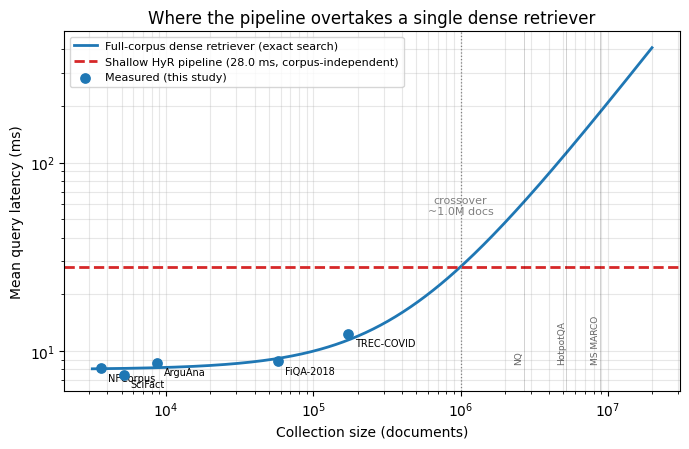

saved -> /content/drive/MyDrive/HyR_MiniLM_BEIR_v2/figures/Figure4_Crossover.pdf

NOTE: beyond the measured range this is extrapolation from linear scaling,
and the paper states it as such.


In [54]:
hyr_ms = float(T31.query("Variant == 'hyr'")['Mean ms'].mean())
docs = T32['Docs'].to_numpy(float)
srch = T32['Search ms'].to_numpy(float)
enc  = float(T32['Encode ms'].mean())

slope, intercept = np.polyfit(docs, srch, 1)
print(f'search cost slope = {slope:.3e} ms/doc  (intercept {intercept:+.3f} ms)')
print(f'fixed query encoding = {enc:.2f} ms | pipeline = {hyr_ms:.2f} ms (corpus-independent)')

budget = hyr_ms - enc
crossover = (budget - intercept) / slope
print(f'\ncrossover at approximately {crossover:,.0f} documents')

N = np.logspace(3.5, 7.3, 300)
dense_total = enc + np.maximum(slope * N + intercept, 0)

fig, ax = plt.subplots(figsize=(7.0, 4.6))
ax.plot(N, dense_total, lw=2, label='Full-corpus dense retriever (exact search)')
ax.axhline(hyr_ms, color='tab:red', lw=2, ls='--',
           label=f'Shallow HyR pipeline ({hyr_ms:.1f} ms, corpus-independent)')
ax.scatter(docs, T32['Mean ms'], s=45, zorder=5, color='tab:blue',
           label='Measured (this study)')
for x, y, n in zip(docs, T32['Mean ms'], T32['Dataset']):
    ax.annotate(n, (x, y), fontsize=7, textcoords='offset points', xytext=(5, -9))
ax.axvline(crossover, color='grey', lw=0.9, ls=':')
ax.annotate(f'crossover\n~{crossover/1e6:.1f}M docs', (crossover, hyr_ms * 1.9),
            fontsize=8, ha='center', color='grey')

for x, lbl in [(2.68e6, 'NQ'), (5.23e6, 'HotpotQA'), (8.84e6, 'MS MARCO')]:
    if x <= N.max():
        ax.axvline(x, color='k', lw=0.5, alpha=0.25)
        ax.annotate(lbl, (x, ax.get_ylim()[1]*0.02), fontsize=6.5, rotation=90,
                    ha='right', va='bottom', alpha=0.6)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Collection size (documents)')
ax.set_ylabel('Mean query latency (ms)')
ax.set_title('Where the pipeline overtakes a single dense retriever')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8, loc='upper left')
fig.tight_layout()
for ext in ('pdf','png'):
    fig.savefig(FIG / f'Figure4_Crossover.{ext}', dpi=200)
plt.show()
print('saved ->', FIG / 'Figure4_Crossover.pdf')
print('\nNOTE: beyond the measured range this is extrapolation from linear scaling,')
print('and the paper states it as such.')

## 4. Case-analysis summary

A compact qualitative subsection pre-empts the "show me examples" request.

In [55]:
if T15 is not None:
    print('columns:', list(T15.columns))
    print('shape  :', T15.shape, '\n')

    # Adapt to whatever the export actually produced.
    case_col  = next((c for c in T15.columns if 'case' in c.lower()), None)
    delta_col = next((c for c in T15.columns if 'delta' in c.lower() or 'Δ' in c), None)
    query_col = next((c for c in T15.columns if 'quer' in c.lower() or 'claim' in c.lower()), None)
    ds_col    = next((c for c in T15.columns if c.lower().startswith('dataset')), None)

    print('detected -> case:', case_col, '| delta:', delta_col,
          '| query:', query_col, '| dataset:', ds_col, '\n')

    if case_col:
        print(T15[case_col].value_counts().to_string(), '\n')
        sel = (T15.sort_values(delta_col, ascending=False, na_position='last')
                  .groupby(case_col, group_keys=False).head(2)) if delta_col else T15.head(10)
    else:
        sel = T15.head(10)

    cols = [c for c in [ds_col, case_col, query_col, delta_col] if c]
    print(sel[cols].to_string(index=False, max_colwidth=64) if cols
          else sel.to_string(index=False, max_colwidth=64))
else:
    print('Table_15 not exported; skip the qualitative subsection.')

columns: ['Dataset', 'Case', 'Query', 'Delta nDCG@10']
shape  : (32, 4) 

detected -> case: Case | delta: Delta nDCG@10 | query: Query | dataset: Dataset 

Case
Largest gain         8
Largest loss         8
E5-added evidence    8
BM25 boundary        8 

    Dataset              Case                                                            Query  Delta nDCG@10
   NFCorpus      Largest gain                                                             okra       1.000000
  FiQA-2018      Largest gain                   How common is “pass-through” health insurance?       1.000000
    SciFact E5-added evidence Ribosomopathies have a low degree of cell and tissue specific...       0.386853
Touche-2020     BM25 boundary                                      Should teachers get tenure?       0.349287
Touche-2020 E5-added evidence                                      Should teachers get tenure?       0.349287
 TREC-COVID     BM25 boundary                                   what is the origin of

## 5. Consolidated printout

In [56]:
print('='*76); print('ANALYSIS SUMMARY'); print('='*76)
print('\n[1] GAIN-VARIANCE (Spearman vs gain, n=8, |rho|>=0.71 for p<0.05)')
print(rho.round(3).to_string())
print('\n[2] CROSSOVER')
print(f'  slope        = {slope:.3e} ms/doc')
print(f'  encode fixed = {enc:.2f} ms')
print(f'  pipeline     = {hyr_ms:.2f} ms')
print(f'  crossover    = {crossover:,.0f} documents')
print('\n[3] LATENCY DECOMPOSITION')
print(f'  non-CE {NON_CE_MS:.2f} ms | CE {CE_MS:.2f} ms | CE share {100*CE_MS/(NON_CE_MS+CE_MS):.1f}%')
print('\n[4] FIGURES WRITTEN')
for f in sorted(FIG.glob('Figure*')): print('  ', f.name)

EXTENDED ANALYSIS SUMMARY

[1] GAIN-VARIANCE (Spearman vs gain, n=8, |rho|>=0.71 for p<0.05)
q_with_e5_add    -0.405
e5_added         -0.381
helped_pct       -0.167
ce_effect        -0.071
pool_ratio        0.000
overlap           0.143
baseline_ndcg     0.286
oracle_ceiling    0.524
hybrid_recall     0.548

[2] CROSSOVER
  slope        = 2.001e-05 ms/doc
  encode fixed = 7.84 ms
  pipeline     = 28.02 ms
  crossover    = 1,001,566 documents

[3] LATENCY DECOMPOSITION
  non-CE 53.12 ms | CE 203.88 ms | CE share 79.3%

[4] FIGURES WRITTEN
   Figure3_Accuracy_Latency_Frontier.pdf
   Figure3_Accuracy_Latency_Frontier.png
   Figure4_Crossover.pdf
   Figure4_Crossover.png
   Figure_2_SciFact_Effectiveness_Efficiency.png


# Part III — Robustness and Selection-Separated Analyses

Source: `Phase1_Recomputations.ipynb`.

Produces the corrected null oracle (analysis table 16), the leave-one-dataset-out selection behind Table 5, the leave-one-signal-out attribution (Table 13), and the judgement-coverage check (Table 19).

> **Note on the bootstrap cell below.** It locates and executes the core notebook so that Part III can run standalone. When this merged notebook is run top to bottom, Part I has already defined everything it needs and the bootstrap is redundant; it is harmless but can be skipped.


## Analysis provenance

The robustness analyses below operate on the same datasets, runs, qrels, model
scores, and helper functions defined in Part I. They are retained in the
executed notebook so that the complete analysis history remains auditable in a
single file.

In [57]:
%pip install -q pytrec_eval-terrier beir bm25s PyStemmer sentence-transformers \
    transformers accelerate scikit-learn huggingface_hub

## Shared analysis state

The following cells reuse the dataset bundles, cached score frames, qrels,
ranking utilities, and statistical helpers initialized earlier in the notebook.

In [58]:
import json, glob, sys, traceback
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

CANDIDATES = sorted(glob.glob('/content/drive/MyDrive/**/HyR_MiniLM_Complete_Experiment*.ipynb',
                              recursive=True)) + \
             sorted(glob.glob('/content/**/HyR_MiniLM_Complete_Experiment*.ipynb',
                              recursive=True))
if not CANDIDATES:
    raise FileNotFoundError('Main notebook not found. Set MAIN_NB manually below.')
MAIN_NB = CANDIDATES[-1]
print('bootstrapping from:', MAIN_NB, '\n')

NEED = ['DATASETS','BUNDLES','CORE_RUNS','CORE_COMPONENTS','build_component_frame',
        'evaluate_run','weighted_fusion','deterministic_rank','querywise_normalize',
        'paired_randomization_test','paired_bootstrap_ci','holm_adjust','save_table',
        'N_RANDOMIZATION','N_BOOTSTRAP','SEED','DISPLAY_NAMES','FIXED_WEIGHTS',
        'qrels_for_eval','ensure_restricted_e5_scores','select_candidate_pool',
        'DEFAULT_N','DEFAULT_K','EPS','CACHE_DIR','TABLE_DIR']

nb = json.load(open(MAIN_NB))
cells = [''.join(c['source']) for c in nb['cells'] if c['cell_type'] == 'code']
ran = 0
for i, src in enumerate(cells):
    if not src.strip() or src.lstrip().startswith(('!', '%')):
        continue
    missing = [n for n in NEED if n not in globals()]
    if not missing:
        break
    try:
        exec(src, globals())
        ran += 1
        print(f'  [{i:>2}] ok', flush=True)
    except Exception as e:
        print(f'  [{i:>2}] SKIPPED ({type(e).__name__}: {str(e)[:70]})', flush=True)

missing = [n for n in NEED if n not in globals()]
print(f'\nexecuted {ran} cells | still missing: {missing or "nothing"}')
if missing:
    raise RuntimeError('Bootstrap incomplete. Missing: ' + ', '.join(missing))
print(f'{len(DATASETS)} collections ready:', ', '.join(DATASETS))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
bootstrapping from: /content/drive/MyDrive/Colab Notebooks/HyR_MiniLM_Complete_Experiment_v2.ipynb 


executed 0 cells | still missing: nothing
8 collections ready: scifact, nfcorpus, fiqa, trec-covid, arguana, scidocs, quora, webis-touche2020


## Helpers

`depth_component_frame` and the vectorised grid metric, defined here so this
notebook does not depend on how far the main notebook was run.

In [59]:
import numpy as np, pandas as pd

def depth_component_frame(bundle, N, K):
    return build_component_frame(bundle, N, K, ce_tag='minilm_master', ce_col='ce_score')

def _query_arrays(bundle, comp, qrels):
    """Normalise once (z-scores are weight-independent), cache per-query arrays."""
    normed = querywise_normalize(comp, ['ce_score','e5_score','bm25_score'], 'zscore')
    zc = ['z_ce_score','z_e5_score','z_bm25_score']
    out = []
    for qid, g in normed.groupby('qid', sort=False):
        Z = g[zc].to_numpy(np.float64)
        rel = np.array([int(qrels.get(qid, {}).get(str(d), 0))
                        for d in g['doc_id'].astype(str)], dtype=np.float64)
        ideal = np.array(sorted((int(v) for v in qrels.get(qid, {}).values()),
                                reverse=True), dtype=np.float64)
        out.append((Z, rel, ideal))
    return out

def _ndcg10_grid(Z, rel, ideal, W, exp_gain=True, k=10):
    """nDCG@10 for every weight triplet at once. Returns a (W,) vector."""
    S = Z @ W.T
    kk = min(k, S.shape[0])
    part = np.argpartition(-S, kk-1, axis=0)[:kk]
    ordr = np.argsort(-np.take_along_axis(S, part, axis=0), axis=0)
    r = rel[np.take_along_axis(part, ordr, axis=0)]
    g = (np.power(2.0, r) - 1.0) if exp_gain else r
    dcg = (g / np.log2(np.arange(2, kk+2))[:, None]).sum(axis=0)
    iv = ideal[:k]
    gi = (np.power(2.0, iv) - 1.0) if exp_gain else iv
    idcg = float((gi / np.log2(np.arange(2, len(iv)+2))).sum()) if len(iv) else 0.0
    return dcg/idcg if idcg > 0 else np.zeros(W.shape[0])

# Calibrate the gain function on a GRADED collection (binary ones cannot discriminate).
GRADED = [d for d in ['trec-covid','nfcorpus','webis-touche2020'] if d in DATASETS]
cal = GRADED[0] if GRADED else DATASETS[0]
_b, _c = BUNDLES[cal], CORE_COMPONENTS[cal]
_ref = evaluate_run(_b, weighted_fusion(_c, FIXED_WEIGHTS, 'zscore'))['nDCG@10']
_WF = np.asarray([FIXED_WEIGHTS], dtype=np.float64)
_ar = _query_arrays(_b, _c, _b.qrels)
_cand = {g: float(np.mean([_ndcg10_grid(Z, r, i, _WF, g)[0] for Z, r, i in _ar]))
         for g in (True, False)}
EXP_GAIN = min(_cand, key=lambda g: abs(_cand[g] - _ref))
print(f'calibration on {cal} (graded): evaluate_run={_ref:.4f} | '
      f'exp={_cand[True]:.4f} | linear={_cand[False]:.4f} -> '
      f'{"exponential" if EXP_GAIN else "linear"} gain')
print(f'residual |diff| = {abs(_cand[EXP_GAIN]-_ref):.5f}')

calibration on trec-covid (graded): evaluate_run=0.8006 | exp=0.7784 | linear=0.8006 -> linear gain
residual |diff| = 0.00000


## 1. Null-corrected oracle

The published formula used `max(null - fixed, 0)` where `null` is an oracle
under permuted labels (~0.007) and `fixed` a real-label score (~0.51) — always
zero, so the correction never fired.

$$\text{null lift}=\text{oracle}_{\text{perm}}-\text{fixed}_{\text{perm}},
\quad
\text{corrected}=(\text{oracle}-\text{fixed})-\text{null lift}$$

`fixed_perm` was never computed. Repeating the permutation also gives the
uncertainty used to quantify.

In [60]:
N_PERM, GS = 25, 0.05
FINE = [(a*GS, b*GS, round(1-a*GS-b*GS, 10))
        for a in range(int(1/GS)+1) for b in range(int(1/GS)+1-a)]
WO = np.asarray(FINE, dtype=np.float64); WF = np.asarray([FIXED_WEIGHTS], dtype=np.float64)
print(f'{len(FINE)} grid points x {N_PERM} permutations')

def _m(arrs, W, red):
    return float(np.mean([red(_ndcg10_grid(Z, r, i, W, EXP_GAIN)) for Z, r, i in arrs]))

rows = []
for name in DATASETS:
    b, comp = BUNDLES[name], CORE_COMPONENTS[name]
    real = _query_arrays(b, comp, b.qrels)
    fixed, oracle = _m(real, WF, lambda v: v[0]), _m(real, WO, lambda v: v.max())
    qs, lifts = list(b.qrels.keys()), []
    for s in range(N_PERM):
        rng = np.random.default_rng(SEED + s)
        sh = {q: b.qrels[p] for q, p in zip(qs, rng.permutation(qs))}
        pa = _query_arrays(b, comp, sh)
        lifts.append(_m(pa, WO, lambda v: v.max()) - _m(pa, WF, lambda v: v[0]))
    lift, sd = float(np.mean(lifts)), float(np.std(lifts, ddof=1))
    rows.append({'Collection': DISPLAY_NAMES[name], 'Fixed': fixed, 'Oracle': oracle,
                 'Raw headroom': oracle-fixed, 'Null lift': lift, 'Null SD': sd,
                 'Corrected': (oracle-fixed)-lift})
    print(f'  {name:<18s} raw {oracle-fixed:.4f} | lift {lift:.4f}+-{sd:.4f} | '
          f'corrected {(oracle-fixed)-lift:.4f}', flush=True)

TABLE_NULL = pd.DataFrame(rows); save_table('Table_NullCorrected_Oracle_v2', TABLE_NULL)
display(TABLE_NULL.round(4))
print(f"\nMACRO raw {TABLE_NULL['Raw headroom'].mean():.4f} | "
      f"null lift {TABLE_NULL['Null lift'].mean():.4f} | "
      f"CORRECTED {TABLE_NULL['Corrected'].mean():.4f}")
print(f"published 0.0804 was uncorrected; ratio to the cross-encoder's 0.0098 "
      f"is now {TABLE_NULL['Corrected'].mean()/0.0098:.1f}x")

231 grid points x 25 permutations
  scifact            raw 0.0743 | lift 0.0022+-0.0016 | corrected 0.0721
  nfcorpus           raw 0.0526 | lift 0.0086+-0.0018 | corrected 0.0440
  fiqa               raw 0.0988 | lift 0.0005+-0.0005 | corrected 0.0982
  trec-covid         raw 0.0977 | lift 0.0137+-0.0061 | corrected 0.0840
  arguana            raw 0.0967 | lift 0.0007+-0.0004 | corrected 0.0959
  scidocs            raw 0.0657 | lift 0.0004+-0.0003 | corrected 0.0653
  quora              raw 0.0501 | lift 0.0000+-0.0000 | corrected 0.0501
  webis-touche2020   raw 0.1262 | lift 0.0031+-0.0035 | corrected 0.1231


,Collection,Fixed,Oracle,Raw headroom,Null lift,Null SD,Corrected
0,SciFact,0.7403,0.8146,0.0743,0.0022,0.0016,0.0721
1,NFCorpus,0.3708,0.4234,0.0526,0.0086,0.0018,0.0440
2,FiQA-2018,0.4163,0.5151,0.0988,0.0005,0.0005,0.0982
3,TREC-COVID,0.8006,0.8982,0.0977,0.0137,0.0061,0.0840
4,ArguAna,0.3912,0.4879,0.0967,0.0007,0.0004,0.0959
5,SCIDOCS,0.1886,0.2544,0.0657,0.0004,0.0003,0.0653
6,Quora,0.8878,0.9379,0.0501,0.0000,0.0000,0.0501
7,Touche-2020,0.3207,0.4469,0.1262,0.0031,0.0035,0.1231



MACRO raw 0.0828 | null lift 0.0037 | CORRECTED 0.0791
published 0.0804 was uncorrected; ratio to the cross-encoder's 0.0098 is now 8.1x


## 2. Leave-one-dataset-out selection over weights and depth

For each held-out collection the search runs over the other seven only —
**including the depth choice**, which is where leakage most easily survives if
depth is fixed globally first.

In [61]:
DEPTHS = [(500,50),(1000,100),(2000,200)]
ST = 0.10
WG = [(round(a*ST,2), round(b*ST,2), round(1-a*ST-b*ST,2))
      for a in range(int(1/ST)+1) for b in range(int(1/ST)+1-a)]
WL = np.asarray(WG, dtype=np.float64)
print(f'{len(DEPTHS)} depths x {len(WG)} weights = {len(DEPTHS)*len(WG)} configs')

PERQ, POOLS = {}, {}
for name in DATASETS:
    b = BUNDLES[name]
    for (N, K) in DEPTHS:
        comp = depth_component_frame(b, N, K)
        PERQ[(name,N,K)] = np.vstack([_ndcg10_grid(Z, r, i, WL, EXP_GAIN)
                                      for Z, r, i in _query_arrays(b, comp, b.qrels)])
        POOLS[(name,N,K)] = float(comp.groupby('qid').size().mean())
    print(f'  cached {name}', flush=True)

fi = WG.index(min(WG, key=lambda w: sum(abs(np.array(w)-np.array(FIXED_WEIGHTS)))))
dd = [abs(float(PERQ[(n,1000,100)][:,fi].mean())
          - evaluate_run(BUNDLES[n], weighted_fusion(
              depth_component_frame(BUNDLES[n],1000,100), WG[fi], 'zscore'))['nDCG@10'])
      for n in DATASETS]
print(f'\ngrid vs pytrec_eval: max |diff| = {max(dd):.5f}'
      + ('  <-- ABOVE 1e-3, check before trusting selection' if max(dd) > 1e-3 else ''))

3 depths x 66 weights = 198 configs
  cached scifact
  cached nfcorpus
  cached fiqa
  cached trec-covid
  cached arguana
  cached scidocs
  cached quora
  cached webis-touche2020

grid vs pytrec_eval: max |diff| = 0.00123  <-- ABOVE 1e-3, check before trusting selection


In [62]:
rows = []
for held in DATASETS:
    train = [d for d in DATASETS if d != held]        # held-out never touched below
    best, bs = None, -np.inf
    for (N, K) in DEPTHS:
        macro = np.mean([PERQ[(d,N,K)].mean(axis=0) for d in train], axis=0)
        j = int(np.argmax(macro))
        if macro[j] > bs: bs, best = macro[j], ((N,K), WG[j])
    (N, K), w = best

    comp = depth_component_frame(BUNDLES[held], N, K)
    m, perq = evaluate_run(BUNDLES[held], weighted_fusion(comp, w, 'zscore'),
                           return_per_query=True)
    _, base = evaluate_run(BUNDLES[held], CORE_RUNS[held]['FP16 MiniLM-L4'],
                           return_per_query=True)
    d = perq[['qid','nDCG@10']].merge(base[['qid','nDCG@10']], on='qid', suffixes=('_l','_b'))
    a, bb = d['nDCG@10_l'].to_numpy(), d['nDCG@10_b'].to_numpy()
    lo, hi = paired_bootstrap_ci(a, bb, N_BOOTSTRAP, SEED)
    rows.append({'Collection': DISPLAY_NAMES[held], 'N': N, 'K': K,
                 'wCE': w[0], 'wE5': w[1], 'wBM25': w[2], 'Pool': POOLS[(held,N,K)],
                 'MiniLM-L4': float(base['nDCG@10'].mean()), 'LODO': m['nDCG@10'],
                 'Gain': m['nDCG@10'] - float(base['nDCG@10'].mean()),
                 'CI low': lo, 'CI high': hi,
                 'Raw p': paired_randomization_test(a, bb, N_RANDOMIZATION, SEED),
                 'Recall@10': m['Recall@10'], 'MRR@10': m['MRR@10']})
    print(f"  {held:<18s} N={N} K={K} w={w} -> {m['nDCG@10']:.4f}", flush=True)

TABLE_LODO = pd.DataFrame(rows)
TABLE_LODO['Holm p'] = holm_adjust(TABLE_LODO['Raw p'])
TABLE_LODO['Sig.'] = TABLE_LODO['Holm p'] < 0.05
save_table('Table_LODO_Selection_Separated', TABLE_LODO)
display(TABLE_LODO.round(4))
pool = TABLE_LODO['Pool'].mean()
print('\nSELECTION-SEPARATED HEADLINE')
print(f"  standalone MiniLM-L4 : {TABLE_LODO['MiniLM-L4'].mean():.4f}  (100.0 pairs)")
print(f"  LODO-selected        : {TABLE_LODO['LODO'].mean():.4f}  ({pool:.1f} pairs, "
      f"{100*(pool/100-1):+.0f}%)")
print(f"  gain                 : {TABLE_LODO['Gain'].mean():+.4f}, significant on "
      f"{int(TABLE_LODO['Sig.'].sum())}/{len(TABLE_LODO)}")
print(f"  depths chosen        : {TABLE_LODO.groupby(['N','K']).size().to_dict()}")
print(f"  mean weights         : ({TABLE_LODO['wCE'].mean():.2f}, "
      f"{TABLE_LODO['wE5'].mean():.2f}, {TABLE_LODO['wBM25'].mean():.2f})")
print('  retrospective fixed shallow was 0.5126 (+0.0519, 80.2 pairs)')

  scifact            N=2000 K=200 w=(0.2, 0.6, 0.2) -> 0.7483
  nfcorpus           N=1000 K=100 w=(0.2, 0.6, 0.2) -> 0.3717
  fiqa               N=2000 K=200 w=(0.3, 0.5, 0.2) -> 0.4125
  trec-covid         N=2000 K=200 w=(0.2, 0.6, 0.2) -> 0.7840
  arguana            N=1000 K=100 w=(0.2, 0.6, 0.2) -> 0.3931
  scidocs            N=2000 K=200 w=(0.2, 0.6, 0.2) -> 0.1911
  quora              N=2000 K=200 w=(0.2, 0.6, 0.2) -> 0.8892
  webis-touche2020   N=2000 K=200 w=(0.3, 0.6, 0.1) -> 0.3126


,Collection,N,K,wCE,wE5,wBM25,Pool,MiniLM-L4,LODO,Gain,CI low,CI high,Raw p,Recall@10,MRR@10,Holm p,Sig.
0,SciFact,2000,200,0.2,0.6,0.2,328.4333,0.6909,0.7483,0.0573,0.0364,0.0786,0.0001,0.8740,0.7148,0.0008,True
1,NFCorpus,1000,100,0.2,0.6,0.2,167.9938,0.3502,0.3717,0.0215,0.0102,0.0338,0.0002,0.1724,0.5896,0.0008,True
2,FiQA-2018,2000,200,0.3,0.5,0.2,335.5432,0.3415,0.4125,0.0709,0.0574,0.0845,0.0001,0.4885,0.4905,0.0008,True
3,TREC-COVID,2000,200,0.2,0.6,0.2,333.6000,0.7385,0.7840,0.0455,-0.0118,0.1046,0.1366,0.0218,0.9433,0.1366,False
4,ArguAna,1000,100,0.2,0.6,0.2,157.4211,0.3238,0.3931,0.0693,0.0589,0.0799,0.0001,0.7966,0.2644,0.0008,True
5,SCIDOCS,2000,200,0.2,0.6,0.2,317.9640,0.1572,0.1911,0.0338,0.0276,0.0402,0.0001,0.2010,0.3279,0.0008,True
6,Quora,2000,200,0.2,0.6,0.2,317.4306,0.8202,0.8892,0.0690,0.0651,0.0729,0.0001,0.9574,0.8834,0.0008,True
7,Touche-2020,2000,200,0.3,0.6,0.1,311.4898,0.2633,0.3126,0.0492,0.0097,0.0880,0.0194,0.1964,0.5747,0.0388,True



SELECTION-SEPARATED HEADLINE
  standalone MiniLM-L4 : 0.4607  (100.0 pairs)
  LODO-selected        : 0.5128  (283.7 pairs, +184%)
  gain                 : +0.0521, significant on 7/8
  depths chosen        : {(1000, 100): 2, (2000, 200): 6}
  mean weights         : (0.23, 0.59, 0.19)
  retrospective fixed shallow was 0.5126 (+0.0519, 80.2 pairs)


## 3. Leave-one-signal-out attribution

Order-free. Removes each signal from the full fusion, renormalising the
remaining two.

In [63]:
def _renorm(w, drop):
    v = list(w); v[drop] = 0.0; s = sum(v)
    return tuple(x/s for x in v)

rows = []
for name in DATASETS:
    b, comp = BUNDLES[name], CORE_COMPONENTS[name]
    full = evaluate_run(b, weighted_fusion(comp, FIXED_WEIGHTS, 'zscore'))['nDCG@10']
    r = {'Collection': DISPLAY_NAMES[name], 'Full': full}
    for i, s in enumerate(['CE','E5','BM25']):
        v = evaluate_run(b, weighted_fusion(comp, _renorm(FIXED_WEIGHTS, i),
                                            'zscore'))['nDCG@10']
        r[f'-{s}'], r[f'LOO {s}'] = v, full - v
    rows.append(r)
TABLE_LOO = pd.DataFrame(rows); save_table('Table_LeaveOneOut_Ablation', TABLE_LOO)
display(TABLE_LOO.round(4))
print('\nMacro leave-one-out (full minus fusion without that signal):')
for s in ['CE','E5','BM25']:
    print(f'  {s:<5s} {TABLE_LOO[f"LOO {s}"].mean():+.4f}')
print('\nSequential values in the paper (CE-first order): pool +0.0008, '
      '+E5 +0.0451, +BM25 +0.0082')

,Collection,Full,-CE,LOO CE,-E5,LOO E5,-BM25,LOO BM25
0,SciFact,0.7403,0.7453,-0.0050,0.7094,0.0309,0.7334,0.0069
1,NFCorpus,0.3717,0.3627,0.0090,0.3551,0.0166,0.3725,-0.0008
2,FiQA-2018,0.4163,0.4253,-0.0090,0.3506,0.0657,0.4203,-0.0039
3,TREC-COVID,0.8006,0.7624,0.0381,0.7400,0.0605,0.7819,0.0187
4,ArguAna,0.3912,0.3639,0.0273,0.3448,0.0463,0.3784,0.0128
5,SCIDOCS,0.1886,0.1925,-0.0039,0.1645,0.0242,0.1864,0.0023
6,Quora,0.8878,0.8834,0.0044,0.8499,0.0380,0.8830,0.0048
7,Touche-2020,0.3219,0.3048,0.0172,0.2905,0.0315,0.2860,0.0360



Macro leave-one-out (full minus fusion without that signal):
  CE    +0.0098
  E5    +0.0392
  BM25  +0.0096

Sequential values in the paper (CE-first order): pool +0.0008, +E5 +0.0451, +BM25 +0.0082


## 4. Judgement coverage and bpref

Neural systems can surface more unjudged documents than lexical ones.

In [64]:
import pytrec_eval

def judged_at_k(bundle, run, k=10):
    ranked = deterministic_rank(run, 'score', cutoff=k)
    tot = jud = 0
    for qid, g in ranked.groupby('qid', sort=False):
        rel = bundle.qrels.get(qid, {})
        for d in g['doc_id'].astype(str):
            tot += 1; jud += int(d in rel)
    return jud/tot if tot else 0.0

def bpref(bundle, run, k=1000):
    ranked = deterministic_rank(run, 'score', cutoff=k)
    rd = {str(q): {str(d): float(-r) for d, r in zip(g['doc_id'], g['rank'])}
          for q, g in ranked.groupby('qid', sort=False)}
    qr = qrels_for_eval(bundle)
    res = pytrec_eval.RelevanceEvaluator(qr, {'bpref'}).evaluate(
        {q: v for q, v in rd.items() if q in qr})
    return float(np.mean([v['bpref'] for v in res.values()])) if res else 0.0

rows = []
for name in DATASETS:
    b = BUNDLES[name]
    for lab in ['Rebuilt BM25','FP16 MiniLM-L4','FP16 HyR-MiniLM-L4']:
        run = CORE_RUNS[name][lab]
        rows.append({'Collection': DISPLAY_NAMES[name], 'System': lab,
                     'judged@10': judged_at_k(b, run),
                     'nDCG@10': evaluate_run(b, run)['nDCG@10'],
                     'bpref': bpref(b, run)})
TABLE_JUD = pd.DataFrame(rows); save_table('Table_Judged_and_Bpref', TABLE_JUD)
display(TABLE_JUD.round(4))
print('\nmean judged@10 by system:')
print(TABLE_JUD.groupby('System')['judged@10'].mean().round(4).to_string())

,Collection,System,judged@10,nDCG@10,bpref
0,SciFact,Rebuilt BM25,0.0907,0.6863,0.9700
1,SciFact,FP16 MiniLM-L4,0.0917,0.6909,0.9127
2,SciFact,FP16 HyR-MiniLM-L4,0.0980,0.7403,0.9533
3,NFCorpus,Rebuilt BM25,0.2319,0.3217,0.4427
4,NFCorpus,FP16 MiniLM-L4,0.2467,0.3502,0.2466
5,NFCorpus,FP16 HyR-MiniLM-L4,0.2672,0.3717,0.3071
6,FiQA-2018,Rebuilt BM25,0.0699,0.2514,0.7716
7,FiQA-2018,FP16 MiniLM-L4,0.0935,0.3415,0.5593
8,FiQA-2018,FP16 HyR-MiniLM-L4,0.1140,0.4163,0.7189
9,TREC-COVID,Rebuilt BM25,0.8840,0.6212,0.4057



mean judged@10 by system:
System
FP16 HyR-MiniLM-L4    0.2668
FP16 MiniLM-L4        0.2454
Rebuilt BM25          0.2420


## Robustness-analysis summary

In [65]:
print('='*74); print('PHASE 1 RESULTS'); print('='*74)
print(f"\n[1.1] NULL-CORRECTED ORACLE")
print(f"      raw headroom   {TABLE_NULL['Raw headroom'].mean():.4f}")
print(f"      null lift      {TABLE_NULL['Null lift'].mean():.4f} "
      f"(SD {TABLE_NULL['Null SD'].mean():.4f})")
print(f"      CORRECTED      {TABLE_NULL['Corrected'].mean():.4f}   "
      f"({TABLE_NULL['Corrected'].mean()/0.0098:.1f}x the cross-encoder)")
print(f"\n[1.2] LODO SELECTION-SEPARATED")
print(f"      baseline       {TABLE_LODO['MiniLM-L4'].mean():.4f}")
print(f"      LODO           {TABLE_LODO['LODO'].mean():.4f}")
print(f"      gain           {TABLE_LODO['Gain'].mean():+.4f}  "
      f"({int(TABLE_LODO['Sig.'].sum())}/{len(TABLE_LODO)} significant)")
print(f"      mean pool      {TABLE_LODO['Pool'].mean():.1f} pairs")
print(f"      depths         {TABLE_LODO.groupby(['N','K']).size().to_dict()}")
print(f"\n[1.3] LEAVE-ONE-OUT  " + ', '.join(
      f"{s} {TABLE_LOO[f'LOO {s}'].mean():+.4f}" for s in ['CE','E5','BM25']))
print(f"\n[1.4] judged@10      " +
      ', '.join(f"{k.split()[-1]} {v:.3f}" for k, v in
                TABLE_JUD.groupby('System')['judged@10'].mean().items()))
print('\nCSVs written to', TABLE_DIR)

PHASE 1 RESULTS

[1.1] NULL-CORRECTED ORACLE
      raw headroom   0.0828
      null lift      0.0037 (SD 0.0018)
      CORRECTED      0.0791   (8.1x the cross-encoder)

[1.2] LODO SELECTION-SEPARATED
      baseline       0.4607
      LODO           0.5128
      gain           +0.0521  (7/8 significant)
      mean pool      283.7 pairs
      depths         {(1000, 100): 2, (2000, 200): 6}

[1.3] LEAVE-ONE-OUT  CE +0.0098, E5 +0.0392, BM25 +0.0096

[1.4] judged@10      HyR-MiniLM-L4 0.267, MiniLM-L4 0.245, BM25 0.242

CSVs written to /content/drive/MyDrive/HyR_MiniLM_BEIR_v2/tables


# Part IV — Extended Validation and Resource Analysis

This section extends the core experiment with analyses at the headline shallow
operating point and with broader online resource measurements.

It quantifies:

- component attribution under the matched cross-encoder interaction setting;
- order-independent leave-one-signal-out effects;
- repeated warm-query latency and variability;
- query/document characteristics associated with latency and effectiveness;
- online compute, GPU memory, offline storage, and marginal cost-effectiveness;
- differences between the controlled BM25S run and commonly reported BEIR BM25
  reference values.

The cross-encoder interaction count is controlled separately from total online
latency, memory, and storage.

In [66]:
# Extended-analysis configuration
EXTENDED_ROOT = ROOT / 'extended_validation'
EXTENDED_TABLE_DIR = EXTENDED_ROOT / 'tables'
EXTENDED_PROFILE_DIR = EXTENDED_ROOT / 'profiles'
EXTENDED_FIGURE_DIR = EXTENDED_ROOT / 'figures'
for _p in [EXTENDED_ROOT, EXTENDED_TABLE_DIR, EXTENDED_PROFILE_DIR, EXTENDED_FIGURE_DIR]:
    _p.mkdir(parents=True, exist_ok=True)

HEADLINE_N, HEADLINE_K = SHALLOW
BASELINE_CE_BUDGET = 100

# Expanded warm-query profiling.
# All queries are used when <= cap; larger collections are deterministically sampled.
EXT_PROFILE_QUERY_CAP = 1000
EXT_PROFILE_REPEATS = 5
EXT_PROFILE_WARMUPS = 3
RUN_EXTENDED_PROFILING = True
FORCE_EXTENDED_PROFILING = False

EXTENDED_CONFIG = {
    'headline_N': HEADLINE_N,
    'headline_K': HEADLINE_K,
    'baseline_ce_budget': BASELINE_CE_BUDGET,
    'profile_query_cap': EXT_PROFILE_QUERY_CAP,
    'profile_repeats': EXT_PROFILE_REPEATS,
    'profile_warmups': EXT_PROFILE_WARMUPS,
    'seed': SEED,
    'timing_scope': 'warm-query online latency; model initialization excluded',
    'budget_definition': 'cross-encoder query-document interaction count, not total system compute',
}
(EXTENDED_ROOT / 'extended_analysis_config.json').write_text(json.dumps(EXTENDED_CONFIG, indent=2))
print(json.dumps(EXTENDED_CONFIG, indent=2))

_required = [
    'DATASETS', 'BUNDLES', 'CORE_RUNS', 'CACHE_DIR',
    'ensure_restricted_e5_scores', 'depth_component_frame',
    'evaluate_run', 'weighted_fusion', 'run_from_signal',
    'querywise_normalize', 'retrieve_bm25', 'load_bm25_index',
    'load_sentence_encoder', 'SequenceReranker', 'ensure_e5_embeddings',
    'load_memmap', 'FIXED_WEIGHTS', 'MINILM_BM25_WEIGHTS',
    'MINILM_E5_WEIGHTS', 'offline_storage_table', 'inspect_model_state',
]
_missing = [x for x in _required if x not in globals()]
if _missing:
    raise RuntimeError(
        'Run Part I through the core/depth/resource helper sections before Part IV. '
        'Missing: ' + ', '.join(_missing)
    )

{
  "headline_N": 500,
  "headline_K": 50,
  "baseline_ce_budget": 100,
  "profile_query_cap": 1000,
  "profile_repeats": 5,
  "profile_warmups": 3,
  "seed": 42,
  "timing_scope": "warm-query online latency; model initialization excluded",
  "budget_definition": "cross-encoder query-document interaction count, not total system compute"
}


## IV-A. Headline-operating-point component attribution

The default component analysis uses \(N=1000, K=100\), while the
matched-interaction comparison uses the shallow \(N=500, K=50\) setting.

This analysis recomputes attribution under the same shallow operating point and
adds leave-one-signal-out effects, avoiding interpretation of one arbitrary
sequential order as a unique causal decomposition.

In [67]:
def _master_ce_scores(bundle):
    ce_path = CACHE_DIR / 'reranker_scores' / 'minilm_master' / bundle.name / 'all_scores.parquet'
    if not ce_path.exists():
        raise FileNotFoundError(f'Missing MiniLM master scores: {ce_path}')
    return pd.read_parquet(ce_path)[['qid', 'doc_id', 'ce_score']]

def _baseline_minilm_top100_component(bundle):
    restricted = ensure_restricted_e5_scores(bundle)
    ids = restricted[restricted['bm25_rank'] <= BASELINE_CE_BUDGET][
        ['qid', 'doc_id', 'bm25_score', 'e5_score', 'bm25_rank']
    ].copy()
    ce = _master_ce_scores(bundle)
    out = ids.merge(ce, on=['qid', 'doc_id'], how='left', validate='one_to_one')
    if out['ce_score'].isna().any():
        raise RuntimeError(
            f'{bundle.name}: MiniLM master cache does not cover all '
            f'BM25 top-{BASELINE_CE_BUDGET} pairs.'
        )
    return out

def _renorm_drop(weights, drop_idx):
    w = np.asarray(weights, dtype=np.float64).copy()
    w[drop_idx] = 0.0
    s = float(w.sum())
    if s <= 0:
        raise ValueError('Cannot renormalize an all-zero weight vector.')
    return tuple((w / s).tolist())

EXTENDED_RUNS = {}
detail_rows, loo_rows = [], []

for name in DATASETS:
    bundle = BUNDLES[name]
    baseline_comp = _baseline_minilm_top100_component(bundle)
    shallow_comp = depth_component_frame(bundle, HEADLINE_N, HEADLINE_K)

    systems = {
        'Standalone MiniLM-L4 (BM25 top-100)': run_from_signal(baseline_comp, 'ce_score'),
        'Shallow hybrid pool + MiniLM-L4': run_from_signal(shallow_comp, 'ce_score'),
        'Shallow MiniLM + BM25 fusion': weighted_fusion(
            shallow_comp, MINILM_BM25_WEIGHTS, 'zscore'
        ),
        'Shallow MiniLM + E5 fusion': weighted_fusion(
            shallow_comp, MINILM_E5_WEIGHTS, 'zscore'
        ),
        'Shallow selected HyR 0.40/0.50/0.10': weighted_fusion(
            shallow_comp, FIXED_WEIGHTS, 'zscore'
        ),
    }
    EXTENDED_RUNS[name] = systems

    baseline_pairs = float(baseline_comp.groupby('qid').size().mean())
    shallow_pairs = float(shallow_comp.groupby('qid').size().mean())

    for label, run in systems.items():
        m = evaluate_run(bundle, run)
        detail_rows.append({
            'Dataset': DISPLAY_NAMES[name],
            'System': label,
            'nDCG@10': m['nDCG@10'],
            'Recall@10': m['Recall@10'],
            'MRR@10': m['MRR@10'],
            'Mean CE pairs/query': (
                baseline_pairs if label.startswith('Standalone') else shallow_pairs
            ),
            'N': (
                BASELINE_CE_BUDGET
                if label.startswith('Standalone')
                else HEADLINE_N
            ),
            'K': np.nan if label.startswith('Standalone') else HEADLINE_K,
        })

    full = systems['Shallow selected HyR 0.40/0.50/0.10']
    full_m = evaluate_run(bundle, full)['nDCG@10']
    for idx, signal in enumerate(['CE', 'E5', 'BM25']):
        w = _renorm_drop(FIXED_WEIGHTS, idx)
        run = weighted_fusion(shallow_comp, w, 'zscore')
        v = evaluate_run(bundle, run)['nDCG@10']
        loo_rows.append({
            'Dataset': DISPLAY_NAMES[name],
            'Dropped signal': signal,
            'Full nDCG@10': full_m,
            'Without signal nDCG@10': v,
            'Leave-one-out contribution': full_m - v,
            'Renormalized weights (CE,E5,BM25)': str(
                tuple(round(x, 4) for x in w)
            ),
        })

HEADLINE_ATTRIBUTION_DETAIL = pd.DataFrame(detail_rows)
HEADLINE_LOO_DETAIL = pd.DataFrame(loo_rows)

macro = (
    HEADLINE_ATTRIBUTION_DETAIL
    .groupby('System', as_index=False)
    .agg({
        'nDCG@10': 'mean',
        'Recall@10': 'mean',
        'MRR@10': 'mean',
        'Mean CE pairs/query': 'mean',
    })
)
base_ndcg = float(
    macro.loc[
        macro['System'] == 'Standalone MiniLM-L4 (BM25 top-100)',
        'nDCG@10'
    ].iloc[0]
)
macro['Gain vs standalone'] = macro['nDCG@10'] - base_ndcg
HEADLINE_ATTRIBUTION_MACRO = macro

HEADLINE_LOO_MACRO = (
    HEADLINE_LOO_DETAIL
    .groupby('Dropped signal', as_index=False)
    .agg({
        'Full nDCG@10': 'mean',
        'Without signal nDCG@10': 'mean',
        'Leave-one-out contribution': 'mean',
    })
)

HEADLINE_ATTRIBUTION_DETAIL.to_csv(
    EXTENDED_TABLE_DIR / 'Table_Headline_Operating_Point_Attribution_Detail.csv',
    index=False
)
HEADLINE_ATTRIBUTION_MACRO.to_csv(
    EXTENDED_TABLE_DIR / 'Table_Headline_Operating_Point_Attribution_Macro.csv',
    index=False
)
HEADLINE_LOO_DETAIL.to_csv(
    EXTENDED_TABLE_DIR / 'Table_Headline_LeaveOneOut_Detail.csv',
    index=False
)
HEADLINE_LOO_MACRO.to_csv(
    EXTENDED_TABLE_DIR / 'Table_Headline_LeaveOneOut_Macro.csv',
    index=False
)

print('Headline operating-point attribution')
display(HEADLINE_ATTRIBUTION_MACRO.round(4))
print('\nLeave-one-signal-out attribution')
display(HEADLINE_LOO_MACRO.round(4))
print(
    '\nUse sequential gains only as path-dependent descriptive increments; '
    'use leave-one-out for the primary signal-attribution discussion.'
)

Headline operating-point attribution


,System,nDCG@10,Recall@10,MRR@10,Mean CE pairs/query,Gain vs standalone
0,Shallow MiniLM + BM25 fusion,0.4763,0.4344,0.5593,80.5188,0.0156
1,Shallow MiniLM + E5 fusion,0.5069,0.4592,0.5877,80.5188,0.0462
2,Shallow hybrid pool + MiniLM-L4,0.4653,0.4230,0.5518,80.5188,0.0046
3,Shallow selected HyR 0.40/0.50/0.10,0.5126,0.4610,0.5988,80.5188,0.0519
4,Standalone MiniLM-L4 (BM25 top-100),0.4607,0.4193,0.5502,100.0000,0.0000



Leave-one-signal-out attribution


,Dropped signal,Full nDCG@10,Without signal nDCG@10,Leave-one-out contribution
0,BM25,0.5126,0.5046,0.0079
1,CE,0.5126,0.5041,0.0085
2,E5,0.5126,0.4763,0.0363



Use sequential gains only as path-dependent descriptive increments; use leave-one-out for the primary signal-attribution discussion.


## IV-B. Expanded warm-query online profiling

The expanded profile uses every query for collections with at most 1,000
queries and a deterministic 1,000-query sample for larger collections.

Each system is measured repeatedly and summarized using mean, median, standard
deviation, P95 latency, QPS, stage-level timing, cross-encoder pair count, GPU
memory, and process RSS.

The timing scope is **warm-query online latency**. Model initialization and
offline document encoding are excluded from the timer and accounted for
separately.

In [68]:
def _extended_sample_qids(bundle, cap=EXT_PROFILE_QUERY_CAP):
    qids = np.asarray(list(bundle.qids), dtype=object)
    if cap is None or len(qids) <= cap:
        return [str(x) for x in qids]
    rng = np.random.default_rng(SEED)
    picked = rng.choice(qids, size=int(cap), replace=False)
    return sorted([str(x) for x in picked])

def _summarize_profile(raw, system, dataset, peak_gpu, resident_gpu, rss_mib):
    perq = (
        raw.groupby('qid', as_index=False)
        .agg(
            total_ms=('total_ms', 'mean'),
            bm25_ms=('bm25_ms', 'mean'),
            e5_query_ms=('e5_query_ms', 'mean'),
            e5_scoring_ms=('e5_scoring_ms', 'mean'),
            pool_ms=('pool_ms', 'mean'),
            minilm_ms=('minilm_ms', 'mean'),
            fusion_ms=('fusion_ms', 'mean'),
            ce_pairs=('ce_pairs', 'mean'),
        )
    )
    rep_means = raw.groupby('repeat')['total_ms'].mean()
    return {
        'Dataset': dataset,
        'System': system,
        'Queries profiled': int(perq['qid'].nunique()),
        'Repeats': int(raw['repeat'].nunique()),
        'Measurements': int(len(raw)),
        'Mean ms': float(perq['total_ms'].mean()),
        'Median ms': float(perq['total_ms'].median()),
        'SD across queries ms': float(perq['total_ms'].std(ddof=1)),
        'P95 ms': float(perq['total_ms'].quantile(0.95)),
        'SD of repeat means ms': (
            float(rep_means.std(ddof=1)) if len(rep_means) > 1 else 0.0
        ),
        'QPS': float(1000.0 / perq['total_ms'].mean()),
        'Mean CE pairs/query': float(perq['ce_pairs'].mean()),
        'Peak GPU MiB': float(peak_gpu),
        'Resident model GPU MiB': float(resident_gpu),
        'Process RSS MiB': float(rss_mib),
        'BM25 ms': float(perq['bm25_ms'].mean()),
        'E5 query ms': float(perq['e5_query_ms'].mean()),
        'E5 scoring ms': float(perq['e5_scoring_ms'].mean()),
        'Pool ms': float(perq['pool_ms'].mean()),
        'MiniLM ms': float(perq['minilm_ms'].mean()),
        'Fusion/rank ms': float(perq['fusion_ms'].mean()),
    }

def _profile_extended_system(
    bundle,
    system,
    sampled_qids,
    repeats=EXT_PROFILE_REPEATS,
    warmups=EXT_PROFILE_WARMUPS,
):
    if system not in {'Standalone MiniLM-L4', 'Shallow HyR-MiniLM-L4'}:
        raise ValueError(system)

    cleanup_cuda()
    retriever = load_bm25_index(bundle)
    minilm = SequenceReranker(
        MODEL_IDS['minilm'],
        MAX_LENGTH,
        MINILM_BATCH_SIZE
    )

    e5_model = None
    doc_emb = None
    if system == 'Shallow HyR-MiniLM-L4':
        e5_model = load_sentence_encoder(MODEL_IDS['e5'])
        emb_path, _ = ensure_e5_embeddings(bundle)
        doc_emb = load_memmap(emb_path)

    resident_gpu = (
        torch.cuda.memory_allocated() / (1024 ** 2)
        if torch.cuda.is_available()
        else float('nan')
    )

    def one_query(qid):
        qtext = bundle.queries[str(qid)]
        stage = {
            'bm25_ms': 0.0,
            'e5_query_ms': 0.0,
            'e5_scoring_ms': 0.0,
            'pool_ms': 0.0,
            'minilm_ms': 0.0,
            'fusion_ms': 0.0,
        }

        if system == 'Standalone MiniLM-L4':
            synchronize()
            t0 = time.perf_counter()
            idx, bm_scores = retrieve_bm25(
                retriever,
                [qtext],
                BASELINE_CE_BUDGET,
                len(bundle.doc_ids),
            )
            synchronize()
            stage['bm25_ms'] = (time.perf_counter() - t0) * 1000.0
            idx, bm_scores = idx[0], bm_scores[0]
            doc_ids = [bundle.doc_ids[int(i)] for i in idx]

            pairs = [(qtext, bundle.text_for_doc(d)) for d in doc_ids]
            synchronize()
            t0 = time.perf_counter()
            ce = minilm.score_pairs(pairs)
            synchronize()
            stage['minilm_ms'] = (time.perf_counter() - t0) * 1000.0

            synchronize()
            t0 = time.perf_counter()
            _ = np.lexsort(
                (np.asarray(doc_ids, dtype=object), -np.asarray(ce))
            )[:10]
            synchronize()
            stage['fusion_ms'] = (time.perf_counter() - t0) * 1000.0
            ce_pairs = len(doc_ids)

        else:
            synchronize()
            t0 = time.perf_counter()
            idx, bm_scores = retrieve_bm25(
                retriever,
                [qtext],
                HEADLINE_N,
                len(bundle.doc_ids),
            )
            synchronize()
            stage['bm25_ms'] = (time.perf_counter() - t0) * 1000.0
            idx, bm_scores = idx[0], bm_scores[0]
            bm_doc_ids = [bundle.doc_ids[int(i)] for i in idx]

            synchronize()
            t0 = time.perf_counter()
            q_vec = e5_model.encode(
                ['query: ' + qtext],
                convert_to_numpy=True,
                normalize_embeddings=True,
                show_progress_bar=False,
            )[0].astype(np.float32)
            synchronize()
            stage['e5_query_ms'] = (time.perf_counter() - t0) * 1000.0

            synchronize()
            t0 = time.perf_counter()
            dmat = np.asarray(doc_emb[idx], dtype=np.float32)
            e5_scores = dmat @ q_vec
            synchronize()
            stage['e5_scoring_ms'] = (time.perf_counter() - t0) * 1000.0

            synchronize()
            t0 = time.perf_counter()
            kb = min(HEADLINE_K, len(bm_doc_ids))
            bm_pos = np.arange(kb)
            e5_pos = np.lexsort(
                (np.asarray(bm_doc_ids, dtype=object), -e5_scores)
            )[:kb]
            chosen = list(
                dict.fromkeys(bm_pos.tolist() + e5_pos.tolist())
            )
            doc_ids = [bm_doc_ids[i] for i in chosen]
            pool_bm = np.asarray(
                [bm_scores[i] for i in chosen],
                dtype=np.float32,
            )
            pool_e5 = np.asarray(
                [e5_scores[i] for i in chosen],
                dtype=np.float32,
            )
            synchronize()
            stage['pool_ms'] = (time.perf_counter() - t0) * 1000.0

            pairs = [(qtext, bundle.text_for_doc(d)) for d in doc_ids]
            synchronize()
            t0 = time.perf_counter()
            ce = minilm.score_pairs(pairs)
            synchronize()
            stage['minilm_ms'] = (time.perf_counter() - t0) * 1000.0

            synchronize()
            t0 = time.perf_counter()
            temp = pd.DataFrame({
                'qid': str(qid),
                'doc_id': doc_ids,
                'bm25_score': pool_bm,
                'e5_score': pool_e5,
                'ce_score': ce,
            })
            _ = weighted_fusion(
                temp,
                FIXED_WEIGHTS,
                'zscore'
            ).head(10)
            synchronize()
            stage['fusion_ms'] = (time.perf_counter() - t0) * 1000.0
            ce_pairs = len(doc_ids)

        stage['total_ms'] = float(sum(stage.values()))
        stage['ce_pairs'] = int(ce_pairs)
        return stage

    for qid in sampled_qids[:min(warmups, len(sampled_qids))]:
        _ = one_query(qid)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    records = []
    for rep in range(repeats):
        for qid in tqdm(
            sampled_qids,
            desc=(
                f'Extended profile {bundle.name} / {system} / '
                f'repeat {rep+1}/{repeats}'
            ),
        ):
            records.append({
                'dataset': bundle.name,
                'qid': str(qid),
                'repeat': rep,
                'system': system,
                **one_query(qid),
            })

    peak_gpu = (
        torch.cuda.max_memory_allocated() / (1024 ** 2)
        if torch.cuda.is_available()
        else float('nan')
    )
    rss_mib = (
        psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)
    )
    raw = pd.DataFrame(records)

    slug = re.sub(
        r'[^A-Za-z0-9]+',
        '_',
        system,
    ).strip('_').lower()
    raw.to_parquet(
        EXTENDED_PROFILE_DIR
        / f'{bundle.name}__{slug}__warm_query_observations.parquet',
        index=False,
    )
    summary = _summarize_profile(
        raw,
        system,
        DISPLAY_NAMES[bundle.name],
        peak_gpu,
        resident_gpu,
        rss_mib,
    )

    del retriever, minilm
    if e5_model is not None:
        del e5_model
    if doc_emb is not None:
        del doc_emb
    cleanup_cuda()
    return summary

_profile_tag = (
    f'N{HEADLINE_N}_K{HEADLINE_K}_'
    f'B{BASELINE_CE_BUDGET}_'
    f'cap{EXT_PROFILE_QUERY_CAP}_r{EXT_PROFILE_REPEATS}'
)
_profile_summary_path = (
    EXTENDED_TABLE_DIR
    / f'Table_Expanded_Warm_Query_Profile__{_profile_tag}.csv'
)

if RUN_EXTENDED_PROFILING:
    if _profile_summary_path.exists() and not FORCE_EXTENDED_PROFILING:
        EXT_PROFILE_SUMMARY = pd.read_csv(_profile_summary_path)
        print('Loaded cached extended profile:', _profile_summary_path)
    else:
        _rows = []
        for name in DATASETS:
            bundle = BUNDLES[name]
            sampled = _extended_sample_qids(bundle)
            print(
                f'\n{name}: profiling {len(sampled)}/{len(bundle.qids)} queries'
            )
            for system in [
                'Standalone MiniLM-L4',
                'Shallow HyR-MiniLM-L4',
            ]:
                _rows.append(
                    _profile_extended_system(
                        bundle,
                        system,
                        sampled,
                    )
                )
        EXT_PROFILE_SUMMARY = pd.DataFrame(_rows)
        EXT_PROFILE_SUMMARY.to_csv(
            _profile_summary_path,
            index=False,
        )

    display(EXT_PROFILE_SUMMARY.round(3))
    print(
        '\nTiming scope: warm-query ONLINE latency. '
        'Model initialization and offline E5 document encoding '
        'are excluded and reported separately.'
    )
else:
    print('RUN_EXTENDED_PROFILING=False')


scifact: profiling 300/300 queries

nfcorpus: profiling 323/323 queries

fiqa: profiling 648/648 queries

trec-covid: profiling 50/50 queries

arguana: profiling 1000/1406 queries

scidocs: profiling 1000/1000 queries

quora: profiling 1000/10000 queries

webis-touche2020: profiling 49/49 queries


,Dataset,System,Queries profiled,Repeats,Measurements,Mean ms,Median ms,SD across queries ms,P95 ms,SD of repeat means ms,QPS,Mean CE pairs/query,Peak GPU MiB,Resident model GPU MiB,Process RSS MiB,BM25 ms,E5 query ms,E5 scoring ms,Pool ms,MiniLM ms,Fusion/rank ms
0,SciFact,Standalone MiniLM-L4,300,5,1500,98.684,97.979,2.668,104.286,0.190,10.133,100.000,639.407,46.842,13630.801,1.902,0.000,0.000,0.000,96.670,0.112
1,SciFact,Shallow HyR-MiniLM-L4,300,5,1500,106.375,106.587,6.574,116.637,0.228,9.401,80.417,831.573,271.585,13325.230,1.824,13.223,1.189,0.426,78.219,11.495
2,NFCorpus,Standalone MiniLM-L4,323,5,1615,98.003,97.836,1.595,101.028,0.203,10.204,100.000,639.407,46.842,13339.195,1.822,0.000,0.000,0.000,96.082,0.100
3,NFCorpus,Shallow HyR-MiniLM-L4,323,5,1615,107.014,106.886,8.586,119.848,0.078,9.345,82.337,860.651,271.585,13365.535,1.785,12.581,1.161,0.326,79.691,11.470
4,FiQA-2018,Standalone MiniLM-L4,648,5,3240,93.700,93.777,2.516,97.822,0.166,10.672,100.000,639.407,46.842,13379.590,2.147,0.000,0.000,0.000,91.438,0.115
5,FiQA-2018,Shallow HyR-MiniLM-L4,648,5,3240,105.629,105.904,5.384,113.341,0.107,9.467,84.298,854.760,271.585,13463.816,2.108,12.982,1.215,0.480,77.371,11.472
6,TREC-COVID,Standalone MiniLM-L4,50,5,250,94.922,95.519,4.781,100.765,0.886,10.535,100.000,635.907,46.842,13455.555,2.748,0.000,0.000,0.000,92.058,0.117
7,TREC-COVID,Shallow HyR-MiniLM-L4,50,5,250,106.551,107.808,7.399,115.910,2.042,9.385,83.700,819.917,271.585,13721.172,2.696,13.054,1.882,0.432,77.010,11.478
8,ArguAna,Standalone MiniLM-L4,1000,5,5000,110.557,107.194,10.507,128.273,0.110,9.045,100.000,639.407,46.842,13450.234,3.040,0.000,0.000,0.000,107.407,0.109
9,ArguAna,Shallow HyR-MiniLM-L4,1000,5,5000,112.800,111.232,10.343,131.899,0.080,8.865,76.447,813.526,271.585,13472.535,2.966,14.195,1.177,0.416,82.535,11.510



Timing scope: warm-query ONLINE latency. Model initialization and offline E5 document encoding are excluded and reported separately.


## IV-C. Query and document characteristics

For the same queries used in the expanded latency profile, this analysis
records query length, candidate-pool size, cross-encoder pair length,
truncation frequency, BM25–E5 candidate overlap, per-query effectiveness
change, and measured online latency.

Quartile summaries and Spearman correlations are descriptive and exploratory;
they are not interpreted causally.

In [70]:
# ============================================================
# Optimized query/document characteristic analysis
# Uses the SAME query sample as the expanded latency profiling
# ============================================================

from scipy.stats import spearmanr
from transformers import AutoTokenizer
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import re

_tok = AutoTokenizer.from_pretrained(
    MODEL_IDS["minilm"],
    trust_remote_code=True
)

TOKENIZE_BATCH_SIZE = 4096


# ------------------------------------------------------------
# 1. Load expanded latency observations
# ------------------------------------------------------------

def _latency_slug(system):
    return re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        system
    ).strip("_").lower()


def _load_extended_latency_by_qid(dataset_name):

    parts = {}

    for system in [
        "Standalone MiniLM-L4",
        "Shallow HyR-MiniLM-L4",
    ]:

        slug = _latency_slug(system)

        p = (
            EXTENDED_PROFILE_DIR
            / f"{dataset_name}__{slug}__warm_query_observations.parquet"
        )

        if not p.exists():
            print(
                f"WARNING: latency file not found for "
                f"{dataset_name} / {system}"
            )
            continue

        raw = pd.read_parquet(p)

        raw["qid"] = raw["qid"].astype(str)

        q = (
            raw.groupby("qid", as_index=False)
            .agg(
                **{
                    f"{slug}_latency_ms":
                        ("total_ms", "mean"),

                    f"{slug}_ce_pairs":
                        ("ce_pairs", "mean"),
                }
            )
        )

        parts[system] = q

    return parts


# ------------------------------------------------------------
# 2. Construct shallow candidate pool only for selected qids
# ------------------------------------------------------------

def _build_shallow_pool_for_profiled_queries(
    restricted,
    selected_qids,
):

    r = restricted.copy()

    r["qid"] = r["qid"].astype(str)
    r["doc_id"] = r["doc_id"].astype(str)

    selected_qids = set(map(str, selected_qids))

    # Filter once, instead of scanning the full DataFrame
    # once for every query.
    r = r[
        r["qid"].isin(selected_qids)
        & (r["bm25_rank"] <= HEADLINE_N)
    ].copy()

    pools = {}
    overlaps = {}

    for qid, g in r.groupby("qid", sort=False):

        # BM25 top-K
        bm = (
            g.sort_values(
                ["bm25_score", "doc_id"],
                ascending=[False, True]
            )
            .head(HEADLINE_K)
        )

        # E5 top-K
        e5 = (
            g.sort_values(
                ["e5_score", "doc_id"],
                ascending=[False, True]
            )
            .head(HEADLINE_K)
        )

        bm_docs = bm["doc_id"].astype(str).tolist()
        e5_docs = e5["doc_id"].astype(str).tolist()

        bm_set = set(bm_docs)
        e5_set = set(e5_docs)

        denom = max(
            1,
            min(
                HEADLINE_K,
                len(g)
            )
        )

        overlaps[qid] = (
            len(bm_set & e5_set) / denom
        )

        # Same principle as hybrid union:
        # BM25 candidates first, then E5 candidates,
        # duplicates removed.
        pool = list(
            dict.fromkeys(
                bm_docs + e5_docs
            )
        )

        pools[qid] = pool

    return pools, overlaps


# ------------------------------------------------------------
# 3. Batch-tokenize query-document pairs
# ------------------------------------------------------------

def _batched_pair_length_stats(
    bundle,
    pools,
    batch_size=TOKENIZE_BATCH_SIZE,
):

    pair_qids = []
    pair_docids = []

    for qid, docs in pools.items():
        for doc_id in docs:
            pair_qids.append(str(qid))
            pair_docids.append(str(doc_id))

    lengths_by_qid = {
        str(qid): []
        for qid in pools
    }

    for start in tqdm(
        range(0, len(pair_qids), batch_size),
        desc=f"{bundle.name}: tokenizing pairs"
    ):

        end = min(
            start + batch_size,
            len(pair_qids)
        )

        batch_qids = pair_qids[start:end]
        batch_docids = pair_docids[start:end]

        queries = [
            bundle.queries[str(qid)]
            for qid in batch_qids
        ]

        docs = [
            bundle.text_for_doc(str(doc_id))
            for doc_id in batch_docids
        ]

        enc = _tok(
            queries,
            docs,
            padding=False,
            truncation=True,
            max_length=MAX_LENGTH,
            return_length=True,
        )

        lens = enc["length"]

        for qid, length in zip(
            batch_qids,
            lens
        ):
            lengths_by_qid[str(qid)].append(
                int(length)
            )

    return lengths_by_qid


# ------------------------------------------------------------
# 4. Query characteristics
# ------------------------------------------------------------

char_rows = []

for name in DATASETS:

    print("\n" + "=" * 70)
    print("Characteristic analysis:", name)
    print("=" * 70)

    bundle = BUNDLES[name]

    # -------------------------------------
    # Use the same queries included in expanded profiling
    # -------------------------------------

    latency_parts = (
        _load_extended_latency_by_qid(name)
    )

    hyr_latency = latency_parts.get(
        "Shallow HyR-MiniLM-L4"
    )

    baseline_latency = latency_parts.get(
        "Standalone MiniLM-L4"
    )

    if hyr_latency is not None:

        selected_qids = set(
            hyr_latency["qid"].astype(str)
        )

        if baseline_latency is not None:
            selected_qids &= set(
                baseline_latency["qid"].astype(str)
            )

        selected_qids = sorted(
            selected_qids
        )

    else:

        # Fallback if expanded profiling outputs are unavailable.
        selected_qids = (
            _extended_sample_qids(
                bundle,
                EXT_PROFILE_QUERY_CAP
            )
        )

        print(
            "WARNING: using fallback sample because "
            "Expanded latency outputs were not found."
        )

    print(
        f"Analyzing {len(selected_qids):,} "
        f"queries out of {len(bundle.qids):,}"
    )

    # -------------------------------------
    # Restricted E5 data
    # -------------------------------------

    restricted = (
        ensure_restricted_e5_scores(bundle)
    )

    pools, overlaps = (
        _build_shallow_pool_for_profiled_queries(
            restricted,
            selected_qids
        )
    )

    del restricted

    # -------------------------------------
    # Batch pair tokenization
    # -------------------------------------

    lengths_by_qid = (
        _batched_pair_length_stats(
            bundle,
            pools
        )
    )

    # -------------------------------------
    # Batch query tokenization
    # -------------------------------------

    query_texts = [
        bundle.queries[str(qid)]
        for qid in selected_qids
    ]

    q_tokens = _tok(
        query_texts,
        add_special_tokens=False,
        padding=False,
        truncation=False,
        return_length=True,
    )["length"]

    query_wp = dict(
        zip(
            map(str, selected_qids),
            map(int, q_tokens)
        )
    )

    # -------------------------------------
    # Build query-level characteristic table
    # -------------------------------------

    for qid in selected_qids:

        qid = str(qid)

        if qid not in pools:
            continue

        pair_lens = np.asarray(
            lengths_by_qid.get(qid, []),
            dtype=np.float64,
        )

        char_rows.append({

            "dataset_key": name,

            "Dataset":
                DISPLAY_NAMES[name],

            "qid":
                qid,

            "Query words":
                len(
                    bundle.queries[qid].split()
                ),

            "Query wordpieces":
                query_wp[qid],

            "Pool size":
                len(pools[qid]),

            "Mean pair tokens":
                float(pair_lens.mean())
                if len(pair_lens)
                else np.nan,

            "P95 pair tokens":
                float(
                    np.percentile(
                        pair_lens,
                        95
                    )
                )
                if len(pair_lens)
                else np.nan,

            "Truncated-pair fraction":
                float(
                    (
                        pair_lens
                        >= MAX_LENGTH
                    ).mean()
                )
                if len(pair_lens)
                else np.nan,

            "BM25-E5 topK overlap":
                float(
                    overlaps.get(
                        qid,
                        np.nan
                    )
                ),
        })


QUERY_CHARACTERISTICS = (
    pd.DataFrame(char_rows)
)

print(
    "\nCharacteristic rows:",
    len(QUERY_CHARACTERISTICS)
)


# ============================================================
# 5. Merge effectiveness + latency
# ============================================================

merged_parts = []

for name in DATASETS:

    base = (
        QUERY_CHARACTERISTICS[
            QUERY_CHARACTERISTICS[
                "dataset_key"
            ] == name
        ]
        .copy()
    )

    if base.empty:
        continue

    bundle = BUNDLES[name]

    # -------------------------------------
    # Query-level effectiveness
    # -------------------------------------

    _, pb = evaluate_run(
        bundle,
        EXTENDED_RUNS[name][
            "Standalone MiniLM-L4 (BM25 top-100)"
        ],
        return_per_query=True,
    )

    _, ph = evaluate_run(
        bundle,
        EXTENDED_RUNS[name][
            "Shallow selected HyR 0.40/0.50/0.10"
        ],
        return_per_query=True,
    )

    pb = pb.copy()
    ph = ph.copy()

    pb["qid"] = pb["qid"].astype(str)
    ph["qid"] = ph["qid"].astype(str)

    perf = (
        pb[
            ["qid", "nDCG@10"]
        ]
        .rename(
            columns={
                "nDCG@10":
                    "baseline_ndcg"
            }
        )
        .merge(
            ph[
                ["qid", "nDCG@10"]
            ]
            .rename(
                columns={
                    "nDCG@10":
                        "hyr_ndcg"
                }
            ),
            on="qid",
            how="inner",
        )
    )

    perf["delta_ndcg"] = (
        perf["hyr_ndcg"]
        - perf["baseline_ndcg"]
    )

    # -------------------------------------
    # Latency
    # -------------------------------------

    latency_parts = (
        _load_extended_latency_by_qid(
            name
        )
    )

    for q in latency_parts.values():

        q = q.copy()

        q["qid"] = (
            q["qid"]
            .astype(str)
        )

        perf = perf.merge(
            q,
            on="qid",
            how="left",
        )

    base = base.merge(
        perf,
        on="qid",
        how="left",
    )

    bcol = (
        "standalone_minilm_l4_latency_ms"
    )

    hcol = (
        "shallow_hyr_minilm_l4_latency_ms"
    )

    if (
        bcol in base.columns
        and hcol in base.columns
    ):

        base[
            "Latency overhead ms"
        ] = (
            base[hcol]
            - base[bcol]
        )

        base[
            "HyR latency ms"
        ] = base[hcol]

    else:

        base[
            "Latency overhead ms"
        ] = np.nan

        base[
            "HyR latency ms"
        ] = np.nan

    merged_parts.append(base)


QUERY_CHARACTERISTICS = (
    pd.concat(
        merged_parts,
        ignore_index=True
    )
)


# Save detailed per-query result
QUERY_CHARACTERISTICS.to_parquet(
    EXTENDED_TABLE_DIR
    / "Query_Document_Characteristics_PerQuery.parquet",
    index=False,
)


# ============================================================
# 6. Quartile analysis
# ============================================================

bin_rows = []

for feature in [

    "Query wordpieces",

    "Mean pair tokens",

    "BM25-E5 topK overlap",

]:

    temp = (
        QUERY_CHARACTERISTICS
        .dropna(
            subset=[feature]
        )
        .copy()
    )

    if temp.empty:
        continue

    # rank-first prevents duplicate-edge problems
    temp["Quartile"] = pd.qcut(

        temp[feature]
        .rank(
            method="first"
        ),

        q=4,

        labels=[
            "Q1",
            "Q2",
            "Q3",
            "Q4",
        ],
    )

    for q, g in temp.groupby(
        "Quartile",
        observed=True,
    ):

        bin_rows.append({

            "Characteristic":
                feature,

            "Quartile":
                str(q),

            "Queries":
                len(g),

            "Mean characteristic":
                float(
                    g[feature].mean()
                ),

            "Mean delta nDCG@10":
                float(
                    g["delta_ndcg"].mean()
                ),

            "Mean HyR latency ms":
                float(
                    g[
                        "HyR latency ms"
                    ].mean()
                ),

            "Mean latency overhead ms":
                float(
                    g[
                        "Latency overhead ms"
                    ].mean()
                ),

            "Mean pool size":
                float(
                    g[
                        "Pool size"
                    ].mean()
                ),
        })


QUERY_CHARACTERISTIC_QUARTILES = (
    pd.DataFrame(bin_rows)
)


# ============================================================
# 7. Spearman exploratory correlations
# ============================================================

corr_rows = []

targets = [

    "delta_ndcg",

    "HyR latency ms",

    "Latency overhead ms",

]

features = [

    "Query wordpieces",

    "Mean pair tokens",

    "P95 pair tokens",

    "Truncated-pair fraction",

    "BM25-E5 topK overlap",

    "Pool size",

]


for feature in features:

    for target in targets:

        d = (
            QUERY_CHARACTERISTICS[
                [feature, target]
            ]
            .dropna()
        )

        if (
            len(d) < 3
            or d[feature].nunique() < 2
            or d[target].nunique() < 2
        ):

            rho = np.nan
            p = np.nan

        else:

            rho, p = spearmanr(
                d[feature],
                d[target],
            )

        corr_rows.append({

            "Feature":
                feature,

            "Outcome":
                target,

            "n":
                len(d),

            "Spearman rho":
                rho,

            "p (descriptive, unadjusted)":
                p,
        })


QUERY_CHARACTERISTIC_CORR = (
    pd.DataFrame(corr_rows)
)


# ============================================================
# 8. Save outputs
# ============================================================

QUERY_CHARACTERISTIC_QUARTILES.to_csv(

    EXTENDED_TABLE_DIR
    / "Table_Query_Document_Characteristic_Quartiles.csv",

    index=False,
)


QUERY_CHARACTERISTIC_CORR.to_csv(

    EXTENDED_TABLE_DIR
    / "Table_Query_Document_Characteristic_Correlations.csv",

    index=False,
)


# ============================================================
# 9. Display
# ============================================================

print(
    "\nQuery/document quartile analysis"
)

display(
    QUERY_CHARACTERISTIC_QUARTILES.round(4)
)


print(
    "\nExploratory Spearman analysis"
)

display(
    QUERY_CHARACTERISTIC_CORR.round(4)
)


print(
    "\nQueries analyzed:",
    len(
        QUERY_CHARACTERISTICS
    )
)


print(
    "\nInterpret correlations as exploratory/descriptive; "
    "do not interpret them causally."
)


Characteristic analysis: scifact
Analyzing 300 queries out of 300

Characteristic analysis: nfcorpus
Analyzing 323 queries out of 323

Characteristic analysis: fiqa
Analyzing 648 queries out of 648

Characteristic analysis: trec-covid
Analyzing 50 queries out of 50

Characteristic analysis: arguana
Analyzing 1,000 queries out of 1,406

Characteristic analysis: scidocs
Analyzing 1,000 queries out of 1,000

Characteristic analysis: quora
Analyzing 1,000 queries out of 10,000

Characteristic analysis: webis-touche2020
Analyzing 49 queries out of 49

Characteristic rows: 4370

Query/document quartile analysis


,Characteristic,Quartile,Queries,Mean characteristic,Mean delta nDCG@10,Mean HyR latency ms,Mean latency overhead ms,Mean pool size
0,Query wordpieces,Q1,1093,6.5883,0.0405,83.8728,13.5201,80.4428
1,Query wordpieces,Q2,1092,11.4844,0.0639,78.6348,14.3214,79.6804
2,Query wordpieces,Q3,1092,17.9707,0.0531,91.3555,12.4352,80.8874
3,Query wordpieces,Q4,1093,220.6112,0.0639,111.3631,2.8970,76.7658
4,Mean pair tokens,Q1,1093,39.3689,0.0730,45.9072,23.0381,78.6679
5,Mean pair tokens,Q2,1092,231.5662,0.0455,101.0193,8.4075,80.7729
6,Mean pair tokens,Q3,1092,298.9039,0.0400,105.7290,8.8928,81.2665
7,Mean pair tokens,Q4,1093,431.8153,0.0628,112.6043,2.8266,77.0704
8,BM25-E5 topK overlap,Q1,1093,0.2327,0.0472,99.3540,16.9778,88.3632
9,BM25-E5 topK overlap,Q2,1092,0.3610,0.0556,94.7999,11.9030,81.9515



Exploratory Spearman analysis


,Feature,Outcome,n,Spearman rho,"p (descriptive, unadjusted)"
0,Query wordpieces,delta_ndcg,4370,0.0619,0.0000
1,Query wordpieces,HyR latency ms,4370,0.4376,0.0000
2,Query wordpieces,Latency overhead ms,4370,-0.3883,0.0000
3,Mean pair tokens,delta_ndcg,4370,0.0048,0.7488
4,Mean pair tokens,HyR latency ms,4370,0.7742,0.0000
5,Mean pair tokens,Latency overhead ms,4370,-0.6803,0.0000
6,P95 pair tokens,delta_ndcg,4370,0.0102,0.5011
7,P95 pair tokens,HyR latency ms,4370,0.7872,0.0000
8,P95 pair tokens,Latency overhead ms,4370,-0.5692,0.0000
9,Truncated-pair fraction,delta_ndcg,4370,0.0294,0.0519



Queries analyzed: 4370

Interpret correlations as exploratory/descriptive; do not interpret them causally.


## IV-D. Resource accounting and marginal cost-effectiveness

The resource analysis separates cross-encoder interaction count, warm-query
online latency, GPU memory, process memory, BM25 index storage, E5 embedding
storage, and neural parameter state.

Derived efficiency ratios are secondary descriptive measures; raw
effectiveness and resource measurements remain the primary evidence.

In [71]:
eff_rows = []

for name in DATASETS:
    bundle = BUNDLES[name]
    for short, label in [
        (
            'Standalone MiniLM-L4',
            'Standalone MiniLM-L4 (BM25 top-100)',
        ),
        (
            'Shallow HyR-MiniLM-L4',
            'Shallow selected HyR 0.40/0.50/0.10',
        ),
    ]:
        m = evaluate_run(
            bundle,
            EXTENDED_RUNS[name][label],
        )
        eff_rows.append({
            'Dataset': DISPLAY_NAMES[name],
            'System': short,
            'nDCG@10': m['nDCG@10'],
            'Recall@10': m['Recall@10'],
            'MRR@10': m['MRR@10'],
        })

RESOURCE_EFFECTIVENESS = pd.DataFrame(eff_rows)

if 'EXT_PROFILE_SUMMARY' not in globals():
    raise RuntimeError(
        'Run the expanded revision profiling cell before '
        'this resource summary.'
    )

RESOURCE_ACCOUNTING = RESOURCE_EFFECTIVENESS.merge(
    EXT_PROFILE_SUMMARY[
        [
            'Dataset',
            'System',
            'Mean ms',
            'Median ms',
            'P95 ms',
            'QPS',
            'Mean CE pairs/query',
            'Peak GPU MiB',
            'Resident model GPU MiB',
            'Process RSS MiB',
            'BM25 ms',
            'E5 query ms',
            'E5 scoring ms',
            'Pool ms',
            'MiniLM ms',
            'Fusion/rank ms',
        ]
    ],
    on=['Dataset', 'System'],
    how='left',
    validate='one_to_one',
)

_storage = offline_storage_table().copy()

if 'MODEL_STATE' in globals():
    _state = MODEL_STATE.copy()
else:
    _state = pd.DataFrame([
        inspect_model_state(
            MODEL_IDS['e5'],
            'encoder',
            E5_BATCH_SIZE,
        ),
        inspect_model_state(
            MODEL_IDS['minilm'],
            'reranker',
            MINILM_BATCH_SIZE,
        ),
    ])

mini_state = float(
    _state.loc[
        _state['model_id'] == MODEL_IDS['minilm'],
        'fp16_parameter_state_mib',
    ].iloc[0]
)
e5_state = float(
    _state.loc[
        _state['model_id'] == MODEL_IDS['e5'],
        'fp16_parameter_state_mib',
    ].iloc[0]
)

storage_rows = []

for _, row in _storage.iterrows():
    ds = row['Dataset']
    bm25_mib = float(row['BM25 Index (MiB)'])
    e5_emb_mib = float(row['E5 Embeddings (MiB)'])

    storage_rows.extend([
        {
            'Dataset': ds,
            'System': 'Standalone MiniLM-L4',
            'BM25 index MiB': bm25_mib,
            'E5 embeddings MiB': 0.0,
            'Neural parameter state MiB': mini_state,
            'Offline storage incl. model state MiB': (
                bm25_mib + mini_state
            ),
        },
        {
            'Dataset': ds,
            'System': 'Shallow HyR-MiniLM-L4',
            'BM25 index MiB': bm25_mib,
            'E5 embeddings MiB': e5_emb_mib,
            'Neural parameter state MiB': (
                mini_state + e5_state
            ),
            'Offline storage incl. model state MiB': (
                bm25_mib
                + e5_emb_mib
                + mini_state
                + e5_state
            ),
        },
    ])

STORAGE_ACCOUNTING = pd.DataFrame(storage_rows)

RESOURCE_ACCOUNTING = RESOURCE_ACCOUNTING.merge(
    STORAGE_ACCOUNTING,
    on=['Dataset', 'System'],
    how='left',
    validate='one_to_one',
)

RESOURCE_ACCOUNTING['nDCG@10 per 100 ms'] = (
    100.0
    * RESOURCE_ACCOUNTING['nDCG@10']
    / RESOURCE_ACCOUNTING['Mean ms']
)
RESOURCE_ACCOUNTING['nDCG@10 per 100 peak-GPU-MiB'] = (
    100.0
    * RESOURCE_ACCOUNTING['nDCG@10']
    / RESOURCE_ACCOUNTING['Peak GPU MiB']
)

delta_rows = []

for ds, g in RESOURCE_ACCOUNTING.groupby('Dataset'):
    b = g[g['System'] == 'Standalone MiniLM-L4'].iloc[0]
    h = g[g['System'] == 'Shallow HyR-MiniLM-L4'].iloc[0]

    dms = float(h['Mean ms'] - b['Mean ms'])
    dndcg = float(h['nDCG@10'] - b['nDCG@10'])

    delta_rows.append({
        'Dataset': ds,
        'Delta nDCG@10': dndcg,
        'Delta latency ms': dms,
        'Delta peak GPU MiB': float(
            h['Peak GPU MiB'] - b['Peak GPU MiB']
        ),
        'Delta offline storage MiB': float(
            h['Offline storage incl. model state MiB']
            - b['Offline storage incl. model state MiB']
        ),
        'Delta nDCG@10 per +10 ms': (
            10.0 * dndcg / dms
            if dms > 0
            else np.nan
        ),
        'HyR faster than baseline': bool(dms < 0),
    })

MARGINAL_EFFICIENCY = pd.DataFrame(delta_rows)

RESOURCE_ACCOUNTING.to_csv(
    EXTENDED_TABLE_DIR
    / 'Table_Resource_Accounting.csv',
    index=False,
)
MARGINAL_EFFICIENCY.to_csv(
    EXTENDED_TABLE_DIR
    / 'Table_Marginal_Efficiency.csv',
    index=False,
)

print('Consolidated effectiveness/resource accounting')
display(RESOURCE_ACCOUNTING.round(4))
print('\nMarginal cost-effectiveness relative to standalone MiniLM-L4')
display(MARGINAL_EFFICIENCY.round(4))
print(
    '\nImportant: the cross-encoder interaction budget is controlled '
    'separately from total online latency, GPU memory, and offline storage. '
    'Do not describe these systems as equal-total-compute configurations.'
)

Consolidated effectiveness/resource accounting


,Dataset,System,nDCG@10,Recall@10,MRR@10,Mean ms,Median ms,P95 ms,QPS,Mean CE pairs/query,Peak GPU MiB,Resident model GPU MiB,Process RSS MiB,BM25 ms,E5 query ms,E5 scoring ms,Pool ms,MiniLM ms,Fusion/rank ms,BM25 index MiB,E5 embeddings MiB,Neural parameter state MiB,Offline storage incl. model state MiB,nDCG@10 per 100 ms,nDCG@10 per 100 peak-GPU-MiB
0,SciFact,Standalone MiniLM-L4,0.6909,0.8166,0.6586,98.6842,97.9794,104.2855,10.1333,100.0000,639.4072,46.8418,13630.8008,1.9022,0.0000,0.0000,0.0000,96.6704,0.1116,4.3795,0.0000,36.5537,40.9332,0.7001,0.1081
1,SciFact,Shallow HyR-MiniLM-L4,0.7406,0.8690,0.7057,106.3747,106.5872,116.6373,9.4007,80.4167,831.5728,271.5854,13325.2305,1.8236,13.2231,1.1885,0.4257,78.2192,11.4947,4.3795,7.5924,245.3745,257.3464,0.6962,0.0891
2,NFCorpus,Standalone MiniLM-L4,0.3502,0.1660,0.5751,98.0035,97.8359,101.0283,10.2037,100.0000,639.4072,46.8418,13339.1953,1.8222,0.0000,0.0000,0.0000,96.0817,0.0995,3.2982,0.0000,36.5537,39.8519,0.3573,0.0548
3,NFCorpus,Shallow HyR-MiniLM-L4,0.3671,0.1676,0.5854,107.0144,106.8860,119.8480,9.3445,82.3375,860.6509,271.5854,13365.5352,1.7849,12.5811,1.1613,0.3261,79.6907,11.4703,3.2982,5.3219,245.3745,253.9946,0.3430,0.0426
4,FiQA-2018,Standalone MiniLM-L4,0.3415,0.4142,0.4120,93.7002,93.7772,97.8224,10.6723,100.0000,639.4072,46.8418,13379.5898,2.1470,0.0000,0.0000,0.0000,91.4383,0.1149,29.0663,0.0000,36.5537,65.6200,0.3645,0.0534
5,FiQA-2018,Shallow HyR-MiniLM-L4,0.4115,0.4812,0.4924,105.6286,105.9035,113.3409,9.4671,84.2978,854.7603,271.5854,13463.8164,2.1083,12.9817,1.2151,0.4801,77.3711,11.4724,29.0663,84.4308,245.3745,358.8716,0.3896,0.0481
6,TREC-COVID,Standalone MiniLM-L4,0.7385,0.0201,0.9162,94.9220,95.5192,100.7647,10.5350,100.0000,635.9072,46.8418,13455.5547,2.7477,0.0000,0.0000,0.0000,92.0578,0.1165,102.5491,0.0000,36.5537,139.1028,0.7780,0.1161
7,TREC-COVID,Shallow HyR-MiniLM-L4,0.7963,0.0222,0.9433,106.5511,107.8082,115.9096,9.3852,83.7000,819.9165,271.5854,13721.1719,2.6956,13.0540,1.8817,0.4324,77.0096,11.4779,102.5491,250.9747,245.3745,598.8983,0.7474,0.0971
8,ArguAna,Standalone MiniLM-L4,0.3238,0.6821,0.2113,110.5565,107.1936,128.2731,9.0451,100.0000,639.4072,46.8418,13450.2344,3.0400,0.0000,0.0000,0.0000,107.4071,0.1094,5.9039,0.0000,36.5537,42.4576,0.2929,0.0506
9,ArguAna,Shallow HyR-MiniLM-L4,0.3899,0.7952,0.2612,112.7996,111.2319,131.8989,8.8653,76.4470,813.5259,271.5854,13472.5352,2.9664,14.1949,1.1771,0.4160,82.5348,11.5104,5.9039,12.7062,245.3745,263.9845,0.3457,0.0479



Marginal cost-effectiveness relative to standalone MiniLM-L4


,Dataset,Delta nDCG@10,Delta latency ms,Delta peak GPU MiB,Delta offline storage MiB,Delta nDCG@10 per +10 ms,HyR faster than baseline
0,ArguAna,0.0661,2.2431,174.1187,221.5270,0.2947,False
1,FiQA-2018,0.0700,11.9285,215.3530,293.2516,0.0586,False
2,NFCorpus,0.0169,9.0109,221.2437,214.1427,0.0188,False
3,Quora,0.0675,24.0028,197.5864,974.8331,0.0281,False
4,SCIDOCS,0.0306,7.1198,210.4624,246.4044,0.0430,False
5,SciFact,0.0497,7.6905,192.1655,216.4132,0.0646,False
6,TREC-COVID,0.0579,11.6292,184.0093,459.7955,0.0498,False
7,Touche-2020,0.0565,5.4603,174.1187,769.1896,0.1035,False



Important: the cross-encoder interaction budget is controlled separately from total online latency, GPU memory, and offline storage. Do not describe these systems as equal-total-compute configurations.


## IV-E. Rebuilt BM25 reconciliation

The controlled BM25S run is regenerated under one documented implementation
and preprocessing configuration so that all BM25-dependent experiments use the
same candidate source.

It is not intended as an exact numerical reproduction of every published BEIR
BM25 baseline. The analysis reports both the controlled run and reference
values together with the implementation settings used here.

In [72]:
_BEIR_PUBLISHED = globals().get(
    'BEIR_PUBLISHED_BM25',
    {
        'scifact': 0.665,
        'nfcorpus': 0.325,
        'fiqa': 0.236,
        'trec-covid': 0.656,
        'arguana': 0.315,
        'scidocs': 0.158,
        'quora': 0.789,
        'webis-touche2020': 0.367,
    },
)

rows = []

for name in DATASETS:
    rebuilt = evaluate_run(
        BUNDLES[name],
        CORE_RUNS[name]['Rebuilt BM25'],
    )['nDCG@10']
    published = _BEIR_PUBLISHED.get(
        name,
        np.nan,
    )

    rows.append({
        'Dataset': DISPLAY_NAMES[name],
        'Rebuilt BM25 nDCG@10': rebuilt,
        'Published BEIR BM25 nDCG@10': published,
        'Absolute difference': (
            rebuilt - published
            if np.isfinite(published)
            else np.nan
        ),
        'BM25 implementation': 'BM25S (Lucene variant)',
        'k1': BM25_K1,
        'b': BM25_B,
        'Stopwords': 'English',
        'Stemmer': 'English Snowball / PyStemmer',
        'Tie-breaking': 'document id ascending after score',
    })

BM25_RECONCILIATION = pd.DataFrame(rows)

BM25_RECONCILIATION.to_csv(
    EXTENDED_TABLE_DIR
    / 'Table_Rebuilt_BM25_Reconciliation.csv',
    index=False,
)

display(BM25_RECONCILIATION.round(4))

print(
    '\nInterpretation: the rebuilt run is a '
    'controlled candidate source used consistently throughout this study; '
    'it is not presented as an exact reproduction of the canonical '
    'BEIR/Anserini baseline. Differences can arise from implementation, '
    'tokenization, stemming, stopword handling, parameterization, and '
    'deterministic tie-breaking.'
)

,Dataset,Rebuilt BM25 nDCG@10,Published BEIR BM25 nDCG@10,Absolute difference,BM25 implementation,k1,b,Stopwords,Stemmer,Tie-breaking
0,SciFact,0.6863,0.665,0.0213,BM25S (Lucene variant),1.5,0.75,English,English Snowball / PyStemmer,document id ascending after score
1,NFCorpus,0.3217,0.325,-0.0033,BM25S (Lucene variant),1.5,0.75,English,English Snowball / PyStemmer,document id ascending after score
2,FiQA-2018,0.2514,0.236,0.0154,BM25S (Lucene variant),1.5,0.75,English,English Snowball / PyStemmer,document id ascending after score
3,TREC-COVID,0.6212,0.656,-0.0348,BM25S (Lucene variant),1.5,0.75,English,English Snowball / PyStemmer,document id ascending after score
4,ArguAna,0.3660,0.315,0.0510,BM25S (Lucene variant),1.5,0.75,English,English Snowball / PyStemmer,document id ascending after score
5,SCIDOCS,0.1578,0.158,-0.0002,BM25S (Lucene variant),1.5,0.75,English,English Snowball / PyStemmer,document id ascending after score
6,Quora,0.8053,0.789,0.0163,BM25S (Lucene variant),1.5,0.75,English,English Snowball / PyStemmer,document id ascending after score
7,Touche-2020,0.3286,0.367,-0.0384,BM25S (Lucene variant),1.5,0.75,English,English Snowball / PyStemmer,document id ascending after score



Interpretation: the rebuilt run is a controlled candidate source used consistently throughout this study; it is not presented as an exact reproduction of the canonical BEIR/Anserini baseline. Differences can arise from implementation, tokenization, stemming, stopword handling, parameterization, and deterministic tie-breaking.


## IV-F. Interpretation boundaries

The extended analyses are interpreted with the following boundaries:

- matching cross-encoder interactions does not equalize total system compute;
- online latency, memory, model state, index storage, and embedding storage are
  reported separately;
- the corpus-size crossover analysis concerns exact dense scoring only and does
  not evaluate approximate nearest-neighbor retrieval;
- oracle routing represents an upper bound rather than deployable performance;
- routing and correlation analyses are descriptive unless independent
  predictive validation is reported;
- macro averages are interpreted only within their stated collection scope.

# Final execution validation

This final section records whether the principal core and extended-analysis
outputs were present at the end of the completed run. The scientific results
above are retained exactly from that execution.

In [ ]:
from pathlib import Path
import json, shutil, platform, sys
from datetime import datetime

PUBLIC_EXPORT = ROOT / 'complete_reproduction_export'
PUBLIC_EXPORT.mkdir(parents=True, exist_ok=True)

critical_files = [
    TABLE_DIR / 'Table_06_Controlled_Comparison.csv',
    TABLE_DIR / 'Table_08_Component_Ablation.csv',
    TABLE_DIR / 'Table_13_Macro_Candidate_Depth.csv',
    EXTENDED_TABLE_DIR / 'Table_Headline_Operating_Point_Attribution_Macro.csv',
    EXTENDED_TABLE_DIR / 'Table_Headline_LeaveOneOut_Macro.csv',
    EXTENDED_TABLE_DIR / 'Table_Expanded_Warm_Query_Profile__N500_K50_B100_cap1000_r5.csv',
    EXTENDED_TABLE_DIR / 'Table_Query_Document_Characteristic_Quartiles.csv',
    EXTENDED_TABLE_DIR / 'Table_Resource_Accounting.csv',
    EXTENDED_TABLE_DIR / 'Table_Rebuilt_BM25_Reconciliation.csv',
]

status_rows = []
for p in critical_files:
    status_rows.append({
        'file': str(p),
        'exists': p.exists(),
        'size_bytes': p.stat().st_size if p.exists() else 0,
    })

PUBLIC_STATUS = pd.DataFrame(status_rows)
display(PUBLIC_STATUS)

missing = PUBLIC_STATUS.loc[~PUBLIC_STATUS['exists'], 'file'].tolist()

manifest = {
    'generated_at': datetime.now().isoformat(),
    'python': sys.version,
    'platform': platform.platform(),
    'device': DEVICE,
    'dataset_tier': DATASET_TIER,
    'datasets': DATASETS,
    'root': str(ROOT),
    'budget_definition': (
        'matched cross-encoder query-document interaction count; '
        'not equal total system compute'
    ),
    'revision_profile_query_cap': EXT_PROFILE_QUERY_CAP,
    'revision_profile_repeats': EXT_PROFILE_REPEATS,
    'revision_profile_warmups': EXT_PROFILE_WARMUPS,
    'missing_critical_files': missing,
}
(PUBLIC_EXPORT / 'EXECUTED_RUN_MANIFEST.json').write_text(
    json.dumps(manifest, indent=2, default=str)
)

# Copy manuscript-facing outputs only; do not package corpora/model caches.
for source_dir, target_name in [
    (TABLE_DIR, 'tables'),
    (FIGURE_DIR, 'figures'),
    (EXTENDED_ROOT, 'extended_analysis'),
]:
    target = PUBLIC_EXPORT / target_name
    if target.exists():
        shutil.rmtree(target)
    if source_dir.exists():
        shutil.copytree(source_dir, target)

zip_base = ROOT / 'HyR_MiniLM_Complete_Reproduction_Results'
zip_path = shutil.make_archive(
    str(zip_base),
    'zip',
    root_dir=PUBLIC_EXPORT,
)

print('\nExecution validation complete.')
print('Missing critical files:', len(missing))
if missing:
    for x in missing:
        print('  MISSING:', x)
    print('\nRun the corresponding earlier section(s), then rerun this final cell.')
else:
    print('All critical experimental outputs are present.')
print('Reproduction results ZIP:', zip_path)